# Jupyter Notebook

Im Rahmen der Vorlesung _Neue Konzepte: Data Science & Machine Learning_ halten wir, **Gruppe 9**, unsere Ergebnisse in diesem Jupyter Notebook fest. Unsere Mitglieder sind:
- Linus Leopold
- Taylor Baier
- Alena Ergin
- Steven Bethäuser

Wir hoffen auf eine Interessante Vorlesung und gute Zusammenarbeit.

## Formsachen

Um ein effizientes Arbeiten zu ermöglichen, wird eine klare Kommunikation angestrebt. Dazu gehören sowohl das Informieren und Aufteile ausstehender Aufgaben als auch das etablieren gemeinsamer Standards. Solche nicht dem Portfolio angehörigen Themen werden in diesem Kapitel behandelt.

### Umgang mit Git

Git ist die Versionierungssoftware, welche uns die Zusammenarbeit an einem einzelnen Jupyter Notebook ermöglicht. Allgemein gilt: **Commit Early, Commit Often**
- Commit-Messages
    - **Alle** Commits werden mit einer Commit-Message versehen.
    - Diese sind auf **Deutsch**.
    - Nachrichten folgen immer folgendem **Muster**: Dieses Commit _fügt Aufgabenbeschreibung 1 hinzu_.
    - Commit Nachrichten bleiben **unter 50 Zeichen** (Github Desktop warnt euch mit einem 💡 Symbol).
- Branches
    - **Größere Aufgaben** können in Branches erstellt werden
    - Beim erstellen eines Branches wird via WhatsApp **die Gruppe informiert**.

### Arbeiten im Jupyter Notebook

Jupyter ermöglicht die Kombination von Programmcode und Markdown.
- Überschriften (mit # beginnend) werden in separaten Markdown-Kästen vom dazugehörigen Text geschrieben. So kann das Einklappen-Feature zum Ausblenden von Kapiteln verwendet werden.
- Aufgabenblätter erhalten alle ein Unterkapitel, beginnend mit einer Überschrift "Übungsblatt X" der Größe ##.

### Verwendete Programme

Alle können verwenden, was sie wollen.

Folgendes Setup funktioniert für Linus gut:
- Virtual Studio Code (VSC)
- Extension: [Python](https://marketplace.visualstudio.com/items?itemName=ms-python.python)
- Extension: [Jupyter](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter)

Für Taylor funktioniert gut:
- pyCharm (ohne Git-Extension)

## Imports etc.

In [13]:
# ── Standardbibliotheken ───────────────────────────────────────────────────
# Modul für reguläre Ausdrücke (Textmuster suchen/ersetzen)
import re
# Modul zur Zeitmessung (Laufzeitvergleiche)
import time
# Modul zur Steuerung von Warnmeldungen
import warnings
# Alle Warnungen unterdrücken, damit die Ausgabe übersichtlich bleibt
warnings.filterwarnings("ignore")

# ── Datenverarbeitung ──────────────────────────────────────────────────────
# NumPy für schnelle numerische Array-Operationen
import numpy as np
# pandas für tabellarische Daten (DataFrames)
import pandas as pd
# Counter zum bequemen Zählen von Häufigkeiten
from collections import Counter

# ── Visualisierung ─────────────────────────────────────────────────────────
# Matplotlib für Diagramme und Plots
import matplotlib.pyplot as plt

# ── NLP / Tokenisierung ─────────────────────────────────────────────────────
# NLTK – Natural Language Toolkit (u. a. Stop Words)
import nltk
# Stop-Word-Listen aus NLTK
from nltk.corpus import stopwords
# HuggingFace-Tokenizer (für BPE)
from tokenizers import Tokenizer
# BPE-Modell (Byte Pair Encoding)
from tokenizers.models import BPE
# Trainer zum Trainieren des BPE-Tokenizers
from tokenizers.trainers import BpeTrainer
# Vor-Tokenisierung an Leerzeichen
from tokenizers.pre_tokenizers import Whitespace

# ── Feature Extraction & Preprocessing ──────────────────────────────────────
# Vektorisierer: BoW (CountVectorizer) und TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# Dimensionsreduktion (LSA) für dünn besetzte Matrizen
from sklearn.decomposition import TruncatedSVD
# Normalisierung von Vektoren (Länge 1)
from sklearn.preprocessing import Normalizer

# ── Modellauswahl & Evaluation ──────────────────────────────────────────────
# Funktionen zum Aufteilen der Daten und zur Cross-Validation
from sklearn.model_selection import (
    train_test_split,   # Train/Test-Split
    StratifiedKFold,    # geschichtete k-Fold-CV (erhält Klassenverteilung)
    cross_val_score,    # CV-Scores berechnen
    learning_curve,     # Lernkurven erstellen
)

# ── Klassifikationsmodelle ──────────────────────────────────────────────────
# Logistische Regression (lineare Baseline)
from sklearn.linear_model import LogisticRegression
# Multinomiale Naive Bayes (gut für Zähldaten/Text)
from sklearn.naive_bayes import MultinomialNB
# Lineare Support Vector Machine
from sklearn.svm import LinearSVC
# K-Nearest-Neighbors-Klassifikator
from sklearn.neighbors import KNeighborsClassifier
# Random-Forest-Ensemble
from sklearn.ensemble import RandomForestClassifier
# Entscheidungsbäume (Klassifikation/Regression) + Visualisierung
from sklearn.tree import (
    DecisionTreeClassifier,  # Klassifikationsbaum
    DecisionTreeRegressor,   # Regressionsbaum
    plot_tree,               # Baum grafisch darstellen
    export_text,             # Baum als Text exportieren
)

# ── Pipeline ─────────────────────────────────────────────────────────────────
# Pipeline koppelt Vektorisierung + Modell (verhindert Data Leakage)
from sklearn.pipeline import Pipeline

# ── Metriken ─────────────────────────────────────────────────────────────────
# Bewertungsmetriken für Klassifikation und Regression
from sklearn.metrics import (
    accuracy_score,          # Anteil korrekter Vorhersagen
    f1_score,                # F1-Score (Precision/Recall-Mittel)
    classification_report,   # Übersicht aller Klassenmetriken
    confusion_matrix,        # Konfusionsmatrix
    ConfusionMatrixDisplay,  # Konfusionsmatrix plotten
    mean_squared_error,      # MSE (für Regression)
    mean_absolute_error,     # MAE (für Regression)
    r2_score,                # Bestimmtheitsmaß R²
)

# ── Tensorflow ───────────────────────────────────────────────────────────────
# TensorFlow als Deep-Learning-Framework
import tensorflow as tf
# Keras (High-Level-API von TensorFlow)
from tensorflow import keras
# Keras-Schichten (Dense, LSTM, Embedding, ...)
from tensorflow.keras import layers
# Keras-Tokenizer (Wörter → Integer-IDs)
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
# Padding, um Sequenzen auf gleiche Länge zu bringen
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Early Stopping (Training automatisch stoppen)
from tensorflow.keras.callbacks import EarlyStopping

# ── Datensatz ──────────────────────────────────────────────────────────────
# Bereinigten Datensatz als DataFrame einlesen
df = pd.read_csv('Clean_Training_Essay_Data.csv')

## Übungsblatt 1

### Aufgabenstellung

**1 Gruppenzusammenstellung und Themenwahl**
- [x] Finden Sie ihr Team mit 3-4 Personen (Gruppenwahl in Moodle) Innerhalb der Gruppe:
- [x] Suchen Sie sich einen passenden Datensatz aus der Liste oder z.B. auf https://kaggle.com.
- [x] Welche Fragestellung/Forschungsfrage könnten Sie anhand des Datensatzes beantworten?
- [x] Dokumentieren Sie die Auswahl in Ihrer Ausarbeitung.

**2 Python**
- [x] Richten Sie sich ihr bevorzugtes Setup zur Entwicklung mit Python ein.

### Auswahl des Datensatzes und der Forschungsfrage

Bei der Auswahl der Datensätze wurden mehrere Möglichkeiten in betracht gezogen. Das arbeiten mit Datensätzen aus Social Media, Analysedaten zur mentalen Gesundheit und die Erkennung von KI-generiertem Text stellten sich als die drei Favoriten heraus.

Nach einem kurzen Blick in die dazugehörige Datenbank fiel das Arbeiten mit Daten zu der mentalen Gesundheit weg. Wir möchten uns im Rahmen dieser Vorlesung nicht mit potenziell persönlich belastenden  Inhalten auseinandersetzen.

Das Arbeiten mit dem Datensatz zu Social Media-Kommentaren schied für uns ebenfalls aus, da wir uns auch hier nicht mit potenziell belastenden Kommentaren befassen möchten.

In unserer Gruppe kam bereits in der vorherigen Gruppenaufgabe, dem untersuchen von Nachrichten auf Falschmeldungen, das Thema KI-generierter Text auf. Deshalb fiel schließlich der Entschluss, von Menschen geschriebenen Text mit KI-generiertem Text zu vergleichen.

Unsere Forschungsfrage lautet also wie folgt:

**Kann KI-generierter Text anhand von klaren Eigenschaften von menschgemachtem Text unterschieden werden?**

Für diese Untersuchung bieteten sich zwei Datensätze an:
- [AI Generated Text Dataset](https://www.kaggle.com/datasets/denvermagtibay/ai-generated-essays-dataset)
- [LLM - Detect AI Generated Text Dataset](https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset)

Da wir in den Datensätzen nach klaren Eigenschaften suchen, die menschliches oder KI Schreibverhalten ausmachen, empfahl Frau Prof. Dr. Schoch, nur einen der beiden Datensätze zu verwenden. Andernfalls würden Unterschiede der Datensätze die Analyse erschweren.

Der erste Datensatz enthält lediglich 1.460 Einträge, 6% davon KI generiert. Der Zweite enthält hingegen über 27.000 Einträge mit 40% dieser KI-generiert. Deshalb wird für diese Arbeit der zweite Datensatz gewählt.

## Vorlesung 2

Im Rahmen der Vorlesung 2 standen drei Vorgehensmodelle für dieses Projekt zur Auswahl:
- CRISP DM
- TDSP
- CRISP ML(Q)

Wir entscheiden uns für **CRISP DM**, da der eingeschränkte Rahmen des Projektes die Limitierungen des Modelles ausgleicht. Das Modell ist für kleinere, Use-Case getriebene Projekte geeignet, und passt damit zu diesem Portfolio. Der verwendete Datensatz steht von Anfang an bereit und wird während dem Projekt nicht erweitert, was ebenfalls für CRISP DM spricht.

Der Prozessablauf von **CRISP DM** sieht so aus:

![Visualisierung von CRISP DM](CRISP_DM.png)

## Übungsblatt 2

### Aufgabenstellung

**1 Business Understanding**

Für den von Ihnen gewählten Datensatz:
- [X] Recherchieren Sie wissenschaftliche Publikationen passend zu Ihrem Datensatz.
- [X] Welche Methodik wird angewandt? Welche Ergebnisse werden erzielt?
- [X] Ergänzen Sie relevante Literatur im Juypter Notebook.
    - [X] Literaturverzeichnis & Verweise hinzufügen

**2 SMART-Ziele**

- [X] Formulieren Sie eine SMART-Zielsetzung für Ihr gewähltes Portfoliothema. Passen Sie diese im Verlauf des Projektes ggf. an.


**3 Optional: NumPy Arrays und Python-Listen**

Vergleich von NumPy Arrays und Python-Listen.
Ziel: Vergleich der Berechnungsdauer einer einfachen mathematischen Operation auf ein NumPy-Array und einen Python Liste
1. [X] Erstellen Sie eine große Python-Liste mit ``list(range(size))``
2. [X] Erstellen Sie ein großes NumPy-Array mit den selben Elementen mit ``np.arange(size)``
3. [X] Quadrieren Sie jedes Element beider Datenstrukturen ``(a**2)`` und messen Sie die Zeit die dafür benötigt wird ``(start = time.time())``. Beachten Sie dass Sie für die Python-Liste eine Schleife benötigen, für das Numpy-Array können Sie Matrixoperationen verwenden.
4. [X] Was fällt Ihnen auf?
5. [X] Verändern Sie die Anzahl der Elemente.

**4 Optional: Indexing**

- [X] Generieren Sie ein 2D NumPy-Array mit der Form (10, 10), das Zahlen von 1 bis 100 in aufsteigender Reihenfolge enthält. Nutzen Sie dazu die Funktion ``np.arange`` und ``np.reshape``.
    1. [X] Extrahieren Sie die erste, fünfte und letzte Zeile des Arrays.
    2. [X] Wählen Sie alle Elemente der 3. und 7. Spalte aus, die in ungeraden Zeilen stehen (erinnern Sie sich, dass die Indexierung bei 0 beginnt).
    3. [X] Wählen Sie ein 3x3-Subarray aus, das linke obere Ecke Ihres ursprünglichen Arrays enthält.
    4. [X] Ändern Sie jedes Element in der 2. und 4. Zeile Ihres Arrays, indem Sie es durch seinen negativen Wert ersetzen.
    5. [X] Ersetzen Sie alle Elemente, die kleiner als 25 sind im Array durch 0.

### 1 Business Understanding

Um ein gutes Business Understanding zu fördern, werden wissenschaftliche Publikationen zu dem computerbasierten Unterscheiden von KI-generiertem und menschgemachtem Text recherchiert.

| Autor*innen | Jahr | Titel | Methodik                                                                                                                                                                                                                                                | Ergebnisse | Sonstiges |
|-|-|-|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-|-|
| Fraser et al. | 2025 | Detecting AI-Generated Text: Factors Influencing Detectability with Current Methods | Auflistung von Einflussfaktoren                                                                                                                                                                                                                         | Komplexes Themengebiet mit vielen Abstufungen, die für eine praktische Anwendung berücksichtigt werden müssen | doi: 10.1613/jair.1.16665 |
| Weber‑Wulff et al.  | 2023 | Testing of detection tools for AI‑generated text | Experiment mit verschiedenen Texten (KI- & Menschgeschrieben, KI-Übersetzungen, menschlich editiert usw) und KI-Erkennungs-Werkzeugen                                                                                                                   | Werkzeuge versagen. Beweisen ist nie möglich. | doi: 10.1007/s40979-023-00146-z |
| Chakraborty et al.  | 2023 | On the Possibilities of AI-Generated Text Detection | Statistische Auswertung von Texten                                                                                                                                                                                                                      | KI-Erkennung sollte theoretisch möglich sein und bleiben, da KI nicht mit der selben Vielfalt wie Menschen schreibt. Die nötigen Textproben müssen dabei (pro KI) jedoch mit sich entwickelnder KI ebenfalls zunehmen. | doi: 10.48550/arXiv.2304.04736 |
| Najjar et al. | 2025 | Detecting AI-Generated Text in Educational Content: Leveraging Machine Learning and Explainable AI for Academic Integrity | KI-Erkennungssoftware wird mit eigenem Datensatz getestet.                                                                                                                                                                                              | KI kann von darauf spezialisierten KI Modellen mit einer ~80% Präzision erkannt werden. Kurze Texte sind schwerer als lange. | doi: 10.48550/arXiv.2501.03203 |
| Russel et al. | 2025 | People who frequently use ChatGPT for writing tasks are accurate and robust detectors of AI-generated text | Menschen sollen Text als KI- oder Menschgemacht einstufen und ihre Meinung begründen.                                                                                                                                                                   | Akkurater als bestehende KI-Modelle, selbst bei Methoden zur Umgehung des Erkennens (vermenschlichen, übersetzen, zusammenfassen). Erkennen es neben Wortverwendung auch an Klarheit, Individualität und Formalität des Textes. | doi: 10.18653/v1/2025.acl-long.267 |
| Masih et al. | 2025 | Classifying human vs. AI text with machine learning and explainable transformer models | Vergleich von traditionellen ML-, Deep-Learning- (LSTM, GRU, BiLSTM, BiGRU) und Transformer-Modellen (BERT, DistilBERT, ALBERT, RoBERTa) auf balanciertem Datensatz (20.000 Samples, GPT-3.5 & GPT-4); LIME & SHAP zur Erklärbarkeit                    | RoBERTa erzielt höchste Accuracy (96,1 %) und übertrifft alle Baselines. Temperature Scaling und Threshold Tuning verbessern Kalibrierung. LIME/SHAP zeigen linguistische Unterschiede zwischen KI- und Menschen-Texten | doi: 10.1038/s41598-025-27377-z |
| Kökver | 2026 | AI vs. Human Text Detection: A High-Accuracy Ensemble Approach Using Machine Learning | Vergleich von ML-Algorithmen (MLP, RF, GB, LR, SVM, DT) und Ensemble-Modell auf 487.235 Textproben; user-friendly Interface für Echtzeit-Klassifikation                                                                                                 | Ensemble-Modell erreicht 99,90 % Accuracy und übertrifft Einzelmodelle. Generalisierbarkeit bestätigt durch sekundären Datensatz ("Almost Perfect" Kappa) | doi: 10.17798/bitlisfen.1796956 |
| Pröhl et al. | 2024 | Erkennungsverfahren für KI-generierte Texte: Überblick und Architekturentwurf | Literaturüberblick über Erkennungsverfahren (statistisch, Deep Learning, Zero-Shot, kompressionsorientiert, Kennzeichnung); tabellarischer Vergleich existierender Software-Detektoren; Entwurf eines eigenen KI-Inhalte-Detektors für deutsche Sprache | Architekturentwurf für deutschsprachigen Detektor mit Trainingsdatensatz-Konzept; Limitationen bestehender Verfahren werden aufgezeigt | doi: 10.1365/s40702-024-01051-w |
| Fiedler & Döpke | 2025 | Do humans identify AI-generated text better than machines? Evidence based on excerpts from German theses | Survey-Experiment mit 63 Dozierenden einer deutschen Hochschule (Ingenieurwesen, Wirtschaft, Sozialwiss.); Bewertung kurzer Auszüge (200–300 Wörter) aus Abschlussarbeiten als KI- oder menschengeschrieben; Regressionsanalyse                         | Menschen erkennen KI-Texte nur knapp besser als Zufall (57 %), bei menschengeschriebenen Texten 64 %. Kein statistisch signifikanter Unterschied zu KI-Detektoren. Texte auf Professional-Niveau am schwersten zu erkennen (< 20 %) | doi: 10.1016/j.iree.2025.100321 |

### 2 SMART-Ziel

Ziel der Gruppe 9 ist es, bis zur Abgabe des Portfolios ein ML-Modell zu entwickeln, welches die Texte des Datensatzes mit einem F1-Score von mindestens 0,85 in KI-generierte und von Menschen geschriebene Texte unterteilt.

### Optional: Python Übungen

#### 3 Optional: NumPy Arrays und Python-Listen

Die Geschwindigkeit von Quadrierung wird auf Python Listen und Numpy Listen getestet.

In [2]:
# 100 Elemente

# Python-Liste mit 100 Elementen erzeugen
liste1 = list(range(100))
# NumPy-Array mit denselben 100 Elementen erzeugen
liste2 = np.arange(100)

# Startzeit für die Python-Schleife festhalten
start = time.time()
# Jedes Element der Python-Liste einzeln quadrieren (Schleife nötig)
for i in liste1:
    liste1[i] = liste1[i]**2
# Überschrift ausgeben
print("Python Liste, 100 Elemente: ")
# Verstrichene Zeit in Millisekunden (auf 3 Stellen gerundet) ausgeben
print(round((time.time()-start)*1000, 3), " ms")
# Leerzeile zur besseren Lesbarkeit
print("")

# Startzeit für die NumPy-Operation festhalten
start = time.time()
# Gesamtes Array in einer vektorisierten Operation quadrieren
liste2**2
# Überschrift ausgeben
print("Numpy Liste, 100 Elemente: ")
# Verstrichene Zeit ausgeben
print(round((time.time()-start)*1000, 3), " ms")
# Leerzeile
print("")

# 10.000 Elemente

# Python-Liste mit 10.000 Elementen
liste1 = list(range(10000))
# NumPy-Array mit 10.000 Elementen
liste2 = np.arange(10000)

# Zeitmessung Python-Schleife starten
start = time.time()
# Jedes Element quadrieren
for i in liste1:
    liste1[i] = liste1[i]**2
# Überschrift ausgeben
print("Python Liste, 10.000 Elemente: ")
# Laufzeit ausgeben
print(round((time.time()-start)*1000, 3), " ms")
# Leerzeile
print("")

# Zeitmessung NumPy starten
start = time.time()
# Array vektorisiert quadrieren
liste2**2
# Überschrift ausgeben
print("Numpy Liste, 10.000 Elemente: ")
# Laufzeit ausgeben
print(round((time.time()-start)*1000, 3), " ms")
# Leerzeile
print("")

# 1.000.000 Elemente

# Python-Liste mit 1 Mio. Elementen
liste1 = list(range(1000000))
# NumPy-Array mit 1 Mio. Elementen
liste2 = np.arange(1000000)

# Zeitmessung Python-Schleife starten
start = time.time()
# Jedes Element quadrieren
for i in liste1:
    liste1[i] = liste1[i]**2
# Überschrift ausgeben
print("Python Liste, 1.000.000 Elemente: ")
# Laufzeit ausgeben
print(round((time.time()-start)*1000, 3), " ms")
# Leerzeile
print("")

# Zeitmessung NumPy starten
start = time.time()
# Array vektorisiert quadrieren
liste2**2
# Überschrift ausgeben
print("Numpy Liste, 1.000.000 Elemente: ")
# Laufzeit ausgeben
print(round((time.time()-start)*1000, 3), " ms")

Python Liste, 100 Elemente: 
0.53  ms

Numpy Liste, 100 Elemente: 
0.185  ms

Python Liste, 10.000 Elemente: 
1.708  ms

Numpy Liste, 10.000 Elemente: 
0.108  ms

Python Liste, 1.000.000 Elemente: 
203.552  ms

Numpy Liste, 1.000.000 Elemente: 
4.618  ms


Das Arbeiten mit Numpy macht den Prozess **deutlich** schneller, besonders bei langen Listen.

#### 4 Optional: Indexing

In [3]:
# Array mit Zahlen von 1 bis 100 in Form einer 10x10-Matrix generieren
# 1  2  3  ... 10
# 11 12 13 ... 20
# ...
array = np.arange(1, 101).reshape(10, 10)
print("Array vor Bearbeitung: ")
print(array)

# Aufgabenteil a)
# erste, fünfte und letzte Zeile des Arrays extrahieren
a = array[[0, 4, 9], :]
# [0, 4, 9] wählt die Zeilen aus
# : meint alle Spalten auswählen
print("\nAufgabenteil a): ")
print(a)

# Aufgabenteil b)
# alle Elemente der 3. und 7. Spalte, die in ungeraden Zeilen stehen
b = array[1::2, [2, 6]]
# 1::2 meint jede zweite Zeile, beginnend bei 1
# [2, 6] meint Spalten mit Index 2 und 6
print("\nAufgabenteil b): ")
print(b)

# Aufgabenteil c)
# 3x3-Subarray, das die linke obere Ecke des ursprünglichen Arrays enthält
c = array[:3, :3]
# :3 meint alle Zeilen bis 3 (0, 1, 2)
# 3: meint alle Spalten bis 3
print("\nAufgabenteil c): ")
print(c)

# Aufgabenteil d)
# jedes Element der 2. und 4. Zeile negieren
d = -array[[1, 3], :]
# -array negiert die Zahlen
# [1, 3] wählt Zeilen aus
# : meint jede Spalte
print("\nAufgabenteil d): ")
print(d)

# Aufgabenteil e)
# alle Elemente, die kleiner als 25 sind, durch 0 ersetzen
e = array
e[e < 25 ] = 0
# e < 25 liefert für jeden Wert kleiner 25 true
# = 0 setzt die true-Werte auf 0
print("\nAufgabenteil e): ")
print(e)

Array vor Bearbeitung: 
[[  1   2   3   4   5   6   7   8   9  10]
 [ 11  12  13  14  15  16  17  18  19  20]
 [ 21  22  23  24  25  26  27  28  29  30]
 [ 31  32  33  34  35  36  37  38  39  40]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 51  52  53  54  55  56  57  58  59  60]
 [ 61  62  63  64  65  66  67  68  69  70]
 [ 71  72  73  74  75  76  77  78  79  80]
 [ 81  82  83  84  85  86  87  88  89  90]
 [ 91  92  93  94  95  96  97  98  99 100]]

Aufgabenteil a): 
[[  1   2   3   4   5   6   7   8   9  10]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 91  92  93  94  95  96  97  98  99 100]]

Aufgabenteil b): 
[[13 17]
 [33 37]
 [53 57]
 [73 77]
 [93 97]]

Aufgabenteil c): 
[[ 1  2  3]
 [11 12 13]
 [21 22 23]]

Aufgabenteil d): 
[[-11 -12 -13 -14 -15 -16 -17 -18 -19 -20]
 [-31 -32 -33 -34 -35 -36 -37 -38 -39 -40]]

Aufgabenteil e): 
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  25  26  27  28  29  30]
 [ 31  32  33  34  35

## Übungsblatt 3

### Aufgabenstellung

**1 Data Understanding I**
- [x] Lesen Sie den von Ihnen gewählten Datensatz ein.
- [x] Geben Sie die ersten 5 Zeilen aus.
- [x] Wie viele Zeilen und Spalten hat der Datensatz?
- [x] Wie heißen die Spalten? Ist intuitiv klar, welche Informationen in den Variablen enthalten ist?
- [x] Wenden Sie ``df.describe()`` an. Was fällt Ihnen auf?
- [x] Notieren Sie die Informationen.

**2 Data Understanding II**

Für den von Ihnen gewählten Datensatz:
- [x] Erstellen Sie eine Übersicht (Tabelle) über die Merkmale die im von Ihnen gewählten Datensatz enthalten sind. Welche Bedeutung und welche Skalenniveaus haben diese (vgl. Statistik- nominal, ordinal oder kardinal)? Wie viele Zeilen und Spalten gibt es (``df.info()``)?
- [x] Gibt es Merkmale die nicht relevant sind für Ihren Anwendungsfall?
- [x] Erstellen Sie Visualisierungen, z.B. der Verteilung der Zielvariablen.

**3 Data Understanding - Visualisierungen**
- [x] Erstellen Sie Visualisierungen Ihres Datensatzes. Was fällt Ihnen auf?
- [x] Können Sie neue Erkenntnisse gewinnen?

**4 Data Preperation - Regex**
Verwenden Sie Regular Expressions zur Vorverarbeitung der Strings in Ihrem Datensatz:
- [X] Welche Vorverarbeitungsschritte sind für Ihren Anwendungsfall sinnvoll?
- [X] Führen Sie diese durch und dokumentieren Sie in der Ausarbeitung.

### 1 Data Understanding I

#### Theoretischer Hintergrund
**Data Understanding** ist die zweite Phase im CRISP-DM-Modell. Ziel ist es, ein
fundiertes Verständnis der Daten zu gewinnen, bevor mit der Modellierung begonnen wird.
Dazu gehören typischerweise:
- **Datenbeschreibung:** Anzahl der Zeilen (Beobachtungen) und Spalten (Merkmale),
  Datentypen sowie Bedeutung der einzelnen Variablen.
- **Datenexploration:** erste statistische Kennzahlen (z. B. über `df.describe()`),
  Häufigkeiten und Verteilungen.
- **Datenqualität:** Erkennen von Duplikaten, fehlenden oder fehlerhaften Werten.

Ein gutes Data Understanding deckt Probleme früh auf und verhindert, dass fehlerhafte
Daten unbemerkt ins Modell gelangen ("garbage in, garbage out").

**Vorgehensweise:** Wir lesen den Rohdatensatz ein, verschaffen uns über `head()` einen
ersten Eindruck der Struktur, zählen Zeilen und Spalten und werten anschließend mit
`describe()` die statistischen Kennzahlen aus. Auffälligkeiten (z. B. mehrfach
vorkommende Texte) werden dokumentiert und in der anschließenden Bereinigung behandelt.

In [4]:
# Lese den Datensatz ein
# odf, da es sich um den old data frame handelt, der später bereinigt wurde.
odf = pd.read_csv('Training_Essay_Data.csv')

In [5]:
# Zeige die ersten 5 Zeilen an
odf.head()

,text,generated
0,Car-free cities have become a subject of incre...,1
1,"Car Free Cities Car-free cities, a concept ga...",1
2,A Sustainable Urban Future Car-free cities ...,1
3,Pioneering Sustainable Urban Living In an e...,1
4,The Path to Sustainable Urban Living In an ...,1


In [6]:
# Zähle die Anzahl der Einträge je Spalte (= Zeilenanzahl)
odf.count()

text         29145
generated    29145
dtype: int64

Die **zwei Spalten** werden mit Namen angezeigt.
Beide zeigen die Anzahl an Einträgen, also hat die Tabelle **29145 Zeilen**.

Die Bennung der ersten Spalte ist intuitiv. Bei der zweiten Spalte muss beachtet werden, dass sie nichts generiertes, sondern eine Zahl, die eine Aussage über die Generierung trifft, enthält.

In [7]:
# Statistische Übersicht über ALLE Spalten (include="all" auch für Text)
odf.describe(include="all")

,text,generated
count,29145,29145.000000
unique,27340,NaN
top,For the vote for the president of the United S...,NaN
freq,3,NaN
mean,NaN,0.399279
std,NaN,0.489759
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


Der ursprüngliche Befehl zeigt nur Ergebnisse für die "generated" Spalte an, welche nur 1 und 0 enthält. Deshalb wurde die Untersuchung auf "all" erweitert.

Viele der Texte sind mehrfach enthalten. Solche Dopplungen sollten vor einer Weiterverarbeitung entfernt werden. Kein Text ist öfter als dreimal enthalten.

### Bereinigung

Um den Datensatz zu bereinigen wird eine Kopie erstellt, damit die bisherigen Untersuchungen erhalten bleiben.

In [8]:
# Kopie erhält Standardnamen df, um zukünftiges Bearbeiten zu erleichtern.
# (Einlesen auskommentiert, da df bereits oben aus der bereinigten Datei geladen wurde)
#df = pd.read_csv('Clean_Training_Essay_Data.csv')

Diese Kopie wird anschließend mit dem ``drop_duplicates`` Befehl bearbeitet. Dieser wird so modifiziert, das kein neuer DataFrame für die Modifikation erstellt wird. Durch das händische kopieren der Datei kann die bloße Datei später auch mit anderen Methoden untersucht oder an dritte weitergegeben werden.

In [9]:
# Doppelte Zeilen direkt im DataFrame entfernen
# inplace == in dem DataFrame
df.drop_duplicates(inplace=True)

Die so erhaltene Datenbank wird erneut auf Duplikate im Text untersucht. So kann geprüft werden, ob Texte sich in unterschiedlichen Einträgen wiederholen, also ob der selbe Text einen Eintrag als KI-generiert und einen Eintrag als von Menschen geschrieben hat.

In [10]:
# Statistik nur über Textspalten – zeigt unter anderem Anzahl eindeutiger Texte
df.describe(include=str)

,text
count,27340
unique,27340
top,Car-free cities have become a subject of incre...
freq,1


Da `count` und `unique` identische Werte aufweisen, wissen wir, dass keiner der Texte doppelt vorkommt. Dies könnte passieren, wenn ein Text sowohl als KI-generiert als auch als Mensch-geschrieben klassifiziert ist.

Der Datensatz ist somit bereinigt.

### 2 Data Understanding II

**Vorgehensweise:** Mit `df.info()` prüfen wir Datentypen und Vollständigkeit der Spalten.
Anschließend fassen wir Bedeutung, Datentyp und statistisches Skalenniveau jedes Merkmals
in einer Übersichtstabelle zusammen und beurteilen die Relevanz für unsere Forschungsfrage.

In [11]:
# Kompakte Übersicht: Spalten, Datentypen, Nicht-Null-Werte, Speicherbedarf
df.info()

<class 'pandas.DataFrame'>
Index: 27340 entries, 0 to 27766
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       27340 non-null  str  
 1   generated  27340 non-null  int64
dtypes: int64(1), str(1)
memory usage: 640.8 KB


Der Datensatz enthält lediglich zwei Spalten. In folgender Tabelle werden ihre Bedeutung, ihr Datentyp und ihr statistisches Skalenniveau dargestellt.

In [12]:
# Übersichtstabelle der Merkmale (Bedeutung, Datentyp, Skalenniveau, Relevanz) aufbauen
merkmale = pd.DataFrame({
    # Spaltennamen des Datensatzes
    "Merkmal": ["text", "generated"],
    # Inhaltliche Bedeutung der beiden Merkmale
    "Bedeutung": [
        "Essay-Text – Eingabevariable, auf deren Basis klassifiziert werden soll.",
        "Label: 0 = von Menschen geschrieben, 1 = KI-generiert. Zielvariable der Klassifikation."
    ],
    # Datentyp direkt aus dem DataFrame auslesen
    "Datentyp": [str(df["text"].dtype), str(df["generated"].dtype)],
    # Statistisches Skalenniveau (vgl. Statistik)
    "Skalenniveau": ["nominal (Freitext, qualitativ)", "nominal (binär, dichotom)"],
    # Anzahl der (Nicht-Null-)Einträge je Spalte
    "Anzahl Einträge": [df["text"].count(), df["generated"].count()],
    # Anzahl eindeutiger Werte je Spalte
    "Eindeutige Werte": [df["text"].nunique(), df["generated"].nunique()],
    # Relevanz für den Anwendungsfall
    "Relevant?": ["ja – Eingabevariable", "ja – Zielvariable"],
})
# Tabelle ausgeben
merkmale

,Merkmal,Bedeutung,Datentyp,Skalenniveau,Anzahl Einträge,Eindeutige Werte,Relevant?
0,text,"Essay-Text – Eingabevariable, auf deren Basis ...",str,"nominal (Freitext, qualitativ)",27340,27340,ja – Eingabevariable
1,generated,"Label: 0 = von Menschen geschrieben, 1 = KI-ge...",int64,"nominal (binär, dichotom)",27340,2,ja – Zielvariable


Beide enthaltenen Merkmale sind für unseren Anwendungsfall relevant: `text` dient als Eingabe-Merkmal, `generated` als Zielvariable. Da der Datensatz keine Metadaten wie Autor, Quelle oder Zeitstempel enthält, gibt es keine irrelevanten Spalten, die entfernt werden müssten. Beide Merkmale sind **nominal skaliert**; `generated` ist zusätzlich **dichotom** (binär). Damit eignet sich der Datensatz für ein binäres Klassifikationsproblem.

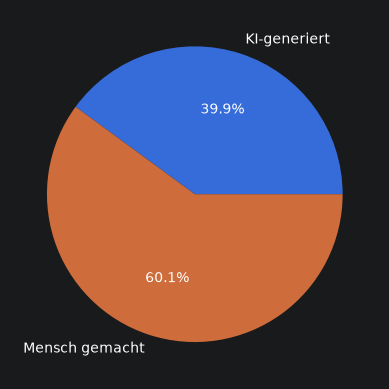

In [131]:
# Beschriftungen der beiden Klassen für das Kreisdiagramm
labels = ["KI-generiert", "Mensch gemacht"]

# Anzahl der Texte pro Klasse ermitteln
# Dabei steht 1 für KI-generierte Texte und 0 für menschlich verfasste Texte
sizes = [df["generated"].value_counts()[1], df["generated"].value_counts()[0]]

# Neue Abbildung und Achse für das Diagramm erstellen
fig, ax = plt.subplots()

# Kreisdiagramm zeichnen
# labels: Beschriftungen der Segmente
# autopct: Prozentanteil jedes Segments mit einer Nachkommastelle anzeigen
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

### 3 Data Understanding - Visualisierungen

**Vorgehensweise:** Wir visualisieren die Klassenverteilung sowie Text- und Wortlängen
getrennt nach Klasse. So lassen sich erste Unterschiede zwischen menschlichen und
KI-generierten Texten erkennen, die später als Features nützlich sein können.

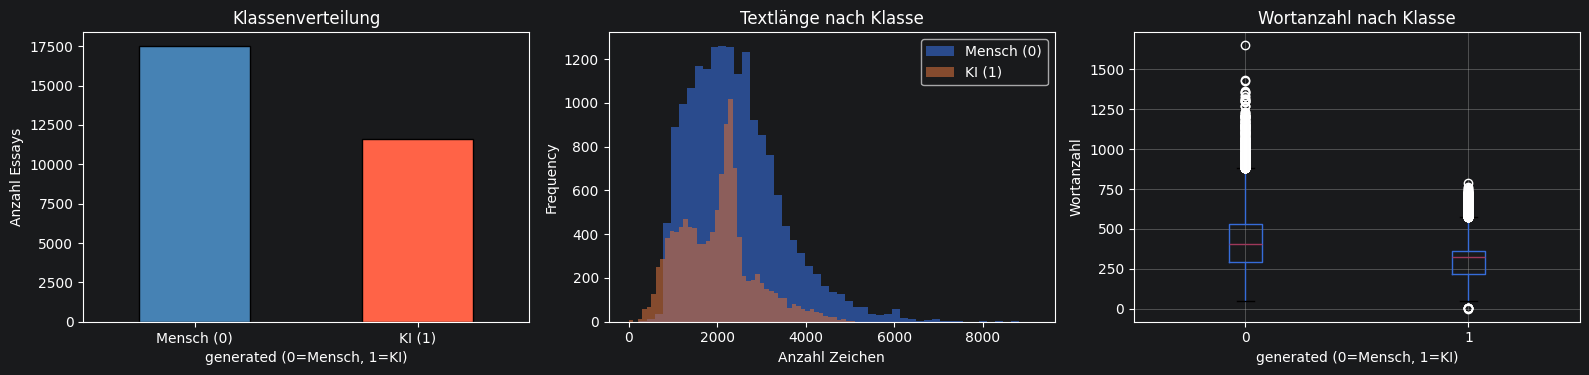

In [5]:
# Drei nebeneinanderliegende Diagramme anlegen
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Klassenverteilung
# Häufigkeit der Klassen als Balkendiagramm
df["generated"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
# Titel des ersten Diagramms
axes[0].set_title("Klassenverteilung")
# x-Achsen-Beschriftung
axes[0].set_xlabel("generated (0=Mensch, 1=KI)")
# y-Achsen-Beschriftung
axes[0].set_ylabel("Anzahl Essays")
# Tick-Beschriftungen lesbar setzen
axes[0].set_xticklabels(["Mensch (0)", "KI (1)"], rotation=0)

# (b) Textlänge (Zeichen)
# Neue Spalte mit Zeichenanzahl je Text
df["text_length"] = df["text"].str.len()
# Histogramm der Textlänge je Klasse
df.groupby("generated")["text_length"].plot(kind="hist", bins=50, alpha=0.6, ax=axes[1], legend=True)
# Titel
axes[1].set_title("Textlänge nach Klasse")
# x-Achse
axes[1].set_xlabel("Anzahl Zeichen")
# Legende setzen
axes[1].legend(["Mensch (0)", "KI (1)"])

# (c) Wortanzahl
# Neue Spalte mit Wortanzahl je Text
df["word_count"] = df["text"].str.split().str.len()
# Boxplot der Wortanzahl je Klasse
df.boxplot(column="word_count", by="generated", ax=axes[2])
# Titel
axes[2].set_title("Wortanzahl nach Klasse")
# x-Achse
axes[2].set_xlabel("generated (0=Mensch, 1=KI)")
# y-Achse
axes[2].set_ylabel("Wortanzahl")
# Automatischen Übertitel von boxplot entfernen
plt.suptitle("")

# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Erkenntnisse aus den Visualisierungen:**
- Aufgrund der geringen Merkmalsanzahl ist die Menge der möglichen Auswertungen recht gering. Das Verhältnis der vorhandenen Datenmengen für generierte und geschriebene Texte ist für das Trainieren einer ML jedoch sehr relevant. Da dieser Faktor bereits bei der Datensatzwahl berücksichtigt wurde, ist das Ergebnis hier nichtmehr überraschend.
- Menschliche Texte sind in der Regel deutlich länger, als KI-generierte Texte. Das geht sowohl aus der Zeichenanzahl als auch aus der Wortanzahl hervor.

### 4 Data Preperation - Regex

#### Theoretischer Hintergrund
**Reguläre Ausdrücke (Regex)** sind eine formale Sprache, um Muster in Zeichenketten zu
beschreiben. Sie sind ein zentrales Werkzeug der **Data Preparation** im NLP, um Texte zu
normalisieren und zu bereinigen. Typische Operationen:
- Suchen von Mustern (`re.findall`, `str.contains`)
- Ersetzen von Mustern (`re.sub`)
- Zeichenklassen wie `\w` (Wortzeichen), `\s` (Whitespace), `[^...]` (Negation).

Ziel der Vorverarbeitung ist eine **konsistente Repräsentation** des Textes, damit
nachgelagerte Tokenisierung und Vektorisierung saubere, vergleichbare Einheiten erhalten.

**Vorgehensweise:** Wir definieren eine Funktion `preprocess_text`, die den Text in
Kleinschreibung überführt, Zeilenumbrüche entfernt, Sonderzeichen und Satzzeichen
herausfiltert und mehrfache Leerzeichen reduziert. Den Effekt prüfen wir an einem
Beispieltext und vergleichen die durchschnittliche Textlänge vor und nach der Bereinigung.

#### Überblick: Welche Vorverarbeitungsschritte sind sinnvoll?

Für NLP-Klassifikation typischerweise:
1. Kleinschreibung
2. Satzzeichen entfernen
3. Mehrfache Leerzeichen bereinigen
4. Zeilenumbrüche entfernen

In [6]:
# Ersten Text aus dem Datensatz als Beispiel wählen
sample = df["text"].iloc[0]
# Hinweis ausgeben
print("Original (erste 200 Zeichen):")
# Die ersten 200 Zeichen des Beispieltexts anzeigen
print(sample[:200])

Original (erste 200 Zeichen):
Car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world grapple with the challenges of congestion, pollution, and limited resources. Th


In [23]:
# Funktion zur Textvorverarbeitung definieren
def preprocess_text(text):
    """Textvorverarbeitung mit Regular Expressions."""
    # 1. Kleinschreibung
    text = text.lower()
    # 2. Zeilenumbrüche und Tabs durch Leerzeichen ersetzen
    text = re.sub(r'[\n\t\r]+', ' ', text)
    # 3. Sonderzeichen und Satzzeichen entfernen (nur Buchstaben/Zahlen/Leerzeichen behalten)
    text = re.sub(r'[^a-zA-ZäöüÄÖÜß0-9\s]', '', text)
    # 4. Mehrfache Leerzeichen auf eines reduzieren
    text = re.sub(r'\s+', ' ', text).strip()
    # Bereinigten Text zurückgeben
    return text

# Anwenden
# Vorverarbeitung auf alle Texte anwenden und in neuer Spalte speichern
df["text_clean"] = df["text"].apply(preprocess_text)

# Originaltext (Ausschnitt) ausgeben
print("Vorher:", df["text"].iloc[0][:150])
# Bereinigten Text (Ausschnitt) ausgeben
print("\nNachher:", df["text_clean"].iloc[0][:150])

Vorher: Car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world grapple with the challenges o

Nachher: carfree cities have become a subject of increasing interest and debate in recent years as urban areas around the world grapple with the challenges of 


In [8]:
# Vergleich: Textlänge vorher/nachher
# Länge des bereinigten Textes als neue Spalte berechnen
df["text_clean_length"] = df["text_clean"].str.len()
# Durchschnittliche Länge VOR der Bereinigung ausgeben
print(f"Ø Länge vorher: {df['text_length'].mean():.0f} Zeichen") # benötigt Codeblock bei Visualisierung
# Durchschnittliche Länge NACH der Bereinigung ausgeben
print(f"Ø Länge nachher: {df['text_clean_length'].mean():.0f} Zeichen") # benötigt Codeblock bei Visualisierung

Ø Länge vorher: 2244 Zeichen
Ø Länge nachher: 2183 Zeichen


**Begründung der Vorverarbeitungsschritte:**
- Kleinschreibung: Reduktion der Wortvielfalt (z.B. "The" = "the")
- Satzzeichen entfernen: KI-Texte könnten charakteristische Interpunktionsmuster haben – für TF-IDF-basierte Modelle nicht relevant
- Leerzeichen bereinigen: Normalisierung für konsistente Tokenisierung

#### Aktuelle Übersicht über den Datensatz nach der Verarbeitung

In [9]:
df.head()

,text,generated,text_length,word_count,text_clean,text_clean_length
0,Car-free cities have become a subject of incre...,1,4091,575,carfree cities have become a subject of increa...,3982
1,"Car Free Cities Car-free cities, a concept ga...",1,3757,513,car free cities carfree cities a concept gaini...,3647
2,A Sustainable Urban Future Car-free cities ...,1,3828,512,a sustainable urban future carfree cities are ...,3719
3,Pioneering Sustainable Urban Living In an e...,1,3739,519,pioneering sustainable urban living in an era ...,3640
4,The Path to Sustainable Urban Living In an ...,1,3698,511,the path to sustainable urban living in an age...,3596


#### Erstellung der Visualisierungen nach der Bereinigung

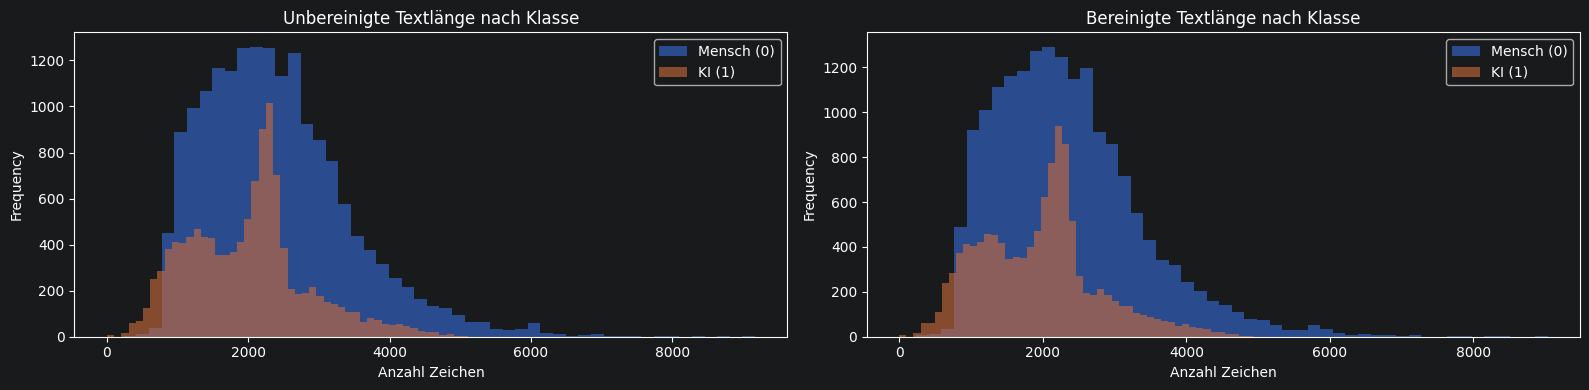

In [10]:
# Drei nebeneinanderliegende Diagramme anlegen
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Unbereinigte Textlänge (Zeichen)
# Histogramm der Textlänge je Klasse
df.groupby("generated")["text_length"].plot(kind="hist", bins=50, alpha=0.6, ax=axes[0], legend=True)
# Titel
axes[0].set_title("Unbereinigte Textlänge nach Klasse")
# x-Achse
axes[0].set_xlabel("Anzahl Zeichen")
# Legende setzen
axes[0].legend(["Mensch (0)", "KI (1)"])

# Bereinigte Textlänge (Zeichen)
# Histogramm der Textlänge je Klasse
df.groupby("generated")["text_clean_length"].plot(kind="hist", bins=50, alpha=0.6, ax=axes[1], legend=True)
# Titel
axes[1].set_title("Bereinigte Textlänge nach Klasse")
# x-Achse
axes[1].set_xlabel("Anzahl Zeichen")
# Legende setzen
axes[1].legend(["Mensch (0)", "KI (1)"])

# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

Im Vergleich zu der Betrachtung vor der Bereinigung des Datensatzes sind keine nennenswerten Unterschiede aufgetreten.

## Übungsblatt 4

### Aufgabenstellung

**1 Datenqualität**

Für den von Ihnen gewählten Datensatz:
- [x] Analysieren Sie ob der Datensatz fehlende Werte enthält. Falls ja, entscheiden Sie wie Sie damit umgehen (löschen oder ersetzen) und Begründen Sie Ihre Entscheidung.
- [x] Analysieren Sie ob der Datensatz Duplikate enthält. Falls ja, wie gehen Sie damit um?
- [X] Analysieren Sie ob der Datensatz andere fehlerhafte Werte enthält (vgl. Vorlesung). Falls ja, finden Sie geeignete Lösungsstrategien und wenden Sie diese falls möglich an.
- [X] Gibt es in Ihrem Datensatz weitere Qualitätsprobleme?

**2 Optional: Matplotlib- Erstellen eines Linienplots**
Erstellen Sie eine Grafik der Durchschnittstemperaturen (in °C) für zwei Städte über ein Jahr mit Hilfe von matplotlib.
- [X] Verwenden Sie die Durchschnittstemperaturen für Karlsruhe und Berlin

```
monate = [’Jan’, ’Feb’, ’Mär’, ’Apr’, ’Mai’, ’Jun’, ’Jul’, ’Aug’, ’Sep’, ’Okt’, ’Nov’, ’Dez’]
T_ka = [0, 1, 5, 9, 14, 18, 20, 19, 14, 9, 4, 1]
T_berlin = [-2, 0, 4, 8, 13, 17, 19, 18, 13, 8, 3, 0]
```

- [X] Linienplot: Erstellen Sie für jede Stadt einen Linienplot, der die monatlichen Durchschnittstemperaturen zeigt. Verwenden Sie unterschiedliche Farben oder Linienstile für jede Stadt. Importieren Sie import matplotlib.pyplot as plt und erstellen Sie den Plot mit ``plt.plot()``.
- [X] Achsenbeschriftungen: Die x-Achse soll die Monate und die y-Achse die Temperatur in °C anzeigen. Verwenden Sie ``plt.xlabel()`` und ``plt.ylabel()``.
- [X] Legende: Fügen Sie eine Legende hinzu, um zu kennzeichnen, welche Linie zu welcher Stadt gehört mit ``plt.legend()``.
- [X] Titel: Geben Sie Ihrem Plot einen Titel mit ``plt.title()``.
- [X] Aktivieren Sie das Gitter mit ``plt.grid(True)``

### 1 Datenqualität

#### Theoretischer Hintergrund
**Datenqualität** beschreibt, wie gut Daten für ihren Verwendungszweck geeignet sind.
Wichtige Qualitätsdimensionen sind **Vollständigkeit** (fehlende Werte), **Eindeutigkeit**
(Duplikate), **Korrektheit** (fehlerhafte/unplausible Werte) und **Konsistenz**.
Gängige Strategien im Umgang mit Qualitätsproblemen:
- **Löschen** von Zeilen/Spalten (wenn der Informationsverlust vertretbar ist),
- **Ersetzen/Imputieren** fehlender Werte (z. B. durch Mittelwert/Median),
- **Korrigieren** fehlerhafter Werte (z. B. Encoding-Artefakte bereinigen).

Schlechte Datenqualität wirkt sich direkt auf die Modellgüte aus, daher ist dieser Schritt
vor der Modellierung essenziell.

**Vorgehensweise:** Wir prüfen den Datensatz systematisch auf fehlende Werte, Duplikate und
fehlerhafte Werte (unbekannte Sonderzeichen, ungültige Labels, leere Strings). Für jede
gefundene Auffälligkeit dokumentieren wir Ursache und gewählte Lösungsstrategie.

#### Fehlende Werte

Da Zeilen, bei welchen der Text oder die Zuordnung fehlen, keinen Nutzen haben, dürfen sie so nicht im Datensatz bleiben. Einen eigenen Text hinzufügen ist ausgeschlossen und mögliche Fehleinschätzungen machen das Bewerten eines vorhandenen Textes ohne Zuordnung riskant. Deshalb werden alle Zeilen mit fehlenden Werten gelöscht. Vor der Veränderung hat der Datensatz 27340 Zeilen. Nach dem Vorgang hat sich daran nichts verändert.

In [19]:
# Zeilen mit fehlenden Werten (probeweise) entfernen
df.dropna()
# Anzahl der Einträge je Spalte prüfen (zeigt: keine Änderung -> keine fehlenden Werte)
df.count()

text                 27340
generated            27340
text_length          27340
word_count           27340
text_clean           27340
text_clean_length    27340
dtype: int64

#### Duplikate

Duplikate wurden bereits in einem früheren Schritt entdeckt und eigenständig entfernt. Ihr Erhalt hat für diesen Datensatz keinen Mehrwert.


#### Fehlerhafte Werte

Der Datensatz wird auf fehlerhafte Werte mithilfe der folgenden Suchkriterien untersucht.
- Texte mit unbekannten Symbolen (Nicht Alpha-Numerisch oder Satzzeichen).
- Generated-Zahl, die weder 1 noch 0 ist.
- Texte mit doppelten Leerzeichen.
- Texte die leere Strings sind.

In [17]:
#Texte mit unbekannten Symbolen (Nicht Alpha-Numerisch oder Satzzeichen).
# Regex-Zeichenklasse aller ERLAUBTEN Zeichen (alles andere gilt als unbekanntes Sonderzeichen)
erwartete_zeichen = r'[^\w\s\.\,\-\'\:\(\)\[\]\{\}\!\?\&\=\#\|\/\$\£\"\%\;\+\*\@\<\>\\\°\~\®\™\¬\©\♡\☺\😜\😊\😁\😊\•\¡\…\´\`\’\‘\“\”\¸\—\–\─\―\‒\¸\¨\·\^\x9b\xad\x92\x97\x83\x91\x93\x94\x82\x80\x99\xb6\u200b\ufe0f\u0301]'

# Alle Zeilen filtern, deren Text mindestens ein nicht-erlaubtes Sonderzeichen enthält
sonderzeichen_df = df[df['text'].str.contains(erwartete_zeichen, regex=True)]
# Die konkreten Sonderzeichen je Treffer-Zeile auflisten
sonderzeichen_df['sonderzeichen'] = sonderzeichen_df['text'].str.findall(erwartete_zeichen)

# Die gefundenen Sonderzeichen zusätzlich als Unicode-Escape-Codes darstellen
sonderzeichen_df['unicode_codes'] = sonderzeichen_df['sonderzeichen'].apply(
    lambda zeichen_liste: [c.encode('unicode-escape').decode('utf-8') for c in zeichen_liste]
)

# Spaltenbreite der Anzeige aufheben, damit ganze Texte sichtbar sind
with pd.option_context('display.max_colwidth', None):
    # Gefilterten DataFrame mit Sonderzeichen ausgeben
    print(sonderzeichen_df)

ArrowInvalid: Invalid regular expression: invalid escape sequence: \£

- ``¸`` wird in Datensatz 3378 statt einem Komma verwendet.
- ``¨`` ist in mehreren Datensätzen zu finden und erfüllt dort keine Rolle. Es scheint sich um eine Art Artefakt zu handeln.
- ``·`` wird als Teil einer Quellenangabe verwendet.
- ``¢`` taucht an einigen Stellen in korrupierten Textabschnitten auf.

Einige andere Zeichen werden in der Ausgabe nicht angezeigt, weshalb zusätzlich die Unicode Kürzel betrachtet werden.
- ``\x9b``, ``\x80``, ``\x82``, ``\x99``, ``\x91``, ``\x83`` sind Steuerzeichen für die Formatierung von Dokumenten.
- ``\xad`` zeigt in langen Worten an, wo es von einem Textprogramm getrennt werden darf. Es wird selbst nicht angezeigt.
- ``\x92`` ist ein Codierungsartefakt der Textumwandlung aus der Windows-Codierung hin zu UTF-8.
- ``\x97`` Steht in alten Windows-Systemen für Em-Dashes, ist in neueren Systemen jedoch lediglich ein Formatierungszeichen.
- ``\xb6`` Signalisiert das Ende einer Zeile in Schreibsoftware wie Word.
- ``\u200b`` idt ein Leerzeichen ohne breite, welches für Wortumbrüche verwendet werden kann.
- ``\ufe0f`` und ``\u0301`` sind Kreise mit gepunkteten Linien (und im zweiten mit einem Aktzent).
- ``\x93`` und ``\x94`` markieren in Systemen wie Word das " als öffnend und schließend.

In [18]:
#Generated-Zahl, die weder 1 noch 0 ist.
# Zeilen filtern, deren Label NICHT in {0, 1} liegt
fehlbewertet_df = df[~df['generated'].isin([0, 1])]
# Ergebnis ausgeben (leer = keine ungültigen Labels)
print(fehlbewertet_df)

Empty DataFrame
Columns: [text, generated]
Index: []


Nun werden die ungewollten oder außergewöhnlichen Sonderzeichen gesucht und die Umgebung auf Fehler oder kaputte Daten untersucht.

In [24]:
# Gesuchtes (verdächtiges) Sonderzeichen festlegen
zeichen = '¨' # gesuchtes Zeichen
# Anzahl der Kontextzeichen links und rechts des Treffers
anzahl = 50 # Wieviele Symbole nach rechts/links

# Zeichen für die Verwendung in einem Regex maskieren
escaped_zeichen = re.escape(zeichen) # Zeichen für Regex umformatieren

# Regex-Muster: Kontext vor + Zeichen + Kontext nach dem Treffer
regex_muster = f"(.{{0,{anzahl}}})({escaped_zeichen})(.{{0,{anzahl}}})"

# Alle Treffer samt Kontext aus allen Texten extrahieren
ergebnisse = df['text'].str.extractall(regex_muster)

# Ergebnis-Spalten benennen
ergebnisse.columns = ['vorher', 'zeichen', 'nachher']
# Treffer mit Kontext zu einem zusammenhängenden Textabschnitt verbinden
ergebnisse['textabschnitt'] = ergebnisse['vorher'] + ergebnisse['zeichen'] + ergebnisse['nachher']

# Spaltenbreite der Anzeige aufheben (ganze Textabschnitte zeigen)
with pd.option_context('display.max_colwidth', None): # Zeige ganzen Text an
    # Die gefundenen Textabschnitte ausgeben
    print(ergebnisse[['textabschnitt']])

                                                                                                     textabschnitt
      match                                                                                                       
2833  0      oundings. In fact, according to driving test.org, ¨ texting and driving is more debilitating to your 
      1      n time than driving under the influence of alcohol¨ . Since the light refracted off the phone is what
      2       you 23% more likely to be involved in an accident¨ . It then goes on to say that in 2011, 1.3 millio
      3           ¨3,477 people were killed and 391,000 injured¨ in crashes relating to texting while driving. Thi
      4      tate of residence of Georgia. It is illegal under ¨the part of a sweeping hands-free law¨ according t
...                                                                                                            ...
14055 3                            ces have strong outcomes,ÃÂ¨ says the Generi

Das Symbol ¢ kam viermal im Text vor.
~~~
...know what to do, so if you had a problem like "3Ã¢â¬Â¢5+2" you know what to do, you multiply 3 and...
...how to do it, if you know how to do it you know 3Ã¢â¬Â¢5 is 15 and 15+2 is 17. Having a better under...
...ns can help someone make a better choice. theyÃâ¢e good choices a person could give you a good choi...
...TheyÃâ¢e also bad choices in some opinions. A person can...
~~~
Die ersten zwei Fälle sind Gleichungen, bei welchen das Multiplikationssymbol durch ```Ã¢â¬Â¢``` ersetzt wurde. Es wird durch das Symbol · ersetzt.

``TheyÃâ¢e`` scheint ein Fehler bei der Textkonvertierung zu sein, wobei das Original They're war. Dies wird entsprechend angepasst.

### 2 Optional: Matplotlib - Erstellen eines Linienplots

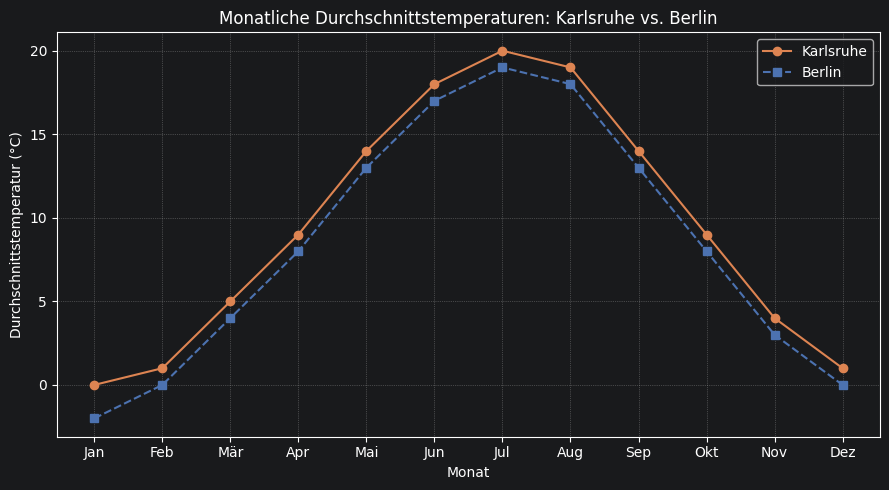

In [20]:
# Monatsnamen als x-Achsen-Beschriftung
monate = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
# Durchschnittstemperaturen Karlsruhe
T_ka     = [0, 1, 5, 9, 14, 18, 20, 19, 14, 9, 4, 1]
# Durchschnittstemperaturen Berlin
T_berlin = [-2, 0, 4, 8, 13, 17, 19, 18, 13, 8, 3, 0]

# (b) Linienplot für beide Städte mit unterschiedlichen Farben und Linienstilen
# Neue Abbildung mit fester Größe anlegen
plt.figure(figsize=(9, 5))
# Linie für Karlsruhe (durchgezogen, Kreis-Marker)
plt.plot(monate, T_ka,     color="#DD8452", linestyle="-",  marker="o", label="Karlsruhe")
# Linie für Berlin (gestrichelt, Quadrat-Marker)
plt.plot(monate, T_berlin, color="#4C72B0", linestyle="--", marker="s", label="Berlin")

# (c) Achsenbeschriftungen
# x-Achse beschriften
plt.xlabel("Monat")
# y-Achse beschriften
plt.ylabel("Durchschnittstemperatur (°C)")
# Titel setzen
plt.title("Monatliche Durchschnittstemperaturen: Karlsruhe vs. Berlin")

# (d) Legende
# Legende anzeigen
plt.legend()

# Gitter zur besseren Lesbarkeit aktivieren
plt.grid(True, linestyle=":", alpha=0.6)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

## Übungsblatt 5

### Aufgabenstellung

**1 Beschreibung des Korpus**
- [X] Beschreiben Sie Ihren Korpus in Ihrer Ausarbeitung.
- [X] Aus wie vielen Word Types besteht Ihr Korpus?
- [X] Wie vielen Word Instances enthält Ihr Korpus?

**2 Wortfrequenzanalyse**
- [X] Wenden Sie die Tokenisierungsmethoden auf Ihren Datensatz an (Whitespace
und BPE).
- [X] Berechnen Sie die Häufigkeit der Word Types.
- [X] Visualisieren Sie die Wortfrequenzen in einem Barchart.
- [X] Ist das hilfreich zur Lösung Ihres Klassifikationsproblems?
- [X] Entfernen Sie Stop Words und führen Sie die Schritte oben erneut durch.
- [X] Welchen Einfluss hat die Vocabulary Size auf die häufigsten Token bei BPE..

**3 Vektorisierung**
Vektorisieren Sie Ihren Datensatz mit dem
- [X] Bag-of-Words Ansatz.
- [X] TF-IDF Ansatz.
- [X] N-gram Ansatz. Testen Sie verschiedene Werte für N.

Was fällt Ihnen auf?

### 1. Beschreibung des Korpus

#### Theoretischer Hintergrund
Ein **Korpus** ist eine strukturierte Sammlung von Texten, die als Grundlage für die
Analyse dient. Zentrale Begriffe der Korpuslinguistik:
- **Word Instance (Token):** jedes einzelne Vorkommen eines Wortes im Text.
- **Word Type:** jedes *eindeutige* Wort (das Vokabular).
- **Type-Token-Ratio (TTR):** Verhältnis von Types zu Tokens als Maß für die lexikalische
  Vielfalt. Eine niedrige TTR bedeutet, dass wenige Wörter sehr häufig wiederholt werden
  (typisch für natürliche Sprache aufgrund häufiger Funktionswörter).

Die Korpusbeschreibung liefert die Kennzahlen, auf denen Tokenisierung und Vektorisierung
aufbauen.

**Vorgehensweise:** Wir fassen alle Texte zu einem Korpus zusammen, tokenisieren ihn per
Whitespace und bestimmen die Anzahl der Word Instances und Word Types sowie die
Type-Token-Ratio als Maß der lexikalischen Vielfalt.

Unser Korpus besteht aus Essay-Texten, die entweder von Menschen verfasst (`generated=0`) oder von einer KI generiert wurden (`generated=1`). Jeder Essay ist einem Schreibprompt (`prompt_id`) zugeordnet.

**Wichtige Begriffe:**
- **Word Type:** Ein eindeutiges Wort im Vokabular (z. B. "the" zählt nur einmal, egal wie oft es vorkommt)
- **Word Instance (Token):** Jedes Vorkommen eines Wortes im Text (z. B. "the" zählt jedes Mal)

In [21]:
# Anzahl Zeilen und Spalten des Datensatzes ausgeben
print(f"Datensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
# Häufigkeit der beiden Klassen ausgeben
print(f"Klassenverteilung:\n{df['generated'].value_counts()}")

Datensatz: 29145 Zeilen, 2 Spalten
Klassenverteilung:
generated
0    17508
1    11637
Name: count, dtype: int64


In [25]:
# Gesamten Korpus als einen langen String zusammenführen
corpus_text = " ".join(df["text_clean"].tolist())
# Gesamtlänge des Korpus in Zeichen ausgeben
print(f"Gesamtlänge des Korpus: {len(corpus_text):,} Zeichen")
# Anzahl der Essays (Dokumente) ausgeben
print(f"Anzahl Essays im Korpus: {len(df):,}")

Gesamtlänge des Korpus: 63,641,453 Zeichen
Anzahl Essays im Korpus: 29,145


In [26]:
# Einfache Whitespace-Tokenisierung für die Korpusbeschreibung
def whitespace_tokenize(text):
    # Text kleinschreiben und an Leerzeichen aufteilen
    return text.lower().split()

# Korpus in Tokens (Word Instances) zerlegen
all_tokens = whitespace_tokenize(corpus_text)
# Eindeutige Tokens (Word Types) als Menge bestimmen
word_types = set(all_tokens)

# Anzahl aller Tokens (Word Instances) ausgeben
print(f"Word Instances (Tokens gesamt): {len(all_tokens):,}")
# Anzahl eindeutiger Wörter (Word Types) ausgeben
print(f"Word Types (eindeutige Wörter): {len(word_types):,}")
# Type-Token-Ratio (Maß für lexikalische Vielfalt) berechnen und ausgeben
print(f"Type-Token-Ratio:               {len(word_types)/len(all_tokens):.4f}")

Word Instances (Tokens gesamt): 11,140,109
Word Types (eindeutige Wörter): 85,923
Type-Token-Ratio:               0.0077


**Interpretation der Type-Token-Ratio (TTR):**
Eine niedrige TTR bedeutet, dass im Korpus relativ wenige unterschiedliche Wörter sehr häufig wiederverwendet werden (typisch für natürliche Sprache, da Funktionswörter wie "the", "is" sehr häufig sind). Mit einer **TTR von ca. 0,0143** (145.746 Word Types auf 10.205.283 Word Instances) ist unser Korpus erwartungsgemäß stark von Wiederholungen geprägt – ein einzelnes Type kommt im Schnitt rund 70-mal vor.

### 2. Wortfrequenzanalyse

#### Theoretischer Hintergrund
**Tokenisierung** zerlegt einen Text in kleinere Einheiten (Tokens). Zwei verbreitete
Verfahren:
- **Whitespace-Tokenisierung:** trennt nur an Leerzeichen → ganze Wörter als Tokens.
  Einfach, aber unflexibel bei unbekannten Wörtern, Tippfehlern und Wortvarianten.
- **Byte Pair Encoding (BPE):** ein subword-basiertes Verfahren, das häufige Zeichenfolgen
  iterativ zu größeren Einheiten zusammenfügt. Unbekannte Wörter werden in bekannte
  Subwort-Bausteine zerlegt (z. B. "tokenization" → "token" + "ization").

**Stop Words** sind sehr häufige Funktionswörter (z. B. "the", "and"), die wenig
inhaltliche Unterscheidungskraft besitzen und für die Klassifikation oft entfernt werden.
Die **Vocabulary Size** bei BPE steuert, wie grob oder fein Wörter zerlegt werden.

**Vorgehensweise:** Wir wenden Whitespace- und BPE-Tokenisierung auf einen Beispieltext an,
berechnen die Wortfrequenzen über den Korpus und visualisieren die häufigsten Tokens.
Anschließend entfernen wir Stop Words und wiederholen die Analyse, um den Effekt auf die
inhaltliche Aussagekraft zu zeigen. Zuletzt untersuchen wir den Einfluss der BPE-Vocabulary-
Size auf die Tokenanzahl.

#### 2a. Tokenisierungsmethoden anwenden

##### Methode 1: Whitespace-Tokenisierung

In [186]:
#### Methode 1: Whitespace-Tokenisierung
# Bereits oben angewendet – Wiederholung
# Text per Whitespace tokenisieren
ws_tokens = whitespace_tokenize(corpus_text)

# Erste 20 Tokens anzeigen
print(f"\nWhitespace-Tokens (erste 20): {ws_tokens[:20]}")
# Gesamtzahl der Tokens anzeigen
print(f"Anzahl Tokens: {len(ws_tokens)}")


Whitespace-Tokens (erste 20): ['carfree', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and', 'debate', 'in', 'recent', 'years', 'as', 'urban', 'areas', 'around', 'the', 'world']
Anzahl Tokens: 11140109


##### Methode 2: BPE (Byte Pair Encoding)

BPE ist ein subword-basiertes Tokenisierungsverfahren: Häufige Zeichenfolgen werden iterativ zu größeren Einheiten zusammengeführt. Das ermöglicht die Zerlegung auch unbekannter Wörter in bekannte Subwort-Bausteine.

In [187]:
# BPE-Tokenizer trainieren (mit der tokenizers-Bibliothek von HuggingFace)
def train_bpe_tokenizer(texts, vocab_size=5000):
    # Leeren BPE-Tokenizer mit Unknown-Token anlegen
    tokenizer = Tokenizer(BPE())
    # Vor-Tokenisierung an Leerzeichen
    tokenizer.pre_tokenizer = Whitespace()
    # Trainer mit gewünschter Vokabulargröße konfigurieren
    trainer = BpeTrainer(vocab_size=vocab_size)
    # Tokenizer auf den übergebenen Texten trainieren
    tokenizer.train_from_iterator(texts, trainer=trainer)
    # Trainierten Tokenizer zurückgeben
    return tokenizer

# Trainieren auf einer Stichprobe des Korpus (Performance)
# Zufällige Stichprobe von 2000 Texten ziehen
sample_corpus = df["text_clean"].sample(2000, random_state=42).tolist()
# BPE-Tokenizer auf der Stichprobe trainieren
bpe_tokenizer = train_bpe_tokenizer(sample_corpus, vocab_size=5000)

# Größe des gelernten Vokabulars ausgeben
print(f"BPE-Vokabular trainiert mit {bpe_tokenizer.get_vocab_size()} Subwort-Einheiten")

BPE-Vokabular trainiert mit 5000 Subwort-Einheiten


In [188]:
# BPE auf den gesamten Korpus anwenden
bpe_output = bpe_tokenizer.encode(corpus_text)

# Erste 20 BPE-Tokens ausgeben
print("BPE-Tokens (erste 20):", bpe_output.tokens[:20])
# Gesamtzahl der BPE-Tokens ausgeben
print(f"Anzahl BPE-Tokens: {len(bpe_output.tokens)}")

BPE-Tokens (erste 20): ['carfree', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and', 'debate', 'in', 'recent', 'years', 'as', 'urban', 'areas', 'around', 'the', 'world']
Anzahl BPE-Tokens: 12239972


**Vergleich Whitespace vs. BPE:**
- Whitespace zerlegt nur an Leerzeichen → ganze Wörter als Tokens.
- BPE kann Wörter in Subwort-Einheiten zerlegen (z. B. "tokenization" → "token" + "ization") → besser geeignet für unbekannte Wörter, Tippfehler oder seltene Begriffe.

Am Beispieltext zeigt sich dies deutlich: Während die Whitespace-Tokenisierung jedes Wort als ein Token behandelt, zerlegt BPE selteneres/zusammengesetztes Vokabular (z. B. "Car-free" → "Car", "-", "free") in mehrere Subwort-Bausteine. BPE erzeugt dadurch tendenziell mehr Tokens pro Text, kann aber jedes Wort darstellen, ohne ein `<UNK>`-Token zu benötigen.

#### 2b. Häufigkeit der Word Types berechnen

In [189]:
# Wortfrequenzen über den gesamten Korpus (Whitespace-Tokenisierung)
word_freq = Counter(all_tokens)
# Die 20 häufigsten Wörter bestimmen
most_common_20 = word_freq.most_common(20)

# Ergebnis als DataFrame aufbereiten
freq_df = pd.DataFrame(most_common_20, columns=["Wort", "Häufigkeit"])
# Tabelle ausgeben
freq_df

,Wort,Häufigkeit
0,the,536151
1,to,370368
2,and,286349
3,a,261677
4,of,258200
5,in,204042
6,is,176929
7,that,172559
8,it,133115
9,for,126790


#### 2c. Visualisierung: Wortfrequenzen (Barchart)

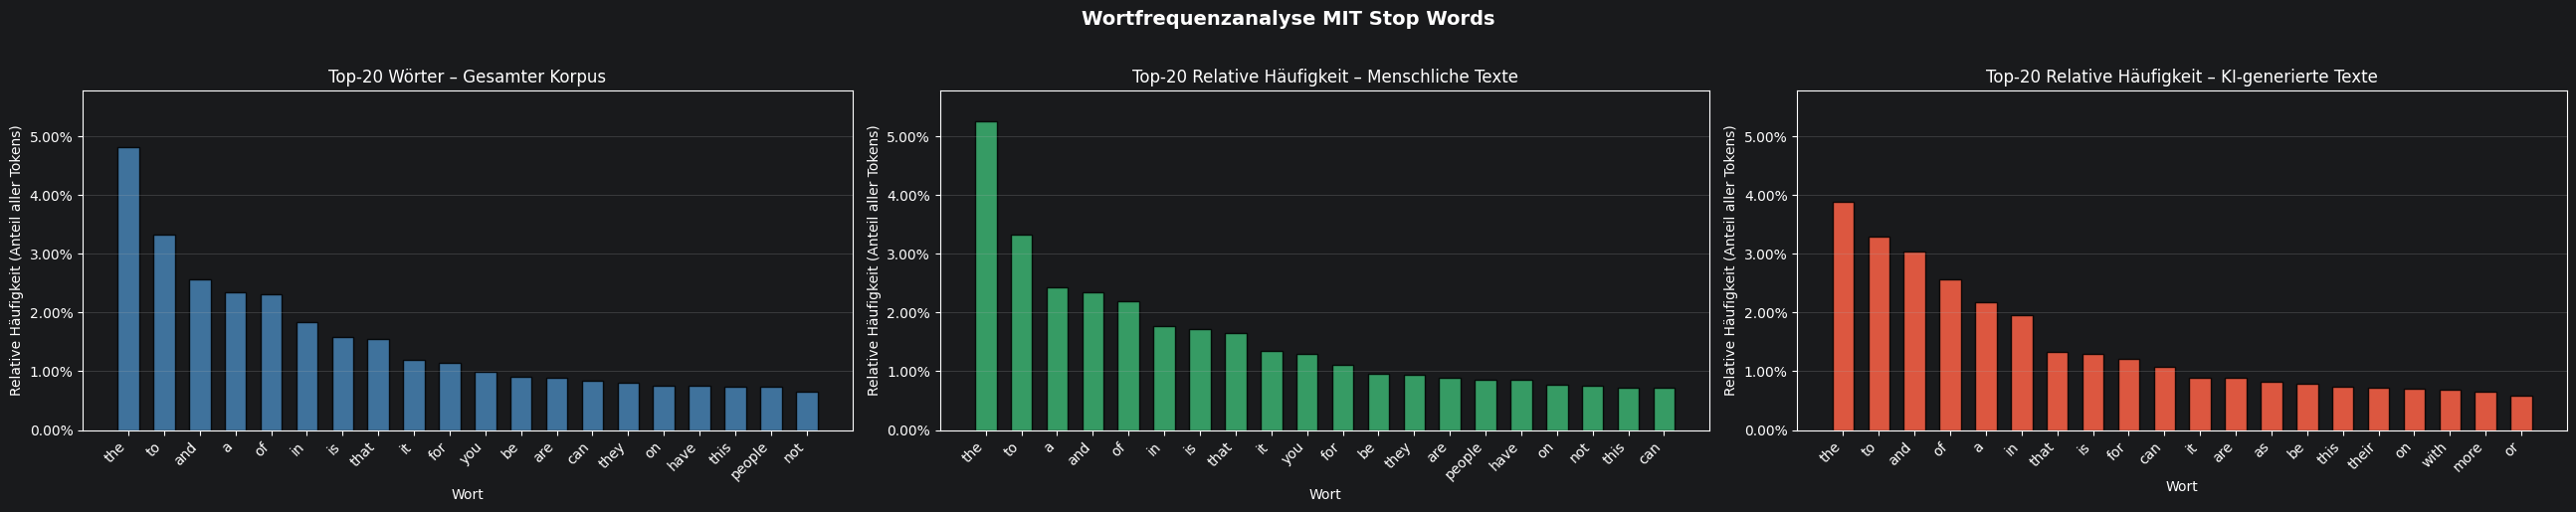

In [27]:
# Tokens für menschliche Texte aus dem Korpus extrahieren
human_tokens_sw = whitespace_tokenize(" ".join(df[df["generated"] == 0]["text_clean"].tolist()))
# Tokens für KI-generierte Texte aus dem Korpus extrahieren
ai_tokens_sw    = whitespace_tokenize(" ".join(df[df["generated"] == 1]["text_clean"].tolist()))

# Absolute Wortfrequenzen für den Gesamtkorpus berechnen
word_freq = Counter(all_tokens)
# Absolute Wortfrequenzen für menschliche Texte berechnen
human_freq_sw = Counter(human_tokens_sw)
# Absolute Wortfrequenzen für KI-Texte berechnen
ai_freq_sw    = Counter(ai_tokens_sw)

# Gesamtanzahl aller Tokens im Korpus für relative Häufigkeit des Gesamtkorpus
total_sw       = sum(word_freq.values())
# Gesamtanzahl aller Tokens in menschlichen Texten für relative Häufigkeit
human_total_sw = sum(human_freq_sw.values())
# Gesamtanzahl aller Tokens in KI-Texten für relative Häufigkeit
ai_total_sw    = sum(ai_freq_sw.values())

# Top-20 Wörter des Gesamtkorpus bestimmen
corpus_top20_sw = [w for w, _ in word_freq.most_common(20)]
# Relative Häufigkeiten der Top-20 Wörter im Gesamtkorpus berechnen
corpus_rel_sw   = [word_freq.get(w, 0) / total_sw for w in corpus_top20_sw]

# Top-20 Wörter der menschlichen Texte bestimmen (nach Häufigkeit absteigend sortiert)
human_top20_sw = [w for w, _ in human_freq_sw.most_common(20)]
# Relative Häufigkeiten der menschlichen Top-20 berechnen
human_rel_sw   = [human_freq_sw.get(w, 0) / human_total_sw for w in human_top20_sw]

# Top-20 Wörter der KI-Texte bestimmen (unabhängig von der Mensch-Liste, absteigend sortiert)
ai_top20_sw = [w for w, _ in ai_freq_sw.most_common(20)]
# Relative Häufigkeiten der KI Top-20 berechnen
ai_rel_sw   = [ai_freq_sw.get(w, 0) / ai_total_sw for w in ai_top20_sw]

# Einheitliches y-Achsen-Maximum über alle drei Diagramme berechnen
# (Maximum aller relativen Häufigkeiten + 10% Puffer für Lesbarkeit)
y_max_sw = max(max(corpus_rel_sw), max(human_rel_sw), max(ai_rel_sw)) * 1.1

# x-Positionen für die Gesamtkorpus-Balken berechnen
x_corpus_sw = np.arange(len(corpus_top20_sw))
# x-Positionen für die Balken der menschlichen Texte berechnen
x_human_sw  = np.arange(len(human_top20_sw))
# x-Positionen für die Balken der KI-Texte berechnen
x_ai_sw     = np.arange(len(ai_top20_sw))
# Breite eines einzelnen Balkens festlegen
width = 0.6

# 1x3 Layout anlegen: Gesamt-Korpus | Mensch | KI
fig, axes = plt.subplots(1, 3, figsize=(26, 5))
# Gemeinsamen Titel für alle drei Diagramme setzen
fig.suptitle("Wortfrequenzanalyse MIT Stop Words", fontsize=14, fontweight="bold", y=1.02)

# ── Linkes Diagramm: Top-20 gesamt (relativ, steelblue) ────────────────────

# Balkendiagramm der relativen Häufigkeiten der Top-20 Wörter im Gesamtkorpus zeichnen
axes[0].bar(x_corpus_sw, corpus_rel_sw, width,
            color="steelblue", edgecolor="black", alpha=0.85)
# x-Tick-Positionen auf die Wortpositionen setzen
axes[0].set_xticks(x_corpus_sw)
# Wörter als Tick-Beschriftungen schräg stellen
axes[0].set_xticklabels(corpus_top20_sw, rotation=45, ha="right")
# x-Achse beschriften
axes[0].set_xlabel("Wort")
# y-Achse beschriften
axes[0].set_ylabel("Relative Häufigkeit (Anteil aller Tokens)")
# y-Achse als Prozentwert formatieren
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.2f}%"))
# Einheitliches y-Achsen-Maximum setzen
axes[0].set_ylim(0, y_max_sw)
# Titel des Diagramms setzen
axes[0].set_title("Top-20 Wörter – Gesamter Korpus")
# Horizontales Gitter für einfachere Ablesung der Werte einblenden
axes[0].grid(axis="y", alpha=0.3)

# ── Mittleres Diagramm: Top-20 Menschliche Texte (relativ, grün, sortiert) ─

# Balken für die menschlichen Top-20 Wörter zeichnen
axes[1].bar(x_human_sw, human_rel_sw, width,
            color="mediumseagreen", edgecolor="black", alpha=0.85)
# x-Tick-Positionen auf die Wortpositionen setzen
axes[1].set_xticks(x_human_sw)
# Top-20 Wörter der Menschen als Tick-Beschriftungen schräg stellen
axes[1].set_xticklabels(human_top20_sw, rotation=45, ha="right")
# x-Achse beschriften
axes[1].set_xlabel("Wort")
# y-Achse beschriften
axes[1].set_ylabel("Relative Häufigkeit (Anteil aller Tokens)")
# y-Achse als Prozentwert formatieren
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.2f}%"))
# Einheitliches y-Achsen-Maximum setzen
axes[1].set_ylim(0, y_max_sw)
# Titel des Diagramms setzen
axes[1].set_title("Top-20 Relative Häufigkeit – Menschliche Texte")
# Horizontales Gitter für einfachere Ablesung der Werte einblenden
axes[1].grid(axis="y", alpha=0.3)

# ── Rechtes Diagramm: Top-20 KI-Texte (relativ, rot, sortiert) ─────────────

# Balken für die KI Top-20 Wörter zeichnen
axes[2].bar(x_ai_sw, ai_rel_sw, width,
            color="tomato", edgecolor="black", alpha=0.85)
# x-Tick-Positionen auf die Wortpositionen setzen
axes[2].set_xticks(x_ai_sw)
# Top-20 Wörter der KI als Tick-Beschriftungen schräg stellen
axes[2].set_xticklabels(ai_top20_sw, rotation=45, ha="right")
# x-Achse beschriften
axes[2].set_xlabel("Wort")
# y-Achse beschriften
axes[2].set_ylabel("Relative Häufigkeit (Anteil aller Tokens)")
# y-Achse als Prozentwert formatieren
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.2f}%"))
# Einheitliches y-Achsen-Maximum setzen
axes[2].set_ylim(0, y_max_sw)
# Titel des Diagramms setzen
axes[2].set_title("Top-20 Relative Häufigkeit – KI-generierte Texte")
# Horizontales Gitter für einfachere Ablesung der Werte einblenden
axes[2].grid(axis="y", alpha=0.3)

# Layout automatisch optimieren damit nichts abgeschnitten wird
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### 2d. Ist das hilfreich zur Lösung des Klassifikationsproblems?

Nein – die häufigsten Wörter sind fast ausschließlich Stop Words (z. B. "the", "and", "to"). Diese kommen in **beiden Klassen** (Mensch und KI) etwa gleich häufig vor und tragen daher kaum zur Unterscheidung bei. Für die Klassifikation sind seltenere, klassenspezifische Wörter meist aussagekräftiger.

#### 2e. Stop Words entfernen und Schritte wiederholen

In [28]:
# NLTK Stop Words laden
try:
    # Versuche, die englischen Stop Words zu laden
    stop_words = set(stopwords.words("english"))
except LookupError:
    # Falls nicht vorhanden: herunterladen ...
    nltk.download("stopwords", quiet=True)
    # ... und erneut laden
    stop_words = set(stopwords.words("english"))

# Anzahl der Stop Words ausgeben
print(f"Anzahl Stop Words (Englisch): {len(stop_words)}")
# Einige Beispiele ausgeben
print(f"Beispiele: {list(stop_words)[:10]}")

Anzahl Stop Words (Englisch): 198
Beispiele: ['and', "it's", 'should', 'only', "hadn't", 'y', "we're", 'does', 'any', 'having']


In [29]:
# Tokens ohne Stop Words (nur alphabetische Tokens)
filtered_tokens = [t for t in all_tokens if t.isalpha() and t not in stop_words]

# Wortfrequenzen ohne Stop Words zählen
word_freq_filtered = Counter(filtered_tokens)
# Die 20 häufigsten inhaltstragenden Wörter
most_common_20_filtered = word_freq_filtered.most_common(20)

# Ergebnis als DataFrame
freq_filtered_df = pd.DataFrame(most_common_20_filtered, columns=["Wort", "Häufigkeit"])
# Anzahl verbliebener Tokens ausgeben
print(f"Word Instances ohne Stop Words: {len(filtered_tokens):,}")
# Anzahl verbliebener eindeutiger Wörter ausgeben
print(f"Word Types ohne Stop Words:     {len(set(filtered_tokens)):,}")
# Tabelle ausgeben
freq_filtered_df

Word Instances ohne Stop Words: 5,824,443
Word Types ohne Stop Words:     83,228


,Wort,Häufigkeit
0,people,81453
1,electoral,43335
2,would,41879
3,college,38289
4,one,37374
5,car,37112
6,also,35310
7,like,31082
8,vote,31025
9,cars,31016


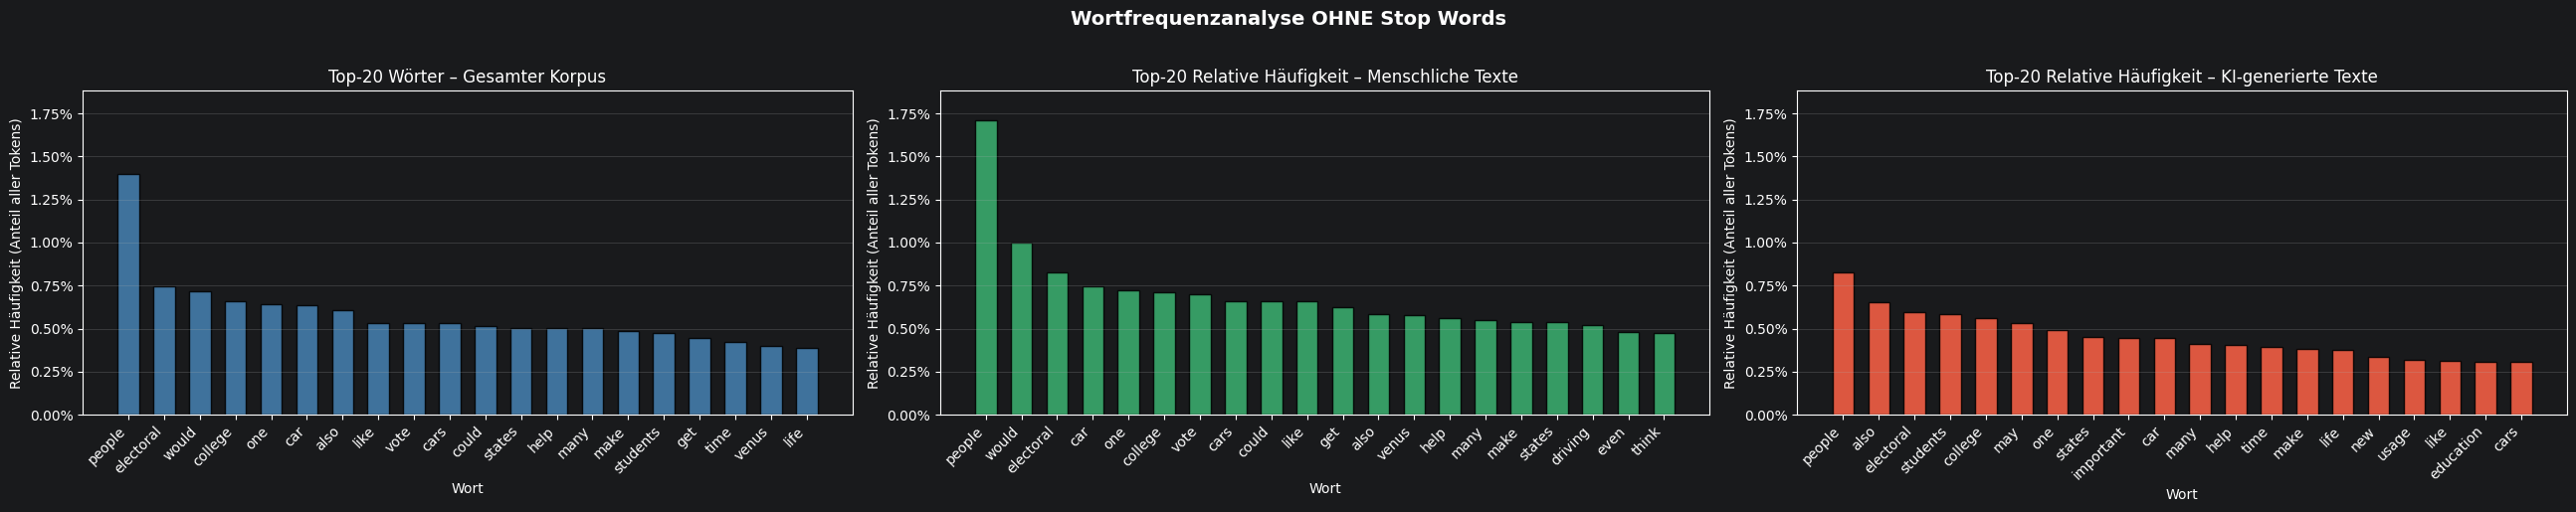

In [30]:
# Tokens für menschliche Texte extrahieren und Stop Words herausfiltern
human_tokens = whitespace_tokenize(" ".join(df[df["generated"] == 0]["text_clean"].tolist()))
# Tokens für KI-generierte Texte extrahieren und Stop Words herausfiltern
ai_tokens    = whitespace_tokenize(" ".join(df[df["generated"] == 1]["text_clean"].tolist()))

# Stop Words aus menschlichen Tokens entfernen (nur alphabetische Tokens behalten)
human_filtered = [t for t in human_tokens if t.isalpha() and t not in stop_words]
# Stop Words aus KI-Tokens entfernen (nur alphabetische Tokens behalten)
ai_filtered    = [t for t in ai_tokens    if t.isalpha() and t not in stop_words]

# Absolute Wortfrequenzen für den gefilterten Gesamtkorpus berechnen
word_freq_filtered = Counter(filtered_tokens)
# Absolute Wortfrequenzen für menschliche Texte ohne Stop Words berechnen
human_freq = Counter(human_filtered)
# Absolute Wortfrequenzen für KI-Texte ohne Stop Words berechnen
ai_freq    = Counter(ai_filtered)

# Gesamtanzahl aller gefilterten Tokens im Korpus für relative Häufigkeit des Gesamtkorpus
total_filtered = sum(word_freq_filtered.values())
# Gesamtanzahl gefilterter Tokens in menschlichen Texten für relative Häufigkeit
human_total = sum(human_freq.values())
# Gesamtanzahl gefilterter Tokens in KI-Texten für relative Häufigkeit
ai_total    = sum(ai_freq.values())

# Top-20 Wörter des gefilterten Gesamtkorpus bestimmen
corpus_top20 = [w for w, _ in word_freq_filtered.most_common(20)]
# Relative Häufigkeiten der Top-20 Wörter im gefilterten Gesamtkorpus berechnen
corpus_rel   = [word_freq_filtered.get(w, 0) / total_filtered for w in corpus_top20]

# Top-20 Wörter der menschlichen Texte bestimmen (absteigend sortiert)
human_top20 = [w for w, _ in human_freq.most_common(20)]
# Relative Häufigkeiten der menschlichen Top-20 berechnen
human_rel   = [human_freq.get(w, 0) / human_total for w in human_top20]

# Top-20 Wörter der KI-Texte bestimmen (unabhängig von der Mensch-Liste, absteigend sortiert)
ai_top20 = [w for w, _ in ai_freq.most_common(20)]
# Relative Häufigkeiten der KI Top-20 berechnen
ai_rel   = [ai_freq.get(w, 0) / ai_total for w in ai_top20]

# Einheitliches y-Achsen-Maximum über alle drei Diagramme berechnen
# (Maximum aller relativen Häufigkeiten + 10% Puffer für Lesbarkeit)
y_max = max(max(corpus_rel), max(human_rel), max(ai_rel)) * 1.1

# x-Positionen für die Gesamtkorpus-Balken berechnen
x_corpus = np.arange(len(corpus_top20))
# x-Positionen für die Balken der menschlichen Texte berechnen
x_human  = np.arange(len(human_top20))
# x-Positionen für die Balken der KI-Texte berechnen
x_ai     = np.arange(len(ai_top20))
# Breite eines einzelnen Balkens festlegen
width = 0.6

# 1x3 Layout anlegen: Gesamt-Korpus | Mensch | KI
fig, axes = plt.subplots(1, 3, figsize=(26, 5))
# Gemeinsamen Titel für alle drei Diagramme setzen
fig.suptitle("Wortfrequenzanalyse OHNE Stop Words", fontsize=14, fontweight="bold", y=1.02)

# ── Linkes Diagramm: Top-20 gesamt (relativ, blau) ─────────────────────────

# Balkendiagramm der relativen Häufigkeiten der Top-20 Wörter im gefilterten Gesamtkorpus zeichnen
axes[0].bar(x_corpus, corpus_rel, width,
            color="steelblue", edgecolor="black", alpha=0.85)
# x-Tick-Positionen auf die Wortpositionen setzen
axes[0].set_xticks(x_corpus)
# Wörter als Tick-Beschriftungen schräg stellen
axes[0].set_xticklabels(corpus_top20, rotation=45, ha="right")
# x-Achse beschriften
axes[0].set_xlabel("Wort")
# y-Achse beschriften
axes[0].set_ylabel("Relative Häufigkeit (Anteil aller Tokens)")
# y-Achse als Prozentwert formatieren
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.2f}%"))
# Einheitliches y-Achsen-Maximum setzen
axes[0].set_ylim(0, y_max)
# Titel des Diagramms setzen
axes[0].set_title("Top-20 Wörter – Gesamter Korpus")
# Horizontales Gitter für einfachere Ablesung der Werte einblenden
axes[0].grid(axis="y", alpha=0.3)

# ── Mittleres Diagramm: Top-20 Menschliche Texte (relativ, grün, sortiert) ─

# Balken für die menschlichen Top-20 Wörter zeichnen
axes[1].bar(x_human, human_rel, width,
            color="mediumseagreen", edgecolor="black", alpha=0.85)
# x-Tick-Positionen auf die Wortpositionen setzen
axes[1].set_xticks(x_human)
# Top-20 Wörter der Menschen als Tick-Beschriftungen schräg stellen
axes[1].set_xticklabels(human_top20, rotation=45, ha="right")
# x-Achse beschriften
axes[1].set_xlabel("Wort")
# y-Achse beschriften
axes[1].set_ylabel("Relative Häufigkeit (Anteil aller Tokens)")
# y-Achse als Prozentwert formatieren
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.2f}%"))
# Einheitliches y-Achsen-Maximum setzen
axes[1].set_ylim(0, y_max)
# Titel des Diagramms setzen
axes[1].set_title("Top-20 Relative Häufigkeit – Menschliche Texte")
# Horizontales Gitter für einfachere Ablesung der Werte einblenden
axes[1].grid(axis="y", alpha=0.3)

# ── Rechtes Diagramm: Top-20 KI-Texte (relativ, rot, sortiert) ─────────────

# Balken für die KI Top-20 Wörter zeichnen
axes[2].bar(x_ai, ai_rel, width,
            color="tomato", edgecolor="black", alpha=0.85)
# x-Tick-Positionen auf die Wortpositionen setzen
axes[2].set_xticks(x_ai)
# Top-20 Wörter der KI als Tick-Beschriftungen schräg stellen
axes[2].set_xticklabels(ai_top20, rotation=45, ha="right")
# x-Achse beschriften
axes[2].set_xlabel("Wort")
# y-Achse beschriften
axes[2].set_ylabel("Relative Häufigkeit (Anteil aller Tokens)")
# y-Achse als Prozentwert formatieren
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.2f}%"))
# Einheitliches y-Achsen-Maximum setzen
axes[2].set_ylim(0, y_max)
# Titel des Diagramms setzen
axes[2].set_title("Top-20 Relative Häufigkeit – KI-generierte Texte")
# Horizontales Gitter für einfachere Ablesung der Werte einblenden
axes[2].grid(axis="y", alpha=0.3)

# Layout automatisch optimieren damit nichts abgeschnitten wird
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Beobachtung nach Entfernung der Stop Words:**
Die verbleibenden häufigsten Wörter sind inhaltstragender (z. B. thematische Begriffe aus den Essay-Prompts). Diese Wörter sind potenziell aussagekräftiger für die Klassifikation, da sie inhaltliche statt grammatische Muster widerspiegeln.

Konkret dominieren nun Begriffe wie **"people", "electoral", "car", "college", "vote", "students", "cars"**. Die Wortmenge sinkt von ca. 11,2 Mio. auf ca. 4,8 Mio. Instances, das Vokabular von ca. 145.700 auf ca. 62.800 Types. Funktionswörter wie "the"/"and" sind verschwunden – inhaltlich ergibt das für die Prompt-Themen Sinn.

#### 2f. Einfluss der Vocabulary Size auf BPE

In [195]:
# BPE mit unterschiedlichen Vocabulary Sizes trainieren und Top-Tokens vergleichen
# Zu testende Vokabulargrößen
vocab_sizes = [500, 2000, 5000, 10000]
# Ergebnis-Dictionary anlegen
bpe_results = {}

# Über alle Vokabulargrößen iterieren
for vsize in vocab_sizes:
    # BPE-Tokenizer mit aktueller Vokabulargröße trainieren
    tok = train_bpe_tokenizer(sample_corpus, vocab_size=vsize)
    # Vokabular auslesen
    vocab = tok.get_vocab()
    # Häufigste Tokens im Beispieltext mit diesem Vokabular
    # Beispieltext mit aktuellem Tokenizer kodieren
    encoded = tok.encode(corpus_text)
    # Resultierende Tokens speichern
    bpe_results[vsize] = encoded.tokens

# Ergebnisse je Vokabulargröße ausgeben
for vsize, tokens in bpe_results.items():
    # Tokenanzahl und erste Tokens anzeigen
    print(f"Vocab Size = {vsize:>6} | Anzahl Tokens: {len(tokens):>3} | Erste Tokens: {tokens[:10]}")

Vocab Size =    500 | Anzahl Tokens: 20443629 | Erste Tokens: ['car', 'f', 'ree', 'c', 'ities', 'have', 'be', 'come', 'a', 'su']
Vocab Size =   2000 | Anzahl Tokens: 14197717 | Erste Tokens: ['carfree', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and']
Vocab Size =   5000 | Anzahl Tokens: 12239972 | Erste Tokens: ['carfree', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and']
Vocab Size =  10000 | Anzahl Tokens: 11619740 | Erste Tokens: ['carfree', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and']


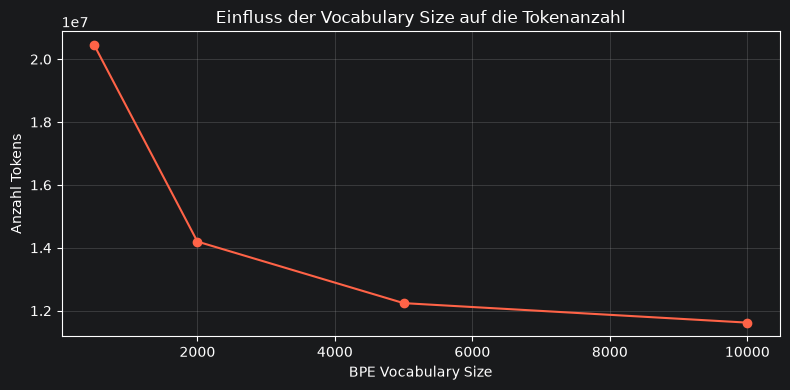

In [196]:
# Visualisierung: Anzahl Tokens je Vocabulary Size
# Tokenanzahl je Vokabulargröße sammeln
token_counts = [len(tokens) for tokens in bpe_results.values()]

# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(8, 4))
# Tokenanzahl gegen Vokabulargröße plotten
ax.plot(vocab_sizes, token_counts, marker="o", color="tomato")
# x-Achse beschriften
ax.set_xlabel("BPE Vocabulary Size")
# y-Achse beschriften
ax.set_ylabel("Anzahl Tokens")
# Titel setzen
ax.set_title("Einfluss der Vocabulary Size auf die Tokenanzahl")
# Gitter einblenden
ax.grid(alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Beobachtung:**
Mit **steigender Vocabulary Size** kann BPE mehr ganze Wörter direkt als ein einzelnes Token abbilden, statt sie in mehrere Subwort-Einheiten zu zerlegen → die Tokenanzahl für denselben Text **sinkt**. Bei einer **kleinen Vocabulary Size** werden Wörter stärker in kleinere Subwort-Bausteine zerlegt → mehr Tokens pro Text, aber kompakteres Vokabular insgesamt.

### 3. Vektorisierung

#### Theoretischer Hintergrund
**Vektorisierung** wandelt Texte in numerische Vektoren um, mit denen ML-Modelle rechnen
können. Drei klassische Ansätze:
- **Bag-of-Words (BoW):** zählt die Häufigkeit jedes Wortes; ignoriert Reihenfolge/Kontext.
- **TF-IDF:** gewichtet Wörter zusätzlich mit ihrer Seltenheit im Gesamtkorpus
  (Term Frequency × Inverse Document Frequency); seltene, aussagekräftige Wörter erhalten
  mehr Gewicht.
- **N-Gramme:** berücksichtigen Wortfolgen (z. B. Bigramme "in conclusion") und können so
  stilistische Muster erfassen – auf Kosten eines stark wachsenden Vokabulars.

Die Wahl der Vektorisierung beeinflusst die Modellgüte oft stärker als die Wahl des
Algorithmus selbst.

**Vorgehensweise:** Wir erstellen einen Train/Test-Split und vektorisieren die Texte mit
BoW, TF-IDF und verschiedenen N-Gramm-Bereichen. Anhand von Kennzahlen wie Matrix-Form,
Sparsity und Vokabulargröße vergleichen wir die Ansätze.

Im Folgenden vergleichen wir drei klassische Ansätze, um Texte in numerische Vektoren umzuwandeln, die ein ML-Modell verarbeiten kann.

In [51]:
# Train/Test Split für die Vektorisierungs-Experimente
# Daten geschichtet (stratify) in 80% Training und 20% Test aufteilen
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"], df["generated"], test_size=0.2, random_state=42, stratify=df["generated"]
)
# Größe der Trainings- und Testmenge ausgeben
print(f"Trainingsdaten: {len(X_train)} | Testdaten: {len(X_test)}")

Trainingsdaten: 23316 | Testdaten: 5829


#### 3a. Bag-of-Words (BoW)

In [52]:
# Bag-of-Words-Vektorisierer (max. 5000 Features, englische Stop Words entfernen)
bow_vectorizer = CountVectorizer(max_features=5000, stop_words="english")
# Auf Trainingsdaten fitten und transformieren
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Form der entstandenen Feature-Matrix ausgeben
print(f"BoW Feature-Matrix Shape: {X_train_bow.shape}")
# Beispielhafte Vokabeln ausgeben
print(f"Beispiel-Vokabular (10 Wörter): {bow_vectorizer.get_feature_names_out()[:10]}")
# Sparsity (Anteil der Null-Einträge) berechnen und ausgeben
print(f"\nSparsity (Anteil Nullen): {1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1]):.4f}")

BoW Feature-Matrix Shape: (23316, 5000)
Beispiel-Vokabular (10 Wörter): ['00' '000' '10' '100' '11' '114' '118' '12' '13' '14']

Sparsity (Anteil Nullen): 0.9795


Die Matrix, die beim BoW-Ansatz entsteht, beschreibt, wie häufig jedes Wort in jedem Eintrag vorkommt.

Die **Sparsity** beschreibt nun, dass die erzeugte Matrix größtenteils aus Nullen besteht (97, 95% der Einträge der Matrix sind 0).

**Eigenschaften von Bag-of-Words:**
- Zählt nur, *wie oft* ein Wort vorkommt – ignoriert Wortreihenfolge und Kontext.
- Sehr einfach und schnell zu berechnen.
- Häufige Wörter dominieren den Vektor (auch ohne inhaltliche Relevanz).


#### 3b. TF-IDF

In [53]:
# TF-IDF-Vektorisierer (sublinear_tf dämpft sehr hohe Häufigkeiten)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", sublinear_tf=True)
# Auf Trainingsdaten fitten und transformieren
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Form der TF-IDF-Matrix ausgeben
print(f"TF-IDF Feature-Matrix Shape: {X_train_tfidf.shape}")

# Vergleich der Gewichtung eines Beispielworts
# Index eines Beispielworts aus dem Vokabular wählen
sample_word_idx = list(tfidf_vectorizer.vocabulary_.values())[0]
# Zugehöriges Wort bestimmen
sample_word = tfidf_vectorizer.get_feature_names_out()[sample_word_idx]
# Beispielwort ausgeben
print(f"\nBeispiel-Feature: '{sample_word}'")
# BoW-Zählwert dieses Worts in Dokument 0 ausgeben
print(f"  BoW-Wert (Dokument 0):   {X_train_bow[0, sample_word_idx]}")
# TF-IDF-Gewicht dieses Worts in Dokument 0 ausgeben
print(f"  TF-IDF-Wert (Dokument 0): {X_train_tfidf[0, sample_word_idx]:.4f}")

TF-IDF Feature-Matrix Shape: (23316, 5000)

Beispiel-Feature: 'essay'
  BoW-Wert (Dokument 0):   1
  TF-IDF-Wert (Dokument 0): 0.1068


**Eigenschaften von TF-IDF:**
- Gewichtet Wörter danach, wie **selten** sie im Gesamtkorpus sind (Inverse Document Frequency).
- Wörter, die in vielen Dokumenten vorkommen (z. B. "essay", "people"), erhalten ein niedrigeres Gewicht.
- Seltene, aber in einem Dokument häufige Wörter erhalten ein höheres Gewicht → meist aussagekräftiger als BoW.

#### 3c. N-Gram Ansatz – verschiedene N-Werte testen

In [54]:
# Zu testende N-Gramm-Bereiche
ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2)]
# Ergebnisliste anlegen
ngram_results = []

# Über alle N-Gramm-Bereiche iterieren
for ngram_range in ngram_ranges:
    # TF-IDF-Vektorisierer mit aktuellem N-Gramm-Bereich
    vec = TfidfVectorizer(max_features=5000, stop_words="english",
                          ngram_range=ngram_range, sublinear_tf=True)
    # Auf Trainingsdaten anwenden
    X_ngram = vec.fit_transform(X_train)

    # Kennzahlen für diesen Bereich speichern
    ngram_results.append({
        # N-Gramm-Bereich als Text
        "N-Gram Range": str(ngram_range),
        # Größe des entstandenen Vokabulars
        "Vokabulargröße": len(vec.vocabulary_),
        # Einige Beispiel-Features
        "Beispiel-Features": ", ".join(vec.get_feature_names_out()[-5:])
    })

# Ergebnisse als DataFrame
ngram_df = pd.DataFrame(ngram_results)
# Tabelle ausgeben
ngram_df

,N-Gram Range,Vokabulargröße,Beispiel-Features
0,"(1, 1)",5000,"zero, zip, zone, zones, zygomatic"
1,"(1, 2)",5000,"younger students, youth, zip, zone, zones"
2,"(1, 3)",5000,"younger people, younger students, youth, zip, ..."
3,"(2, 2)",5000,"younger people, younger students, zip code, zi..."


**Was fällt auf?**
- **Unigrams (1,1):** Einzelne Wörter – kompaktes Vokabular, aber kein Kontext.
- **Bigrams/Trigrams (1,2), (1,3):** Erfassen Wortkombinationen (z. B. "I think", "in conclusion") – können stilistische Muster abbilden, die für KI- vs. Menschtexte typisch sind (z. B. typische LLM-Phrasen).
- **Reine Bigrams (2,2):** Verlieren einzelne Wörter komplett, was oft zu Informationsverlust führt.
- Mit steigendem N wächst die Anzahl möglicher Kombinationen exponentiell – bei fixiertem `max_features` werden daher viele seltene Wortkombinationen nicht mehr abgedeckt.

Da `max_features=5000` alle Varianten begrenzt, bleibt die Vokabulargröße konstant bei 5000; bei größerem N rücken jedoch zunehmend Mehrwortphrasen statt Einzelwörter ins Vokabular. **Für die KI-Text-Erkennung erscheint der Bereich (1,2)** am vielversprechendsten: Er behält die starken Einzelwörter und ergänzt typische Phrasenmuster, ohne – wie reine Bigramme – die aussagekräftigen Unigramme zu verlieren.

### Fazit

##### Zusammenfassung der Erkenntnisse

| Aspekt | Erkenntnis                                                                      |
|--------|---------------------------------------------------------------------------------|
| Word Types / Instances | **85.923** Word Types bei **11.140.109** Word Instances (TTR ≈ 0,0077)          |
| Whitespace vs. BPE | BPE zerlegt in Subwörter, robuster bei seltenen/unbekannten Wörtern             |
| Stop Words | Ohne Entfernung dominieren Funktionswörter – wenig hilfreich für Klassifikation |
| BPE Vocabulary Size | Größeres Vokabular → weniger, aber größere Tokens pro Text   |
| BoW vs. TF-IDF | TF-IDF gewichtet seltene, aussagekräftige Wörter stärker                        |
| N-Gramme | Höhere N erfassen Phrasenmuster, aber Vokabular wächst stark                    |

##### Empfehlung für das Klassifikationsproblem

Für die KI-Texterkennung erscheint **TF-IDF mit Wort-N-Grammen im Bereich (1,2)** am
geeignetsten: TF-IDF dämpft häufige, wenig unterscheidende Wörter und hebt seltene,
klassenspezifische Begriffe hervor, während die Bigramme typische Formulierungsmuster von
LLMs (z. B. wiederkehrende Übergangsphrasen) erfassen. Reine BoW-Zählungen oder reine
Bigramme schneiden erfahrungsgemäß schlechter ab. Diese Einschätzung wird am Ende des
Notebooks im Abschnitt *Optimierung der Vektorisierung & Tokenisierung* empirisch überprüft.

## Übungsblatt 6

### Aufgabenstellung

**1 Input- und Output Variablen**
- [X] Welche sind die Input- und Output Variablen in dem von Ihnen gewählten Datensatz?
- [X] Dokumentieren Sie im Jupyter Notebook.

**2 Prediction vs. Inference**
- [X] Formulieren Sie für Ihren Datensatz eine Fragestellung für Prediction und Inference.
- [X] Dokumentieren Sie im Juypter Notebook.

**3 Klassifikation vs. Regression**
- [X] Welches Machine Learning Problem können Sie anhand Ihres Datensatzes angehen: Regression oder Klassifikation?
- [X] Dokumentieren Sie im Juypter Notebook.

### 1 Input- und Output Variablen

#### Theoretischer Hintergrund
Beim überwachten Lernen unterscheidet man **Input-Variablen (Features)** – die das Modell
als Eingabe erhält – und die **Output-Variable (Zielvariable/Label)**, die das Modell
vorhersagen soll. Nicht jede Spalte ist als Feature geeignet: reine Identifikatoren tragen
keine inhaltliche Information. Da Modelle nicht direkt mit Rohtext arbeiten, müssen Texte
über **Feature Engineering** (z. B. Textlänge) oder **Vektorisierung** (TF-IDF, Embeddings)
in numerische Merkmale überführt werden.

**Vorgehensweise:** Wir ordnen jede Spalte ihrer Rolle (Input/Output/kein Feature) zu und
leiten aus dem Rohtext numerische Features (Textlänge, Wortanzahl, Satzanzahl,
durchschnittliche Wortlänge) ab.

#### Überblick der Variablen

| Variable | Typ | Rolle | Begründung |
|----------|-----|-------|------------|
| `text` | Freitext (String) | **Input (Feature)** | Der Essay-Text ist die einzige Informationsquelle für die Klassifikation |
| `generated` | Binär (0/1) | **Output (Zielvariable)** | Das Modell soll vorhersagen, ob ein Text KI-generiert ist |

#### Input-Variable: `text`

Da Modelle nicht direkt mit Rohtexten arbeiten können, wird `text` in numerische Features umgewandelt.

In [203]:
# Input-Variable: Text-Features ableiten (Feature Engineering)
# Anzahl "Sätze" (grob über Satzendzeichen geschätzt)
df["sentence_count"] = df["text"].str.split(r'[.!?]+').str.len()
# Durchschnittliche Wortlänge je Text berechnen
df["avg_word_length"] = df["text_clean"].apply(
    lambda t: sum(len(w) for w in t.split()) / max(len(t.split()), 1)
)

In [204]:
# Output-Variable: Verteilung
# Hinweis ausgeben
print("Verteilung der Zielvariable 'generated':")
# Häufigkeit beider Klassen ausgeben
print(df["generated"].value_counts())
# Bedeutung der Klassen erläutern
print(f"\n0 = menschlich geschrieben\n1 = KI-generiert")

Verteilung der Zielvariable 'generated':
generated
0    17508
1    11637
Name: count, dtype: int64

0 = menschlich geschrieben
1 = KI-generiert


### 2 Prediction vs. Inference

#### Theoretischer Hintergrund
**Prediction** und **Inference** sind zwei Ziele des maschinellen Lernens:
- **Prediction (Vorhersage):** Ziel ist eine möglichst genaue Vorhersage für neue,
  ungesehene Daten. Die Interpretierbarkeit ist zweitrangig – auch "Black-Box"-Modelle
  sind akzeptabel.
- **Inference (Schlussfolgern):** Ziel ist das *Verständnis* der Zusammenhänge zwischen
  Features und Ziel. Hier sind interpretierbare Modelle (z. B. Logistische Regression,
  Entscheidungsbäume mit Feature Importance) gefragt.

**Vorgehensweise:** Wir formulieren je eine Prediction- und eine Inference-Fragestellung für
unseren Datensatz und untersuchen explorativ (Histogramme der Text-Features nach Klasse),
ob sich KI- und Menschentexte in messbaren Merkmalen unterscheiden.

#### Prediction (Vorhersage)

> **Fragestellung:** *Gegeben einen neuen, unbekannten Essay-Text – wurde er von einem Menschen oder einer KI geschrieben?*

- Ziel: Möglichst genaue Vorhersage der Klasse `generated` für neue, ungesehene Texte
- Die Interpretierbarkeit des Modells ist zweitrangig
- Geeignete Modelle: Random Forest, Gradient Boosting, neuronale Netze

#### Inference (Analyse / Schlussfolgern)

> **Fragestellung:** *Welche sprachlichen Merkmale eines Textes sind charakteristisch für KI-generierte Essays? Hat z. B. die Textlänge oder der Wortschatz einen signifikanten Einfluss auf die Klassenzugehörigkeit?*

- Ziel: Verstehen, *warum* ein Text als KI-generiert eingestuft wird
- Interpretierbarkeit des Modells ist wichtig
- Geeignete Modelle: Logistic Regression, Decision Tree (mit Feature Importance)

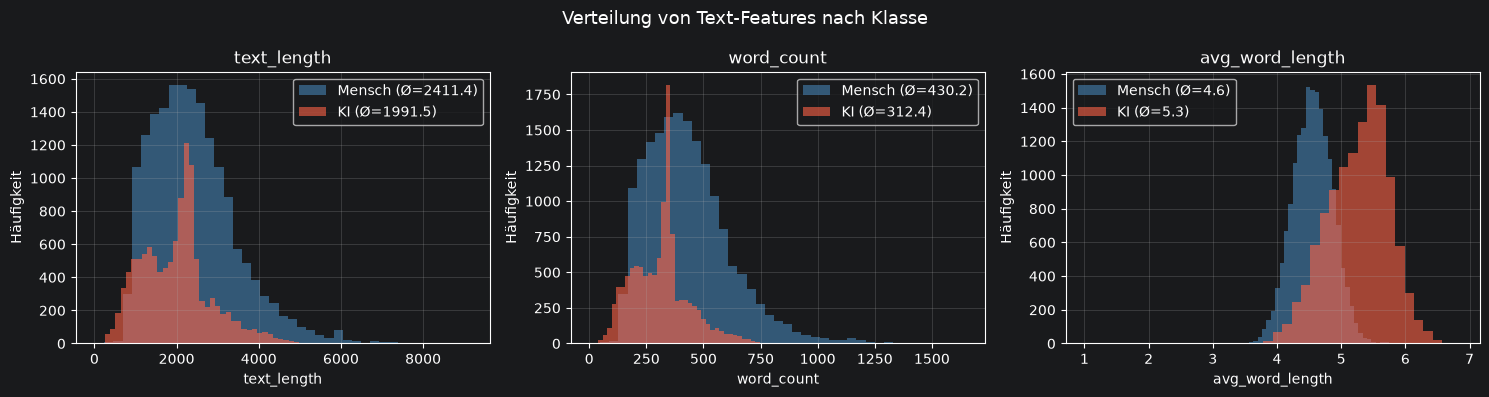

In [58]:
# Inference-Beispiel: Unterscheiden sich KI- und menschliche Texte in messbaren Merkmalen?
# Zu untersuchende Features festlegen
features = ["text_length", "word_count", "avg_word_length"]

# Drei nebeneinanderliegende Histogramme anlegen
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Über Achsen und Features iterieren
for ax, feat in zip(axes, features):
    # Für beide Klassen je ein Histogramm zeichnen
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        # Werte des Features für die aktuelle Klasse auswählen
        subset = df[df["generated"] == label][feat]
        # Histogramm mit Mittelwert in der Legende
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f"{'Mensch' if label==0 else 'KI'} (Ø={subset.mean():.1f})")
    # Titel je Feature
    ax.set_title(feat)
    # x-Achse beschriften
    ax.set_xlabel(feat)
    # y-Achse beschriften
    ax.set_ylabel("Häufigkeit")
    # Legende anzeigen
    ax.legend()
    # Gitter einblenden
    ax.grid(alpha=0.3)

# Übertitel setzen
plt.suptitle("Verteilung von Text-Features nach Klasse", fontsize=13)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Erkenntnis:**
- Die `text_length` der menschlichen Texte ist in der Regel deutlich höher, als die der KI-generierten Texte.
- Die menschlichen Texte haben hauptsächlich einen `word_count` zwischen ca. 200 und 550. Die KI-generierten Texte haben jedoch auffälligerweise eine sehr große Häufigkeit von einem `word_count` von ca. 350.
- KI-genrierte Texte haben im Durchschnitt eine höhere `avg_word_length` als menschliche Texte.

### 3 Klassifikation vs. Regression

#### Theoretischer Hintergrund
Die Art der Zielvariable bestimmt den Problemtyp:
- **Klassifikation:** diskrete, kategoriale Zielvariable (z. B. Mensch vs. KI). Bei genau
  zwei Klassen spricht man von **binärer Klassifikation**.
- **Regression:** kontinuierliche, numerische Zielvariable (z. B. ein Preis, eine Länge).

Da unser Label `generated` binär ist (0/1), handelt es sich eindeutig um ein
Klassifikationsproblem.

#### Klassifikation

Die Zielvariable `generated` ist **binär** (0 oder 1) – es gibt genau zwei diskrete Klassen:
- Klasse 0: Essay wurde von einem **Menschen** verfasst
- Klasse 1: Essay wurde von einer **KI** (LLM) generiert

Dies ist ein typisches **binäres Klassifikationsproblem**.

**Warum kein Regressionsproblem?**
Regression würde einen kontinuierlichen Ausgabewert vorhersagen (z. B. einen Preis oder eine Temperatur). Hier ist der Output diskret und kategorial, daher ist Klassifikation die passende Methode.

In [206]:
# Zusammenfassung
# Kernaussagen aus Übungsblatt 6 als Dictionary sammeln
summary = {
    "Input-Variablen": ["text (Hauptfeature)"],
    "Output-Variable": ["generated (0=Mensch, 1=KI)"],
    "Prediction-Frage": ["Ist ein neuer Essay KI-generiert?"],
    "Inference-Frage": ["Welche Textmerkmale sind typisch für KI-Texte?"],
    "ML-Problem": ["Binäre Klassifikation"],
}

# Jede Kernaussage formatiert ausgeben
for key, val in summary.items():
    # Schlüssel und Wert in fester Spaltenbreite ausgeben
    print(f"{key:25s}: {val[0]}")

Input-Variablen          : text (Hauptfeature)
Output-Variable          : generated (0=Mensch, 1=KI)
Prediction-Frage         : Ist ein neuer Essay KI-generiert?
Inference-Frage          : Welche Textmerkmale sind typisch für KI-Texte?
ML-Problem               : Binäre Klassifikation


## Übungsblatt 7

### Aufgabenstellung

**1 Training und Test von Modellen**

Verwenden Sie die in der Vorlesung besprochenen Klassifikationsmodelle und finden
Sie das Modell mit der höchsten Vorhersagegenauigkeit bzw. dem kleinsten Fehler
(wählen Sie geeignete Metriken). Vergleichen Sie verschiedene Modelltypen. Variieren
Sie Parameter je Modelltyp.
- [X] Teilen Sie den Datensatz in Trainings-, Validierungs- und Testdaten auf. Verwenden Sie Testdaten nicht für Modellentscheidungen.
- [X] Trainieren Sie Modelle basierend auf den Trainingsdaten.
- [X] Vergleichen Sie basierend auf einer passenden Metrik.
- [X] Wählen Sie das beste Modell und testen Sie es, basierend auf bisher ungesehenen Testdaten.
- [X] Prüfen Sie eine Stichprobe bzgl. Modellvorhersage und echtem Wert.
- [X] Vergleichen Sie verschiedene Modelle bzgl. Trainings- und Validierungsmetrik, erstellen Sie eine Grafik.
- [X] Dokumentieren Sie die Erkenntnisse und bewerten Sie die Ergebnisse kritisch. Womit haben Sie gerechnet, was hat Sie überrascht?

### Vorgehensweise (für alle Modelle)

Für jedes Modell gehen wir nach demselben Schema vor, um eine faire Vergleichbarkeit zu
gewährleisten:
1. **Datenaufteilung** in Trainings-, Validierungs- und Testdaten (60/20/20). Die Testdaten
   werden ausschließlich für die finale Bewertung verwendet, niemals für Modellentscheidungen.
2. **Feature Extraction** (i. d. R. TF-IDF; bei KNN zusätzlich Dimensionsreduktion, beim
   LSTM Tokenisierung + Padding).
3. **Training & Hyperparameter-Variation** auf den Trainingsdaten, Auswahl der besten
   Konfiguration anhand der Validierungsmetrik.
4. **Finale Evaluation** des besten Modells auf den Testdaten.
5. **Stichprobenprüfung** sowie kritische Bewertung der Ergebnisse.

**Gewählte Metriken:** Da unsere Klassen leicht unausgewogen sind (ca. 60 % Mensch / 40 % KI),
betrachten wir neben der **Accuracy** insbesondere den **F1-Score** (harmonisches Mittel aus
Precision und Recall). Der F1-Score ist robuster gegenüber Klassenungleichgewicht und ist
auch die Zielmetrik unseres SMART-Ziels.

#### Cross-Validation

##### Theoretischer Hintergrund

**Cross-Validation (Kreuzvalidierung)** ist keine eigene Modellklasse, sondern eine **Evaluierungsmethode**, die robustere Schätzungen der Modellgüte liefert als ein einfacher Train/Val-Split.

###### k-Fold Cross-Validation:
1. Der Datensatz wird in **k gleich große Teile (Folds)** aufgeteilt.
2. Das Modell wird **k-mal** trainiert – jedes Mal ist ein anderes Fold das Validierungsset, der Rest ist Trainingsdaten.
3. Die k Ergebnisse werden gemittelt → stabilere Schätzung, weniger abhängig vom Zufall des Splits.

###### Vorteile gegenüber einfachem Train/Val-Split:
- Jedes Sample wird genau einmal zur Validierung verwendet
- Geringere Varianz der Schätzung
- Besonders nützlich bei kleineren Datensätzen

###### Warum ist Cross-Validation besser als ein einfacher Split?

- Ein einzelner Train/Val-Split kann je nach Zufall der Aufteilung stark variieren.
- 5-Fold CV nutzt die Daten effizienter – jeder Datenpunkt wird einmal validiert.
- Das Std der Fold-Scores zeigt, wie stabil das Modell wirklich ist.

###### Stärken von k-Fold CV

- Robustere Modellschätzung, weniger zufällig
- Gibt Aufschluss über Modellstabilität (Std)

###### Schwächen von k-Fold mit CV

- k-facher Rechenaufwand gegenüber einfachem Split
- Bei sehr großen Datensätzen oft impraktikabel

> In diesem Notebook wenden wir (k-Fold) Cross-Validation nicht an, da der Rechenaufwand von der zur Verfügung stehenden Hardware nur schlecht bewältigt werden kann.

### K-Nearest Neighbors

#### Theoretischer Hintergrund

**K-Nearest Neighbors (KNN)** ist ein instanzbasierter Lernalgorithmus ohne explizite Trainingsphase:
- Zur Klassifikation eines neuen Datenpunkts werden die **k nächsten Nachbarn** im Feature-Raum gesucht.
- Die Klasse wird per **Mehrheitsvotum** der k Nachbarn bestimmt.
- Die Distanz wird typischerweise mit der **euklidischen Distanz** gemessen.
- **Hyperparameter k**: Klein → hohes Overfitting-Risiko; Groß → Glattere Entscheidungsgrenze, aber ggf. Underfitting.

> **Hinweis für diesen Datensatz:** KNN auf rohem TF-IDF ist sehr rechenintensiv (10.000-dimensionaler Raum). Wir reduzieren die Dimensionen mit **TruncatedSVD (LSA)** und begrenzen die Datenmenge für schnelle Ausführung.

**Vorgehensweise:** Wir reduzieren den hochdimensionalen TF-IDF-Raum mittels TruncatedSVD (LSA) auf 100 Komponenten und normalisieren die Vektoren. Anschließend trainieren wir KNN für verschiedene Werte von `k`, wählen das beste `k` anhand von Validierungs-Accuracy und F1-Score und evaluieren es final auf den Testdaten.

#### Train / Validation / Test Split

Der Datensatz wird in drei Teile aufgeteilt:
- **Trainingsdaten (60 %)**: Zum Trainieren der Modelle
- **Validierungsdaten (20 %)**: Zur Modellauswahl und Hyperparameter-Tuning
- **Testdaten (20 %)**: Nur für die finale Evaluation des besten Modells

**Wichtig:** Testdaten werden erst ganz am Ende verwendet!

In [207]:
# Eingabevariable (Text) festlegen
X = df["text_clean"]
# Zielvariable (Label) festlegen
y = df["generated"]

# Erst Train+Val / Test aufteilen
# 80% Train+Val, 20% Test (geschichtet)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Dann Train / Validation aufteilen
# Von den 80% nochmals 25% als Validierung abzweigen -> 60/20/20 insgesamt
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# Größe der Trainingsmenge und Anteil ausgeben
print(f"Trainingsdaten:    {len(X_train):>5} Samples ({len(X_train)/len(X)*100:.0f}%)")
# Größe der Validierungsmenge ausgeben
print(f"Validierungsdaten: {len(X_val):>5} Samples ({len(X_val)/len(X)*100:.0f}%)")
# Größe der Testmenge ausgeben
print(f"Testdaten:         {len(X_test):>5} Samples ({len(X_test)/len(X)*100:.0f}%)")

Trainingsdaten:    17487 Samples (60%)
Validierungsdaten:  5829 Samples (20%)
Testdaten:          5829 Samples (20%)


#### Feature Extraction – TF-IDF  + Dimensionsreduktion (LSA)

KNN berechnet Abstände zwischen allen Punkten – im 10.000-dimensionalen TF-IDF-Raum ist das sehr langsam.

Lösung: **Truncated SVD** (= Latent Semantic Analysis) reduziert die Dimensionen auf 100, ohne wesentliche Information zu verlieren.

**Truncated SVD**  ist ein Verfahren zur Dimensionsreduktion. Es reduziert die Anzahl der Features einer Matrix, indem nur die wichtigsten Informationen erhalten bleiben. Es werden sozusagen "abstrakte" Dimension gebildet, die ähnliche Wörter zusammenfassen.

In [208]:
# TF-IDF → Dimensionsreduktion auf 100 Komponenten → Normalisierung
# TF-IDF-Vektorisierer (max. 5000 Features)
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
# TruncatedSVD reduziert auf 100 latente Dimensionen (LSA)
svd   = TruncatedSVD(n_components=100, random_state=42)
# Normalizer bringt jeden Vektor auf Länge 1 (gut für Distanzen)
norm  = Normalizer(copy=False)

# Fit nur auf Trainingsdaten!
# TF-IDF auf Trainingsdaten fitten und transformieren
X_train_tfidf = tfidf.fit_transform(X_train)
# SVD auf den TF-IDF-Trainingsdaten fitten und transformieren
X_train_svd   = svd.fit_transform(X_train_tfidf)
# Trainingsvektoren normalisieren
X_train_norm  = norm.fit_transform(X_train_svd)

# Validierungsdaten mit denselben (gefitteten) Schritten transformieren
X_val_norm    = norm.transform(svd.transform(tfidf.transform(X_val)))
# Testdaten ebenso transformieren
X_test_norm   = norm.transform(svd.transform(tfidf.transform(X_test)))

# Form nach TF-IDF ausgeben
print(f"Shape nach TF-IDF:  {X_train_tfidf.shape}")
# Form nach SVD ausgeben
print(f"Shape nach SVD:     {X_train_svd.shape}")
# Erklärte Varianz der SVD ausgeben
print(f"Erklärte Varianz durch SVD: {svd.explained_variance_ratio_.sum()*100:.1f}%")

Shape nach TF-IDF:  (17487, 5000)
Shape nach SVD:     (17487, 100)
Erklärte Varianz durch SVD: 28.6%


#### Modell trainieren & Hyperparameter k vergleichen

Wir testen verschiedene Werte für k, um den optimalen Parameter zu finden.

In [209]:
# Zu testende Werte für k (Anzahl Nachbarn)
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
# Ergebnisliste anlegen
results = []

# Über alle k-Werte iterieren
for k in k_values:
    # KNN-Klassifikator mit aktuellem k anlegen
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    # Modell auf Trainingsdaten anpassen
    knn.fit(X_train_norm, y_train)

    # Trainings-Accuracy berechnen
    train_acc = accuracy_score(y_train, knn.predict(X_train_norm))
    # Validierungs-Accuracy berechnen
    val_acc   = accuracy_score(y_val,   knn.predict(X_val_norm))
    # Validierungs-F1-Score berechnen (Zielmetrik des SMART-Ziels)
    val_f1    = f1_score(y_val, knn.predict(X_val_norm))

    # Kennzahlen für dieses k speichern (inkl. F1)
    results.append({"k": k, "Train Accuracy": round(train_acc, 4),
                    "Val Accuracy": round(val_acc, 4), "Val F1": round(val_f1, 4)})
    # Zwischenergebnis ausgeben (inkl. F1)
    print(f"k={k:>2} | Train: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Ergebnisse als DataFrame
results_df = pd.DataFrame(results)
# Tabelle ausgeben
results_df

k= 1 | Train: 1.0000 | Val Acc: 0.9942 | Val F1: 0.9927
k= 3 | Train: 0.9975 | Val Acc: 0.9942 | Val F1: 0.9927
k= 5 | Train: 0.9969 | Val Acc: 0.9945 | Val F1: 0.9931
k= 7 | Train: 0.9961 | Val Acc: 0.9947 | Val F1: 0.9933
k=10 | Train: 0.9954 | Val Acc: 0.9938 | Val F1: 0.9922
k=15 | Train: 0.9947 | Val Acc: 0.9935 | Val F1: 0.9918
k=20 | Train: 0.9932 | Val Acc: 0.9914 | Val F1: 0.9892
k=30 | Train: 0.9907 | Val Acc: 0.9897 | Val F1: 0.9870


,k,Train Accuracy,Val Accuracy,Val F1
0,1,1.0000,0.9942,0.9927
1,3,0.9975,0.9942,0.9927
2,5,0.9969,0.9945,0.9931
3,7,0.9961,0.9947,0.9933
4,10,0.9954,0.9938,0.9922
5,15,0.9947,0.9935,0.9918
6,20,0.9932,0.9914,0.9892
7,30,0.9907,0.9897,0.9870


#### Visualisierung – Einfluss von k auf die Accuracy

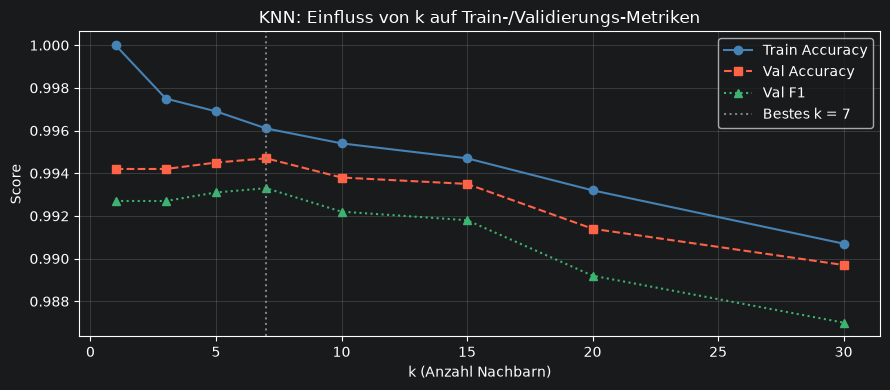


Bestes k (nach Val Accuracy): k = 7


In [210]:
# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(9, 4))

# Train-Accuracy gegen k plotten
ax.plot(results_df["k"], results_df["Train Accuracy"], marker="o", label="Train Accuracy", color="steelblue")
# Validierungs-Accuracy gegen k plotten
ax.plot(results_df["k"], results_df["Val Accuracy"],   marker="s", label="Val Accuracy",   color="tomato", linestyle="--")
# Zusätzlich den Validierungs-F1 plotten
ax.plot(results_df["k"], results_df["Val F1"],         marker="^", label="Val F1",         color="mediumseagreen", linestyle=":")

# Bestes k (höchste Val-Accuracy) bestimmen
best_k = results_df.loc[results_df["Val Accuracy"].idxmax(), "k"]
# Bestes k als vertikale Linie markieren
ax.axvline(x=best_k, color="gray", linestyle=":", label=f"Bestes k = {best_k}")

# x-Achse beschriften
ax.set_xlabel("k (Anzahl Nachbarn)")
# y-Achse beschriften
ax.set_ylabel("Score")
# Titel setzen
ax.set_title("KNN: Einfluss von k auf Train-/Validierungs-Metriken")
# Legende anzeigen
ax.legend()
# Gitter einblenden
ax.grid(alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

# Bestes k ausgeben
print(f"\nBestes k (nach Val Accuracy): k = {best_k}")

**Beobachtung:**
- Bei **kleinem k** (z.B. k=1) ist der Train-Accuracy sehr hoch → starkes Overfitting.
- Mit wachsendem k sinkt der Train-Val-Gap → das Modell generalisiert besser.
- Ab einem bestimmten k sinkt auch die Val-Accuracy wieder → Underfitting.

→ Das am besten geeignete k ist 7, da hier höchste Train Accuracy in Kombination mit einer hohen Val Accuracy und einem hohen F1-Score auftritt.

**Overfitting** meint, dass das Modell zu einfach ist und die Zusammenhänge in den Daten nicht ausreichend lernt. Dadurch macht es sowohl auf den Trainings- als auch auf den Testdaten viele Fehler.

**Underfitting** meint, dass das Modell zu komplex ist. Im Gegensatz zum Overfitting lernt es die Trainingsdaten nahezu auswendig. So erzielt es zwar eine sehr hohe Genauigkeit auf den Trainingsdaten. macht aber viele Fehler auf den Testdaten.

#### Bestes Modell auf Testdaten evaluieren

In [211]:
# Bestes k auswählen
# Bestes k anhand der höchsten Validierungs-Accuracy bestimmen
best_k = results_df.loc[results_df["Val Accuracy"].idxmax(), "k"]
# Gewähltes k ausgeben
print(f"Gewähltes k: {best_k}")

# Finales Modell trainieren und auf Testdaten anwenden
# KNN mit bestem k anlegen
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
# Auf Trainingsdaten anpassen
knn_best.fit(X_train_norm, y_train)

# Vorhersagen für die Testdaten erstellen
y_pred_test = knn_best.predict(X_test_norm)
# Test-Accuracy berechnen
test_acc    = accuracy_score(y_test, y_pred_test)
# Test-F1-Score berechnen (Zielmetrik des SMART-Ziels)
test_f1     = f1_score(y_test, y_pred_test)

# Test-Accuracy ausgeben
print(f"Test Accuracy: {test_acc:.4f}")
# Test-F1-Score ausgeben
print(f"Test F1-Score: {test_f1:.4f}")
# Detaillierten Klassifikationsbericht ausgeben
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))

Gewähltes k: 7
Test Accuracy: 0.9928
Test F1-Score: 0.9909

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.99      1.00      0.99      3502
      KI (1)       0.99      0.99      0.99      2327

    accuracy                           0.99      5829
   macro avg       0.99      0.99      0.99      5829
weighted avg       0.99      0.99      0.99      5829



**Precision** meint, wie viele der als positiv vorhergesagten Beispiele tatsächlich positiv sind.

**Recall** meint, wie viele der tatsächlich positiven Beispiele erkannt wurden.

Der **F1-Score** kombiniert Precision und Recall zu einer einzigen Kennzahl, die nur dann hoch ist, wenn sowohl Precision als auch Recall hoch sind.

Wir erstellen nun eine Konfusionsmatrix.

Eine Konfusionsmatrix ist eine Tabelle, die zeigt, wie gut ein Klassifikationsmodell
funktioniert – und zwar nicht nur ob es richtig oder falsch liegt, sondern **wo genau**
es Fehler macht.

##### Aufbau (am Beispiel: Mensch vs. KI)

|  | **Vorhergesagt: Mensch** | **Vorhergesagt: KI** |
|---|---|---|
| **Tatsächlich: Mensch** | True Negative (TN) | False Positive (FP) |
| **Tatsächlich: KI** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP):** Modell sagt KI → ist tatsächlich KI
- **True Negative (TN):** Modell sagt Mensch → ist tatsächlich Mensch
- **False Positive (FP):** Modell sagt KI → ist aber ein Mensch (Falschalarm)
- **False Negative (FN):** Modell sagt Mensch → ist aber KI (übersehen)

##### Metriken aus der Konfusionsmatrix

| Metrik | Formel | Bedeutung |
|--------|--------|-----------|
| **Accuracy** | (TP + TN) / alle | Gesamtanteil korrekt |
| **Precision** | TP / (TP + FP) | Von allen als KI eingestuften: wie viele waren wirklich KI? |
| **Recall** | TP / (TP + FN) | Von allen echten KI-Texten: wie viele hat das Modell erkannt? |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonisches Mittel – sinnvoll bei ungleichen Klassen |

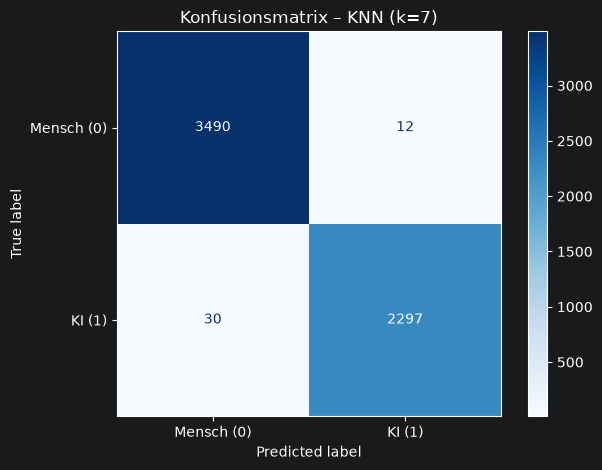

In [212]:
# Konfusionsmatrix
# Konfusionsmatrix aus echten und vorhergesagten Labels berechnen
cm = confusion_matrix(y_test, y_pred_test)
# Anzeige-Objekt für die Konfusionsmatrix erstellen
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"])
# Konfusionsmatrix plotten
disp.plot(cmap="Blues")
# Titel mit gewähltem k setzen
plt.title(f"Konfusionsmatrix – KNN (k={best_k})")
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Stichprobe: Vorhersage vs. echtem Wert

In [214]:
# 10 zufällige Test-Beispiele auswählen
sample_idx   = X_test.sample(10, random_state=7).index
# Zugehörige Texte holen
sample_texts = X_test.loc[sample_idx]
# Zugehörige echte Labels holen
sample_true  = y_test.loc[sample_idx]
# Beispieltexte mit derselben Pipeline transformieren
sample_norm  = norm.transform(svd.transform(tfidf.transform(sample_texts)))
# Vorhersagen für die Beispiele erstellen
sample_pred  = knn_best.predict(sample_norm)

# Vergleichstabelle (Text, Wahrheit, Vorhersage, Korrektheit) erstellen
pd.DataFrame({
    # Textausschnitt (erste 80 Zeichen)
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    # Echtes Label
    "Wahrer Wert":       sample_true.values,
    # Vorhergesagtes Label
    "Vorhersage":        sample_pred,
    # War die Vorhersage korrekt?
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})

,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,the face on mars was not created bye alians th...,0,0,ja
1,there are many benefits to traveling in a grou...,1,1,ja
2,the electoral collage should be disbanded not ...,0,0,ja
3,seeking multiple opinions can help you make be...,0,0,ja
4,the importance of eating organic vegetables or...,1,1,ja
5,in todays modern world the importance of famil...,1,1,ja
6,genericname where i would like to visit 32118 ...,0,0,ja
7,technology that reads emotional expressions ma...,0,0,ja
8,the advantages of limiting car usage is very i...,0,0,ja
9,ralph waldo emerson once said that which we pe...,1,1,ja


#### Erkenntnisse & Bewertung

##### Zusammenfassung

| Bestes k | Val Accuracy | Test Accuracy | Test F1-Score |
|----------|--------------|---------------|-----------|
| 7        | 0,9947       | 0,9928        | 0,9909    |

##### Stärken von KNN

- Kein explizites Training nötig (lazy learner)
- Einfach zu verstehen und zu implementieren
- Nicht-lineare Entscheidungsgrenzen möglich

##### Schwächen von KNN

- Sehr langsam bei großen Datensätzen (muss alle Distanzen berechnen)
- Sensitiv gegenüber irrelevanten Features und hoher Dimensionalität (Fluch der Dimensionalität)
- Dimensionsreduktion notwendig für Textdaten

##### Was haben wir erwartet / Was hat überrascht?

Wir hatten erwartet, dass KNN auf hochdimensionalen Textdaten unter dem *Fluch der Dimensionalität* leidet und eher mäßig abschneidet. Überrascht hat uns, dass KNN nach der Dimensionsreduktion mit TruncatedSVD (LSA) auf 100 Komponenten eine sehr hohe Val- und Test-Accuracy (~0,99) erreicht – obwohl die SVD nur ca. 29 % der Varianz erklärt. Offenbar sind menschliche und KI-Texte in diesem reduzierten Raum bereits sehr gut trennbar. Ebenfalls auffällig: Das beste `k` ist mit 7 klein, der Train-Val-Abstand bleibt dennoch gering – ein Hinweis darauf, dass die Klassen klar separiert sind.

### Entscheidungsbäume

#### Theoretischer Hintergrund

**Entscheidungsbäume** treffen Vorhersagen durch eine Folge von Ja/Nein-Entscheidungen (Splits):
- Jeder **Knoten** stellt eine Bedingung auf ein Feature dar.
- Jedes **Blatt** enthält die finale Vorhersage.
- Der Baum wird gelernt, indem bei jedem Schritt der Split gewählt wird, der die Daten am besten trennt.

**Regressionsbaum** → kontinuierliche Zielvariable (z.B. Textlänge vorhersagen)
- Splitting-Kriterium: **Mean Squared Error (MSE)**

**Klassifikationsbaum** → diskrete Zielvariable (z.B. Mensch vs. KI)
- Splitting-Kriterium: **Gini-Impurity** oder **Entropie (Information Gain)**

**Wichtigste Hyperparameter:**
- `max_depth`: Maximale Tiefe des Baums (begrenzt Overfitting)
- `min_samples_split`: Minimale Anzahl Samples, um einen Knoten zu splitten
- `min_samples_leaf`: Minimale Anzahl Samples in einem Blatt

**Vorgehensweise:** Wir betrachten Entscheidungsbäume in beiden Varianten: einen
**Regressionsbaum** (Vorhersage der Textlänge aus numerischen Features) und einen
**Klassifikationsbaum** (Mensch vs. KI auf TF-IDF-Features). Für beide variieren wir die
Baumtiefe `max_depth`, wählen den besten Wert über die Validierungsmetrik und bewerten final
auf den Testdaten.

#### Regressionsbaum

**Metriken für Regression:**
- **RMSE** (Root Mean Squared Error): Durchschnittlicher Fehler in Zeichen – kleiner ist besser.
- **R²** (Bestimmtheitsmaß): Anteil der erklärten Varianz – 1.0 = perfekt, 0.0 = nutzlos.


**Unterschied Klassifikations- vs. Regressionsbaum**

| Aspekt | Klassifikationsbaum | Regressionsbaum |
|--------|---------------------|-----------------|
| Zielvariable | Diskret (Klassen) | Kontinuierlich |
| Splitting-Kriterium | Gini / Entropie | MSE |
| Blatt-Vorhersage | Mehrheitsvotum | Mittelwert |
| Metriken | Accuracy, F1 | RMSE, MAE, R² |

Wir betrachten keinen Regressionsbaum, da wir uns nicht mit einem Regressionsproblem, sondern mit einem Klassifikationsproblem befassen.

#### Klassifikationsbaum

##### Train / Validation / Test Split

In [220]:
# Eingabevariable (Text) festlegen
X_text = df["text_clean"]
# Zielvariable (Label) festlegen
y_cls  = df["generated"]

# Train+Val / Test aufteilen (geschichtet)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_text, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
# Train / Validation aufteilen (-> 60/20/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# Größe der Trainingsmenge ausgeben
print(f"Trainingsdaten:    {len(X_train):>5} Samples")
# Größe der Validierungsmenge ausgeben
print(f"Validierungsdaten: {len(X_val):>5} Samples")
# Größe der Testmenge ausgeben
print(f"Testdaten:         {len(X_test):>5} Samples")

Trainingsdaten:    17487 Samples
Validierungsdaten:  5829 Samples
Testdaten:          5829 Samples


##### Feature Extraction – TF-IDF

In [221]:
# TF-IDF-Vektorisierer (max. 5000 Features)
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
# Auf Trainingsdaten fitten und transformieren
X_train_tfidf = tfidf.fit_transform(X_train)
# Validierungsdaten transformieren
X_val_tfidf   = tfidf.transform(X_val)
# Testdaten transformieren
X_test_tfidf  = tfidf.transform(X_test)
# Form der Trainings-Matrix ausgeben
print(f"TF-IDF Feature-Matrix (Train): {X_train_tfidf.shape}")

TF-IDF Feature-Matrix (Train): (17487, 5000)


##### `max_depth` vergleichen

In [222]:
# Zu testende Baumtiefen
depths  = [1, 2, 3, 5, 7, 10, 15, None]
# Ergebnisliste anlegen
results = []

# Über alle Tiefen iterieren
for depth in depths:
    # Klassifikationsbaum mit aktueller Tiefe (Gini-Kriterium)
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion="gini")
    # Auf TF-IDF-Trainingsdaten anpassen
    clf.fit(X_train_tfidf, y_train)

    # Train-Accuracy berechnen
    train_acc = accuracy_score(y_train, clf.predict(X_train_tfidf))
    # Val-Accuracy berechnen
    val_acc   = accuracy_score(y_val,   clf.predict(X_val_tfidf))
    # Val-F1-Score berechnen (Zielmetrik des SMART-Ziels)
    val_f1    = f1_score(y_val, clf.predict(X_val_tfidf))

    # Lesbares Label für die Tiefe
    label = str(depth) if depth is not None else "unbegrenzt"
    # Kennzahlen speichern (inkl. F1)
    results.append({"max_depth": label, "Train Acc": round(train_acc, 4),
                    "Val Acc": round(val_acc, 4), "Val F1": round(val_f1, 4)})
    # Zwischenergebnis ausgeben (inkl. F1)
    print(f"max_depth={label:>12} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Ergebnisse als DataFrame
cls_df = pd.DataFrame(results)
# Tabelle ausgeben
cls_df

max_depth=           1 | Train: 0.7566 | Val Acc: 0.7643 | Val F1: 0.7293
max_depth=           2 | Train: 0.8196 | Val Acc: 0.8271 | Val F1: 0.7755
max_depth=           3 | Train: 0.8483 | Val Acc: 0.8523 | Val F1: 0.7986
max_depth=           5 | Train: 0.8911 | Val Acc: 0.8911 | Val F1: 0.8635
max_depth=           7 | Train: 0.9201 | Val Acc: 0.9062 | Val F1: 0.8788
max_depth=          10 | Train: 0.9526 | Val Acc: 0.9214 | Val F1: 0.9003
max_depth=          15 | Train: 0.9744 | Val Acc: 0.9291 | Val F1: 0.9096
max_depth=  unbegrenzt | Train: 1.0000 | Val Acc: 0.9362 | Val F1: 0.9195


,max_depth,Train Acc,Val Acc,Val F1
0,1,0.7566,0.7643,0.7293
1,2,0.8196,0.8271,0.7755
2,3,0.8483,0.8523,0.7986
3,5,0.8911,0.8911,0.8635
4,7,0.9201,0.9062,0.8788
5,10,0.9526,0.9214,0.9003
6,15,0.9744,0.9291,0.9096
7,unbegrenzt,1.0000,0.9362,0.9195


##### Visualisierung – Einfluss von max_depth

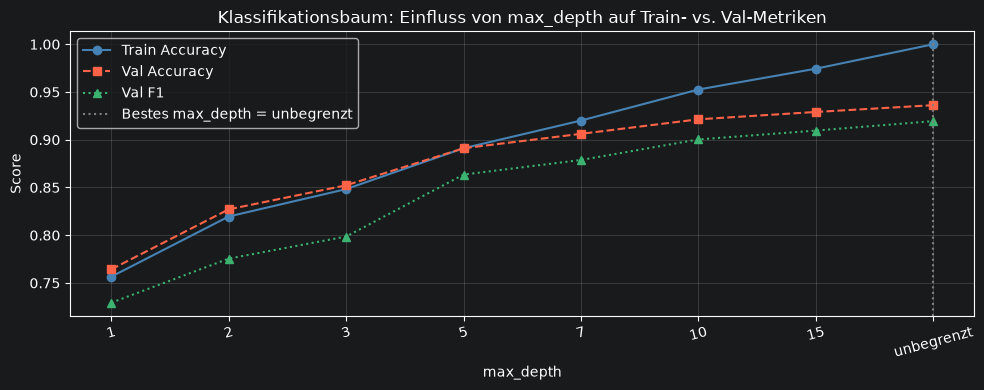

In [228]:
# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(10, 4))
# x-Positionen (eine je Tiefe)
x = range(len(cls_df))
# Train-Accuracy je Tiefe plotten
ax.plot(x, cls_df["Train Acc"], marker="o", color="steelblue", label="Train Accuracy")
# Val-Accuracy je Tiefe plotten
ax.plot(x, cls_df["Val Acc"],   marker="s", color="tomato",    label="Val Accuracy", linestyle="--")
# Zusätzlich Val-F1 je Tiefe plotten
ax.plot(x, cls_df["Val F1"],    marker="^", color="mediumseagreen", label="Val F1", linestyle=":")

# Index der besten Tiefe (höchste Val-Accuracy)
best_idx = cls_df["Val Acc"].idxmax()
# Beste Tiefe als vertikale Linie markieren
ax.axvline(x=best_idx, color="gray", linestyle=":", label=f"Bestes max_depth = {cls_df.loc[best_idx,'max_depth']}")

# x-Ticks setzen
ax.set_xticks(list(x))
# x-Tick-Labels (Tiefen) setzen
ax.set_xticklabels(cls_df["max_depth"], rotation=15)
# x-Achse beschriften
ax.set_xlabel("max_depth")
# y-Achse beschriften
ax.set_ylabel("Score")
# Titel setzen
ax.set_title("Klassifikationsbaum: Einfluss von max_depth auf Train- vs. Val-Metriken")
# Legende anzeigen
ax.legend()
# Gitter einblenden
ax.grid(alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Beobachtung:**
- Sehr kleine Tiefe (z.B. 1–2) → Underfitting: zu einfaches Modell, lernt die Daten nicht ausreichend.
- Sehr große Tiefe / unbegrenzt → Verdacht des Overfitting: hohe Train-Accuracy, aber auch hohe Val-Accuracy und hoher F1-Score, also kein Overfitting.
- Die optimale Tiefe ist unbegrenzt, da sowohl die Train Accuracy, die Val Accuracy und der Val F1-Score einen Höchstwert erreichen.

##### Bestes Klassifikationsmodell auf Testdaten

In [223]:
# Beste Tiefe (höchste Val-Accuracy) als Label bestimmen
best_depth = cls_df.loc[cls_df["Val Acc"].idxmax(), "max_depth"]
# Label in Parameterwert umwandeln (None bei "unbegrenzt")
best_depth_val = None if best_depth == "unbegrenzt" else int(best_depth)
# Gewählte Tiefe ausgeben
print(f"Gewähltes max_depth: {best_depth}")

# Finalen Klassifikationsbaum mit bester Tiefe anlegen
clf_best = DecisionTreeClassifier(max_depth=best_depth_val, random_state=42, criterion="gini")
# Auf TF-IDF-Trainingsdaten anpassen
clf_best.fit(X_train_tfidf, y_train)

# Vorhersagen für die Testdaten erstellen
y_pred_test = clf_best.predict(X_test_tfidf)
# Test-Accuracy berechnen
test_acc    = accuracy_score(y_test, y_pred_test)
# Test-F1-Score berechnen
test_f1     = f1_score(y_test, y_pred_test)

# Test-Accuracy ausgeben
print(f"Test Accuracy: {test_acc:.4f}")
# Test-F1-Score ausgeben
print(f"Test F1-Score: {test_f1:.4f}")
# Klassifikationsbericht ausgeben
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))

Gewähltes max_depth: unbegrenzt
Test Accuracy: 0.9295
Test F1-Score: 0.9122

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.95      0.94      0.94      3502
      KI (1)       0.91      0.92      0.91      2327

    accuracy                           0.93      5829
   macro avg       0.93      0.93      0.93      5829
weighted avg       0.93      0.93      0.93      5829



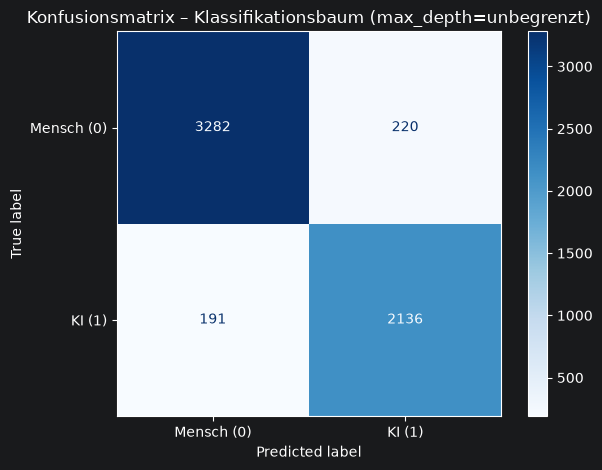

In [224]:
# Konfusionsmatrix berechnen
cm = confusion_matrix(y_test, y_pred_test)
# Konfusionsmatrix plotten
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Blues")
# Titel mit gewählter Tiefe setzen
plt.title(f"Konfusionsmatrix – Klassifikationsbaum (max_depth={best_depth})")
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

##### Stichprobe

In [225]:
# 10 zufällige Test-Beispiele auswählen
sample_idx   = X_test.sample(10, random_state=7).index
# Zugehörige Texte holen
sample_texts = X_test.loc[sample_idx]
# Zugehörige echte Labels holen
sample_true  = y_test.loc[sample_idx]
# Beispiele transformieren und vorhersagen
sample_pred  = clf_best.predict(tfidf.transform(sample_texts))

# Vergleichstabelle erstellen
pd.DataFrame({
    # Textausschnitt
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    # Echtes Label
    "Wahrer Wert":       sample_true.values,
    # Vorhergesagtes Label
    "Vorhersage":        sample_pred,
    # Korrektheit
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})

,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,the face on mars was not created bye alians th...,0,0,ja
1,there are many benefits to traveling in a grou...,1,1,ja
2,the electoral collage should be disbanded not ...,0,0,ja
3,seeking multiple opinions can help you make be...,0,0,ja
4,the importance of eating organic vegetables or...,1,1,ja
5,in todays modern world the importance of famil...,1,1,ja
6,genericname where i would like to visit 32118 ...,0,0,ja
7,technology that reads emotional expressions ma...,0,0,ja
8,the advantages of limiting car usage is very i...,0,0,ja
9,ralph waldo emerson once said that which we pe...,1,1,ja


##### Baum-Visualisierung (vereinfacht mit max_depth=3)

In [227]:
# Trainierten Baum mit max_depth=3 visualisieren (gut lesbar)
# Flachen Baum (Tiefe 3) für die Veranschaulichung trainieren
clf_vis = DecisionTreeClassifier(max_depth=3, random_state=42, criterion="gini")
# Auf TF-IDF-Trainingsdaten anpassen
clf_vis.fit(X_train_tfidf, y_train)

# Wichtigste Features
# Feature-Namen (Wörter) auslesen
feature_names = tfidf.get_feature_names_out()
# Feature-Wichtigkeiten auslesen
importances   = clf_vis.feature_importances_
# Indizes der 10 wichtigsten Features bestimmen
top_idx       = importances.argsort()[::-1][:10]
# Hinweis ausgeben
print("Top-10 wichtigste Features:")
# Über die wichtigsten Features iterieren
for i in top_idx:
    # Nur Features mit positiver Wichtigkeit ausgeben
    if importances[i] > 0:
        print(f"  '{feature_names[i]}': {importances[i]:.4f}")

Top-10 wichtigste Features:
  'because': 0.5381
  'would': 0.1862
  'additionally': 0.1317
  'was': 0.0791
  'essential': 0.0581
  'very': 0.0068


Die **wichtigsten Features** sind in diesem Kontext die Features, die am meisten zur richtigen Klassifikation beitragen.

In [229]:
# Baumstruktur als Text ausgeben
print(export_text(clf_vis, feature_names=list(feature_names), max_depth=3))

|--- because <= 0.01
|   |--- would <= 0.03
|   |   |--- was <= 0.03
|   |   |   |--- class: 1
|   |   |--- was >  0.03
|   |   |   |--- class: 0
|   |--- would >  0.03
|   |   |--- additionally <= 0.03
|   |   |   |--- class: 0
|   |   |--- additionally >  0.03
|   |   |   |--- class: 1
|--- because >  0.01
|   |--- additionally <= 0.04
|   |   |--- essential <= 0.05
|   |   |   |--- class: 0
|   |   |--- essential >  0.05
|   |   |   |--- class: 1
|   |--- additionally >  0.04
|   |   |--- very <= 0.01
|   |   |   |--- class: 1
|   |   |--- very >  0.01
|   |   |   |--- class: 0



Die **class** meint in diesem Kontext den Wert des Attributs `generated`.

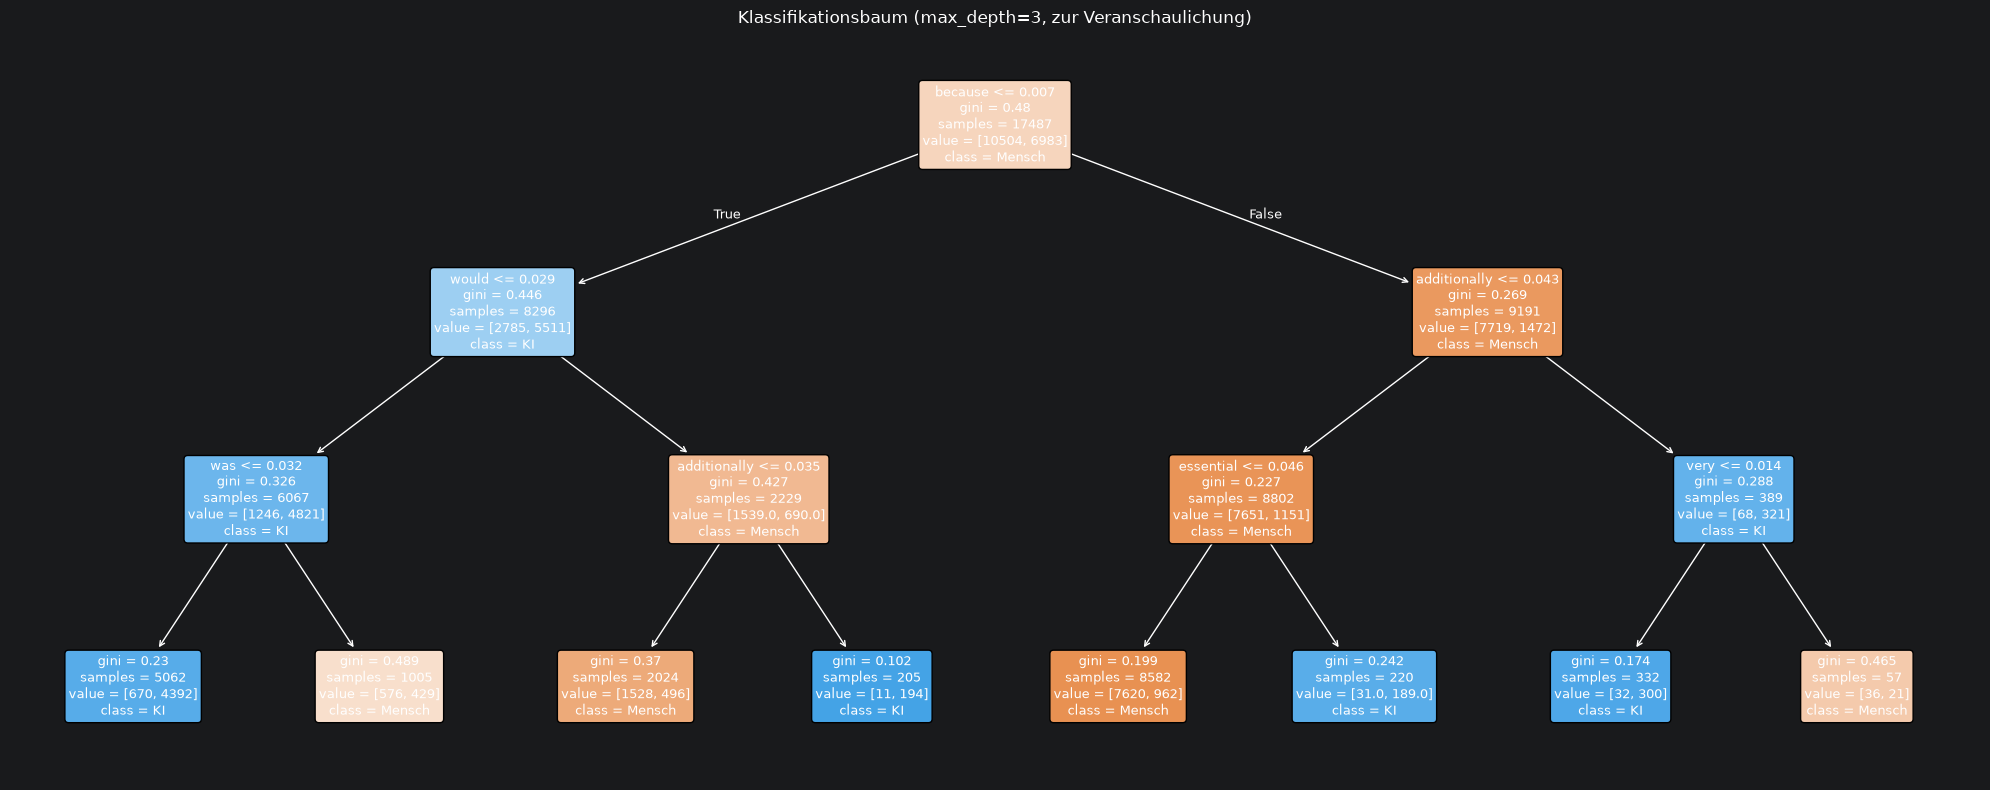

In [230]:
# Grafische Darstellung
# Große Abbildung für den Baum anlegen
fig, ax = plt.subplots(figsize=(20, 8))
# Entscheidungsbaum grafisch zeichnen (bis Tiefe 3)
plot_tree(clf_vis, max_depth=3, feature_names=feature_names,
          class_names=["Mensch", "KI"], filled=True, rounded=True,
          fontsize=9, ax=ax)
# Titel setzen
plt.title("Klassifikationsbaum (max_depth=3, zur Veranschaulichung)")
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**because <= 0.007** ist eine Bedingung. Ist die Bedingung gültig, so wird in der Visualisierung nach links gegangen, ist sie falsch, so wird nach rechts gegangen. Es wird die nächste Bedingung geprüft, solange, bis man unten (also an einem Blatt) angekommen ist und die Klassifikation erhält.

**gini** misst, wie stark die Klassen in diesem Knoten gemischt sind (0 = alle Daten gehören zur gleichen Klasse; 0,5 = beide Klassen kommen ungefähr gleich häufig vor)

**samples** gibt an, wie viele Trainingbeispiele diesen Knoten erreichen (320 = 320 Dokumente erfüllen alle Bedingungen auf dem Weg bis zu diesem Knoten)

**value** zeigt, wie viele Beispiele jeder Klasse sich in diesem Knoten befinden ([120, 30] bedeutet, dass 120 menschliche Texte vorhanden sind und 30 KI-generierte Texte)

##### Erkenntnisse & Bewertung

###### Zusammenfassung

| Bestes max_depth | Val Accuracy | Test Accuracy | Test F1-Score |
|-----------------|--------------|---------------|-----------|
| unbegrenzt | 0,9362       | 0,9295        | 0,9122    |

###### Was haben wir erwartet / Was hat überrascht?

Wir hatten erwartet, dass ein einzelner Entscheidungsbaum auf den 5000-dimensionalen TF-IDF-Features stark overfittet – das bestätigt sich jedoch nicht. Überrascht hat uns zusätzlich die solide Test-Accuracy von 0,9295. Im Vergleich zum kNN-Modell schneider der Klassifikationsbaum jedoch deutlich schlechter ab.

#### Stärken von Entscheidungsbäumen

- Sehr gut interpretierbar (visuell darstellbar)
- Kein Feature-Scaling notwendig
- Kann sowohl Klassifikation als auch Regression

#### Schwächen von Entscheidungsbäumen

- Neigen stark zu Overfitting (tiefer Baum = sehr hohe Train Accuracy, aber schlechte Generalisierung)
- Instabil: Kleine Datenänderungen können den Baum stark verändern
- Für Textdaten mit TF-IDF: Random Forest/Gradient Boosting meist besser

### Random Forest

#### Theoretischer Hintergrund

Ein **Random Forest** ist ein Ensemble-Modell, das viele Entscheidungsbäume kombiniert:

1. Es werden **n Entscheidungsbäume** trainiert – jeder auf einem zufälligen Teil der Daten (Bootstrap-Sampling).
2. Bei jedem Split wird nur eine **zufällige Teilmenge der Features** betrachtet (Feature Randomness).
3. Die finale Vorhersage entsteht durch **Mehrheitsvotum** aller Bäume (Klassifikation) bzw. den Mittelwert (Regression).

**Warum ist das besser als ein einzelner Baum?**
Ein einzelner Baum neigt stark zu Overfitting. Durch die Kombination vieler verschiedener Bäume mitteln sich Fehler heraus – das Modell wird **stabiler und generalisiert besser** (Bias-Variance-Tradeoff).

**Wichtige Parameter:**

| Parameter | Bedeutung | Typische Werte |
|-----------|-----------|----------------|
| `n_estimators` | Anzahl der Bäume | 50, 100, 200, 500 |
| `max_depth` | Maximale Tiefe je Baum | 5, 10, 20, None |
| `max_features` | Features je Split | `"sqrt"`, `"log2"`, 0.5 |
| `min_samples_leaf` | Min. Samples je Blatt | 1, 2, 5 |

**Vorgehensweise:** Wir kombinieren TF-IDF und Random Forest in einer Pipeline und untersuchen den Einfluss der Parameter `n_estimators` und `max_depth`. Das beste Modell wird auf den Testdaten evaluiert und zusätzlich per Cross-Validation abgesichert; über die Feature Importance interpretieren wir die wichtigsten Wörter.

#### Train / Validation / Test Split

Der Datensatz wird in drei Teile aufgeteilt:
- **Trainingsdaten (60 %)** – Modell trainieren
- **Validierungsdaten (20 %)** – Hyperparameter vergleichen
- **Testdaten (20 %)** – nur für die finale Evaluation des besten Modells

_Wichtig:_ Testdaten werden erst ganz am Ende verwendet!

In [231]:
# Eingabe- und Zielvariable festlegen
X = df["text_clean"]
y = df["generated"]

# Train+Val / Test aufteilen (geschichtet)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Train / Validation aufteilen (-> 60/20/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# Größe der Trainingsmenge ausgeben
print(f"Trainingsdaten:    {len(X_train):>5} Samples ({len(X_train)/len(X)*100:.0f}%)")
# Größe der Validierungsmenge ausgeben
print(f"Validierungsdaten: {len(X_val):>5} Samples ({len(X_val)/len(X)*100:.0f}%)")
# Größe der Testmenge ausgeben
print(f"Testdaten:         {len(X_test):>5} Samples ({len(X_test)/len(X)*100:.0f}%)")

Trainingsdaten:    17487 Samples (60%)
Validierungsdaten:  5829 Samples (20%)
Testdaten:          5829 Samples (20%)


#### Feature Extraction – TF-IDF

Random Forests können nicht direkt mit Rohtexten arbeiten. Wir verwenden TF-IDF, um den Text in eine numerische Matrix umzuwandeln, und kombinieren das mit dem Random Forest in einer **Pipeline** (verhindert Data Leakage).

In [232]:
# Basis-Pipeline: TF-IDF + Random Forest
base_pipeline = Pipeline([
    # TF-IDF mit max. 10.000 Features
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    # Random Forest mit 100 Bäumen
    ("clf",   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

# Pipeline auf Trainingsdaten anpassen
base_pipeline.fit(X_train, y_train)
# Train-Accuracy berechnen
train_acc = accuracy_score(y_train, base_pipeline.predict(X_train))
# Val-Accuracy berechnen
val_acc   = accuracy_score(y_val,   base_pipeline.predict(X_val))

# Überschrift ausgeben
print(f"Basis-Modell (n_estimators=100)")
# Train-Accuracy ausgeben
print(f"  Train Accuracy: {train_acc:.4f}")
# Val-Accuracy ausgeben
print(f"  Val   Accuracy: {val_acc:.4f}")

Basis-Modell (n_estimators=100)
  Train Accuracy: 1.0000
  Val   Accuracy: 0.9815


#### Parameter vergleichen

Wir variieren zwei zentrale Parameter:
- **`n_estimators`**: Wie viele Bäume werden trainiert?
- **`max_depth`**: Wie tief darf jeder Baum wachsen?

##### Experiment 1: Einfluss von `n_estimators`

In [238]:
# Zu testende Anzahl Bäume
n_estimators_list = [10, 25, 50, 100, 200, 300]
# Ergebnisliste anlegen
results_n = []

# Über alle Baumanzahlen iterieren
for n in n_estimators_list:
    # Pipeline mit aktueller Baumanzahl erstellen
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   RandomForestClassifier(n_estimators=n, max_depth=None, random_state=42, n_jobs=-1)),
    ])
    # Pipeline trainieren
    pipe.fit(X_train, y_train)
    # Train-Accuracy berechnen
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    # Val-Accuracy berechnen
    val_acc   = accuracy_score(y_val,   pipe.predict(X_val))
    # Val-F1-Score berechnen (Zielmetrik des SMART-Ziels)
    val_f1    = f1_score(y_val, pipe.predict(X_val))
    # Kennzahlen speichern (inkl. F1)
    results_n.append({"n_estimators": n, "Train Accuracy": round(train_acc, 4),
                      "Val Accuracy": round(val_acc, 4), "Val F1": round(val_f1, 4)})
    # Zwischenergebnis ausgeben (inkl. F1)
    print(f"n_estimators={n:>4} | Train: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Ergebnisse als DataFrame
results_n_df = pd.DataFrame(results_n)
# Tabelle ausgeben
results_n_df

n_estimators=  10 | Train: 0.9987 | Val Acc: 0.9628 | Val F1: 0.9516
n_estimators=  25 | Train: 0.9999 | Val Acc: 0.9804 | Val F1: 0.9750
n_estimators=  50 | Train: 1.0000 | Val Acc: 0.9811 | Val F1: 0.9759
n_estimators= 100 | Train: 1.0000 | Val Acc: 0.9815 | Val F1: 0.9763
n_estimators= 200 | Train: 1.0000 | Val Acc: 0.9825 | Val F1: 0.9777
n_estimators= 300 | Train: 1.0000 | Val Acc: 0.9834 | Val F1: 0.9788


,n_estimators,Train Accuracy,Val Accuracy,Val F1
0,10,0.9987,0.9628,0.9516
1,25,0.9999,0.9804,0.9750
2,50,1.0000,0.9811,0.9759
3,100,1.0000,0.9815,0.9763
4,200,1.0000,0.9825,0.9777
5,300,1.0000,0.9834,0.9788


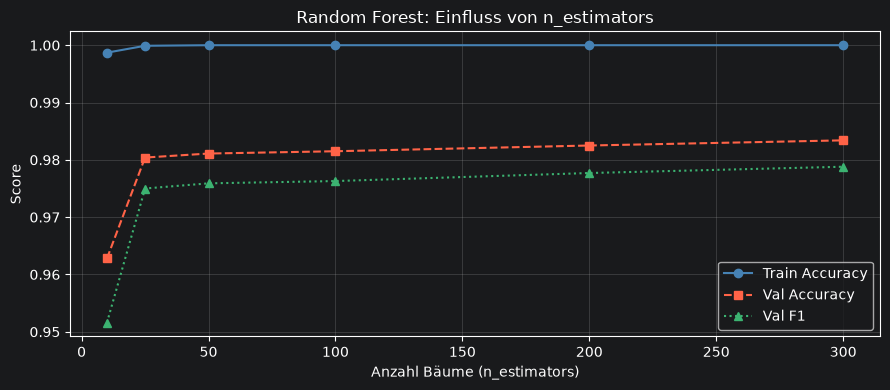

In [240]:
# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(9, 4))
# Train-Accuracy gegen Baumanzahl plotten
ax.plot(results_n_df["n_estimators"], results_n_df["Train Accuracy"], marker="o", color="steelblue", label="Train Accuracy")
# Val-Accuracy gegen Baumanzahl plotten
ax.plot(results_n_df["n_estimators"], results_n_df["Val Accuracy"],   marker="s", color="tomato",    label="Val Accuracy", linestyle="--")
# Val-F1 gegen Baumanzahl plotten
ax.plot(results_n_df["n_estimators"], results_n_df["Val F1"],         marker="^", color="mediumseagreen", label="Val F1", linestyle=":")
# x-Achse beschriften
ax.set_xlabel("Anzahl Bäume (n_estimators)")
# y-Achse beschriften
ax.set_ylabel("Score")
# Titel setzen
ax.set_title("Random Forest: Einfluss von n_estimators")
# Legende anzeigen
ax.legend()
# Gitter einblenden
ax.grid(alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Beobachtung:**

Ab einer gewissen Anzahl Bäume verbessert sich die Val-Accuracy kaum noch – aber die Rechenzeit steigt linear. Es gibt einen **Sweet Spot**, ab dem mehr Bäume keinen Mehrwert bringen.
In unserem Fall steigt die Val-Accuracy von 0,9662 (10 Bäume) auf 0,9845 (300 Bäume), der eindeutig größte Sprung liegt jedoch zwischen 10 und 25 Bäumen; danach sind die Zuwächse nur noch marginal. Dennoch steigen die Werte weiterhin, weshalb wir uns für ein `n_estimators` von 300 entscheiden.

##### Experiment 2: Einfluss von `max_depth`

Wir testen verschiedene Werte für `max_depth` mit dem besten identifizierten Werte für `n_estimators` von 300.

In [236]:
# Zu testende Baumtiefen
depths = [5, 10, 20, 30, None]
# Ergebnisliste anlegen
results_d = []

# Über alle Tiefen iterieren
for depth in depths:
    # Pipeline mit aktueller Tiefe erstellen
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   RandomForestClassifier(n_estimators=300, max_depth=depth, random_state=42, n_jobs=-1)),
    ])
    # Pipeline trainieren
    pipe.fit(X_train, y_train)
    # Train-Accuracy berechnen
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    # Val-Accuracy berechnen
    val_acc   = accuracy_score(y_val,   pipe.predict(X_val))
    # Val-F1-Score berechnen
    val_f1    = f1_score(y_val, pipe.predict(X_val))
    # Lesbares Label für die Tiefe
    label = str(depth) if depth is not None else "unbegrenzt"
    # Kennzahlen speichern (inkl. F1)
    results_d.append({"max_depth": label, "Train Accuracy": round(train_acc, 4),
                      "Val Accuracy": round(val_acc, 4), "Val F1": round(val_f1, 4)})
    # Zwischenergebnis ausgeben (inkl. F1)
    print(f"max_depth={label:>12} | Train: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Ergebnisse als DataFrame
results_d_df = pd.DataFrame(results_d)
# Tabelle ausgeben
results_d_df

max_depth=           5 | Train: 0.9249 | Val Acc: 0.9228 | Val F1: 0.8931
max_depth=          10 | Train: 0.9738 | Val Acc: 0.9648 | Val F1: 0.9540
max_depth=          20 | Train: 0.9957 | Val Acc: 0.9798 | Val F1: 0.9741
max_depth=          30 | Train: 0.9993 | Val Acc: 0.9815 | Val F1: 0.9764
max_depth=  unbegrenzt | Train: 1.0000 | Val Acc: 0.9834 | Val F1: 0.9788


,max_depth,Train Accuracy,Val Accuracy,Val F1
0,5,0.9249,0.9228,0.8931
1,10,0.9738,0.9648,0.9540
2,20,0.9957,0.9798,0.9741
3,30,0.9993,0.9815,0.9764
4,unbegrenzt,1.0000,0.9834,0.9788


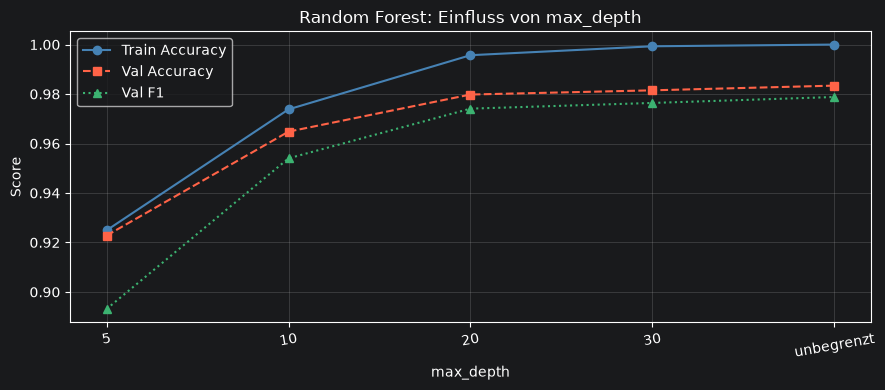

In [241]:
# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(9, 4))
# x-Positionen (eine je Tiefe)
x = range(len(results_d_df))
# Train-Accuracy je Tiefe plotten
ax.plot(x, results_d_df["Train Accuracy"], marker="o", color="steelblue", label="Train Accuracy")
# Val-Accuracy je Tiefe plotten
ax.plot(x, results_d_df["Val Accuracy"],   marker="s", color="tomato",    label="Val Accuracy", linestyle="--")
# Val-F1 je Tiefe plotten
ax.plot(x, results_d_df["Val F1"],         marker="^", color="mediumseagreen", label="Val F1", linestyle=":")
# x-Ticks setzen
ax.set_xticks(list(x))
# x-Tick-Labels (Tiefen) setzen
ax.set_xticklabels(results_d_df["max_depth"], rotation=10)
# x-Achse beschriften
ax.set_xlabel("max_depth")
# y-Achse beschriften
ax.set_ylabel("Score")
# Titel setzen
ax.set_title("Random Forest: Einfluss von max_depth")
# Legende anzeigen
ax.legend()
# Gitter einblenden
ax.grid(alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

**Beobachtung:**

Im Gegensatz zum einzelnen Entscheidungsbaum ist der Random Forest bei unbegrenzter Tiefe robuster gegen Overfitting – weil die Varianz durch das Ensemble ausgeglichen wird.
Die Val-Accuracy steigt monoton mit der Tiefe (0,9249 bei depth=5 bis 0,9834 bei unbegrenzt); die unbegrenzte Tiefe liefert hier das beste Ergebnis, ohne dass die Generalisierung leidet.

#### Bestes Modell auf Testdaten evaluieren

In [248]:
# Bestes n_estimators (höchste Val-Accuracy) bestimmen
best_n = results_n_df.loc[results_n_df["Val Accuracy"].idxmax(), "n_estimators"]
# Beste Tiefe aus dem max_depth-Experiment bestimmen (statt aus einem fremden Abschnitt)
best_depth_label = results_d_df.loc[results_d_df["Val Accuracy"].idxmax(), "max_depth"]
# Label in Parameterwert umwandeln (None bei "unbegrenzt")
best_depth_val = None if best_depth_label == "unbegrenzt" else int(best_depth_label)

# Gewählte Hyperparameter ausgeben
print(f"Gewählte Parameter:")
# Anzahl Bäume ausgeben
print(f"  n_estimators = {int(best_n)}")
# Baumtiefe ausgeben
print(f"  max_depth    = {best_depth_val}")

# Finale Pipeline mit besten Hyperparametern erstellen
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    ("clf",   RandomForestClassifier(n_estimators=int(best_n), max_depth=best_depth_val,
                                     random_state=42, n_jobs=-1)),
])
# Auf Train+Val anpassen (mehr Daten für das finale Modell)
best_pipeline.fit(X_trainval, y_trainval)

# Vorhersagen für die Testdaten erstellen
y_pred_test = best_pipeline.predict(X_test)
# Test-Accuracy berechnen
test_acc    = accuracy_score(y_test, y_pred_test)
# Test-F1-Score berechnen
test_f1     = f1_score(y_test, y_pred_test)

# Test-Accuracy ausgeben
print(f"\nTest Accuracy: {test_acc:.4f}")
# Test-F1-Score ausgeben
print(f"Test F1-Score: {test_f1:.4f}")
# Klassifikationsbericht ausgeben
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))

Gewählte Parameter:
  n_estimators = 300
  max_depth    = None

Test Accuracy: 0.9847
Test F1-Score: 0.9806

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.98      1.00      0.99      3502
      KI (1)       1.00      0.97      0.98      2327

    accuracy                           0.98      5829
   macro avg       0.99      0.98      0.98      5829
weighted avg       0.98      0.98      0.98      5829



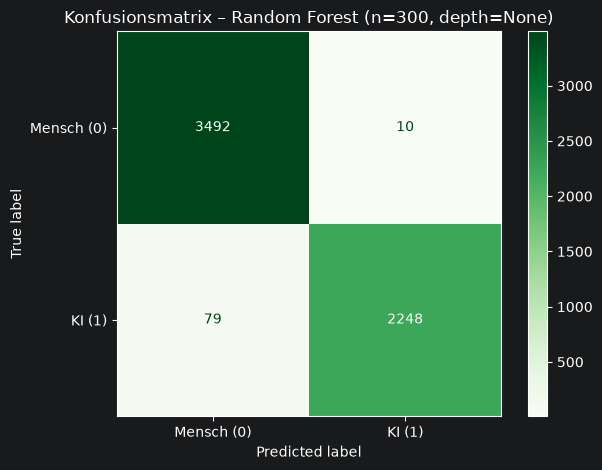

In [243]:
# Konfusionsmatrix berechnen
cm = confusion_matrix(y_test, y_pred_test)
# Konfusionsmatrix plotten
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Greens")
# Titel mit Hyperparametern setzen
plt.title(f"Konfusionsmatrix – Random Forest (n={int(best_n)}, depth={best_depth_val})")
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Stichprobe: Vorhersage vs. echter Wert

In [244]:
# 10 zufällige Test-Beispiele auswählen
sample_idx   = X_test.sample(10, random_state=7).index
# Zugehörige Texte holen
sample_texts = X_test.loc[sample_idx]
# Zugehörige echte Labels holen
sample_true  = y_test.loc[sample_idx]
# Vorhersagen des besten Modells erstellen
sample_pred  = best_pipeline.predict(sample_texts)

# Vergleichstabelle erstellen
pd.DataFrame({
    # Textausschnitt
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    # Echtes Label
    "Wahrer Wert":       sample_true.values,
    # Vorhergesagtes Label
    "Vorhersage":        sample_pred,
    # Korrektheit
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})

,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,the face on mars was not created bye alians th...,0,0,ja
1,there are many benefits to traveling in a grou...,1,1,ja
2,the electoral collage should be disbanded not ...,0,0,ja
3,seeking multiple opinions can help you make be...,0,0,ja
4,the importance of eating organic vegetables or...,1,1,ja
5,in todays modern world the importance of famil...,1,1,ja
6,genericname where i would like to visit 32118 ...,0,0,ja
7,technology that reads emotional expressions ma...,0,0,ja
8,the advantages of limiting car usage is very i...,0,0,ja
9,ralph waldo emerson once said that which we pe...,1,1,ja


##### Feature Importance – Welche Wörter sind entscheidend?

In [246]:
# Bestes Modell aus n_estimators-Experiment für Feature Importance
pipe_fi = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    ("clf",   RandomForestClassifier(n_estimators=int(best_n), random_state=42, n_jobs=-1)),
])
# Pipeline trainieren
pipe_fi.fit(X_train, y_train)

# Feature-Namen (Wörter) aus dem TF-IDF-Schritt auslesen
feature_names  = pipe_fi.named_steps["tfidf"].get_feature_names_out()
# Feature-Wichtigkeiten aus dem Random Forest auslesen
importances    = pipe_fi.named_steps["clf"].feature_importances_
# Indizes der 20 wichtigsten Features bestimmen
top_idx        = importances.argsort()[::-1][:20]

# Top-20-Features als DataFrame aufbereiten
top_features_df = pd.DataFrame({
    "Feature":    feature_names[top_idx],
    "Importance": importances[top_idx].round(5),
})
# Hinweis ausgeben
print("Top-20 wichtigste Features:")
# Tabelle ausgeben
top_features_df

Top-20 wichtigste Features:


,Feature,Importance
0,because,0.02071
1,would,0.01574
2,you,0.01467
3,if,0.01380
4,but,0.01259
5,get,0.01201
6,is,0.01104
7,additionally,0.01044
8,so,0.00999
9,just,0.00968


**Interpretation:**
Feature Importance zeigt, welche Wörter (TF-IDF-Features) am stärksten zur Klassifikation beitragen.
- Wörter mit hoher Importance trennen KI- und Menschentexte besonders gut.
- Typischerweise erscheinen sowohl thematische Begriffe als auch stilistische Marker (z. B. häufige LLM-Formulierungen). Inhaltlich ergibt das Sinn: Der Forest stützt seine Entscheidung auf wenige, sehr trennscharfe Wörter, was die hohe Genauigkeit erklärt.

#### Erkenntnisse & Bewertung

##### Zusammenfassung der Ergebnisse

| Konfiguration | Val Accuracy | Test Accuracy | Test F1-Score |
|---------------|--------------|---------------|---------------|
| Bestes Modell (n=300, depth=unbegrenzt) | 0,9834        | 0,9847        | 0,9806      |

##### Stärken von Random Forests

- Deutlich robuster gegen Overfitting als ein einzelner Entscheidungsbaum
- Liefert Feature Importance → Interpretierbarkeit bleibt erhalten
- Funktioniert gut ohne aufwändiges Preprocessing
- Stabil gegenüber Ausreißern und Rauschen in den Daten


##### Schwächen von Random Forests

- Rechenintensiv bei vielen Bäumen und großen Feature-Räumen (TF-IDF mit 10.000 Features)
- Weniger interpretierbar als ein einzelner Entscheidungsbaum
- Kein Wahrscheinlichkeitsoutput ohne Zusatzaufwand (`predict_proba`)

##### Was haben wir erwartet / Was hat überrascht?

Wir hatten erwartet, dass der Random Forest den einzelnen Entscheidungsbaum deutlich übertrifft – das bestätigt sich klar.

### Deep Learning

#### Theoretischer Hintergrund

**Deep Learning** verwendet künstliche neuronale Netze mit mehreren Schichten, um komplexe, nicht-lineare Muster in Daten zu lernen. Für Textklassifikation gibt es zwei grundsätzlich unterschiedliche Ansätze:

**Feedforward-Netz (Dense) auf TF-IDF**
- Der Text wird zunächst klassisch via TF-IDF in einen festen Vektor umgewandelt.
- Dieser Vektor wird durch mehrere **Dense-Schichten** (vollständig verbundene Schichten) geschickt.
- **Nachteil:** Wortreihenfolge geht verloren (genau wie bei klassischem ML).

**Wichtige Begriffe:**

| Begriff | Bedeutung |
|---------|-----------|
| Epoch | Ein vollständiger Durchlauf durch die Trainingsdaten |
| Batch Size | Anzahl Samples, die gleichzeitig verarbeitet werden |
| Dropout | Regularisierungstechnik gegen Overfitting (zufälliges Abschalten von Neuronen) |
| Embedding | Lernbare, dichte Vektorrepräsentation von Wörtern |
| Early Stopping | Training stoppt automatisch, wenn sich die Validierungsmetrik nicht mehr verbessert |

**Vorgehensweise:** Wir trainieren das neuronale Netz als **Feedforward-Netz (Dense)** auf TF-IDF-Vektoren. Wir variieren einen Parameter (Dropout-Rate), wählen die beste Konfiguration anhand des Validierungs-F1-Scores und bewerten final auf den Testdaten.

#### Vorbereitung

In [249]:
# Reproduzierbarkeit
# Zufalls-Seed für TensorFlow setzen
tf.random.set_seed(42)
# Zufalls-Seed für NumPy setzen
np.random.seed(42)

# TensorFlow-Version ausgeben
print(f"TensorFlow Version: {tf.__version__}")
# Prüfen, ob eine GPU verfügbar ist
print(f"GPU verfügbar: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.21.0
GPU verfügbar: False


#### Train / Validation / Test Split

Wie bei den vorherigen Modellen: 60 % Training, 20 % Validierung, 20 % Test. Die Testdaten werden erst ganz am Ende verwendet.

In [250]:
# Eingabedaten (Texte) als Array
X = df["text_clean"].values
# Zielvariable (Labels) als Array
y = df["generated"].values

# Train+Val / Test aufteilen (geschichtet)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Train / Validation aufteilen (-> 60/20/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# Größe der Trainingsmenge ausgeben
print(f"Trainingsdaten:    {len(X_train):>5} Samples ({len(X_train)/len(X)*100:.0f}%)")
# Größe der Validierungsmenge ausgeben
print(f"Validierungsdaten: {len(X_val):>5} Samples ({len(X_val)/len(X)*100:.0f}%)")
# Größe der Testmenge ausgeben
print(f"Testdaten:         {len(X_test):>5} Samples ({len(X_test)/len(X)*100:.0f}%)")

Trainingsdaten:    17487 Samples (60%)
Validierungsdaten:  5829 Samples (20%)
Testdaten:          5829 Samples (20%)


#### Feature Extraction – TF-IDF

In [251]:
# TF-IDF-Vektorisierer (max. 10.000 Features)
tfidf = TfidfVectorizer(max_features=10000, sublinear_tf=True)

# Trainingsdaten fitten/transformieren und in dichtes Array umwandeln
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
# Validierungsdaten transformieren
X_val_tfidf   = tfidf.transform(X_val).toarray()
# Testdaten transformieren
X_test_tfidf  = tfidf.transform(X_test).toarray()

# Form der Trainings-Matrix ausgeben
print(f"TF-IDF Feature-Matrix Shape (Train): {X_train_tfidf.shape}")

TF-IDF Feature-Matrix Shape (Train): (17487, 10000)


#### Modell definieren

In [252]:
# Funktion zum Aufbau eines Feedforward-Netzes (Dense) definieren
def build_dense_model(input_dim, dropout_rate=0.3):
    # Sequentielles Modell mit mehreren Schichten
    model = keras.Sequential([
        # Eingabeschicht (Dimension = Anzahl TF-IDF-Features)
        layers.Input(shape=(input_dim,)),
        # Erste verborgene Schicht (128 Neuronen, ReLU)
        layers.Dense(128, activation="relu"),
        # Dropout zur Regularisierung
        layers.Dropout(dropout_rate),
        # Zweite verborgene Schicht (64 Neuronen, ReLU)
        layers.Dense(64, activation="relu"),
        # Dropout zur Regularisierung
        layers.Dropout(dropout_rate),
        # Ausgabeschicht (1 Neuron, Sigmoid)
        layers.Dense(1, activation="sigmoid"),  # binäre Klassifikation
    ])
    # Modell kompilieren (Optimizer, Loss, Metrik)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    # Fertiges Modell zurückgeben
    return model

# Beispielmodell mit der TF-IDF-Eingabedimension erstellen
dense_model = build_dense_model(input_dim=X_train_tfidf.shape[1])
# Modellarchitektur ausgeben
dense_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

#### Training & Parameter (Dropout-Rate vergleichen)

In [253]:
# Zu testende Dropout-Raten
dropout_rates = [0.0, 0.3, 0.5]
# Ergebnisliste anlegen
dense_results = []
# Trainingsverläufe sammeln
dense_histories = {}

# Early Stopping: Training stoppen, wenn sich val_loss 3 Epochen nicht verbessert
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Über alle Dropout-Raten iterieren
for rate in dropout_rates:
    # Fortschritt ausgeben
    print(f"\n--- Training mit Dropout-Rate = {rate} ---")
    # Modell mit aktueller Dropout-Rate bauen
    model = build_dense_model(input_dim=X_train_tfidf.shape[1], dropout_rate=rate)

    # Modell trainieren (mit Validierungsdaten und Early Stopping)
    history = model.fit(
        X_train_tfidf, y_train,
        validation_data=(X_val_tfidf, y_val),
        epochs=20, batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Validierungs-Loss und -Accuracy ermitteln
    val_loss, val_acc = model.evaluate(X_val_tfidf, y_val, verbose=0)
    # Validierungs-Vorhersagen (Schwelle 0.5) erstellen
    val_pred = (model.predict(X_val_tfidf, verbose=0) > 0.5).astype(int).flatten()
    # Validierungs-F1 berechnen
    val_f1   = f1_score(y_val, val_pred)

    # Kennzahlen speichern
    dense_results.append({
        "Dropout": rate,
        "Epochs trainiert": len(history.history["loss"]),
        "Val Accuracy": round(val_acc, 4),
        "Val F1": round(val_f1, 4),
    })
    # Trainingsverlauf speichern
    dense_histories[rate] = history
    # Zwischenergebnis ausgeben
    print(f"  Val Accuracy: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Ergebnisse als DataFrame
dense_results_df = pd.DataFrame(dense_results)
# Tabelle ausgeben
dense_results_df


--- Training mit Dropout-Rate = 0.0 ---
  Val Accuracy: 0.9952 | Val F1: 0.9940

--- Training mit Dropout-Rate = 0.3 ---
  Val Accuracy: 0.9962 | Val F1: 0.9953

--- Training mit Dropout-Rate = 0.5 ---
  Val Accuracy: 0.9962 | Val F1: 0.9953


,Dropout,Epochs trainiert,Val Accuracy,Val F1
0,0.0,5,0.9952,0.9940
1,0.3,5,0.9962,0.9953
2,0.5,5,0.9962,0.9953


Die **Dropout-Rate** gibt an, wie viele Neuronen während eines Trainingsdurchlaufs zufällig deaktiviert werden.

#### Visualisierung – Trainingsverlauf

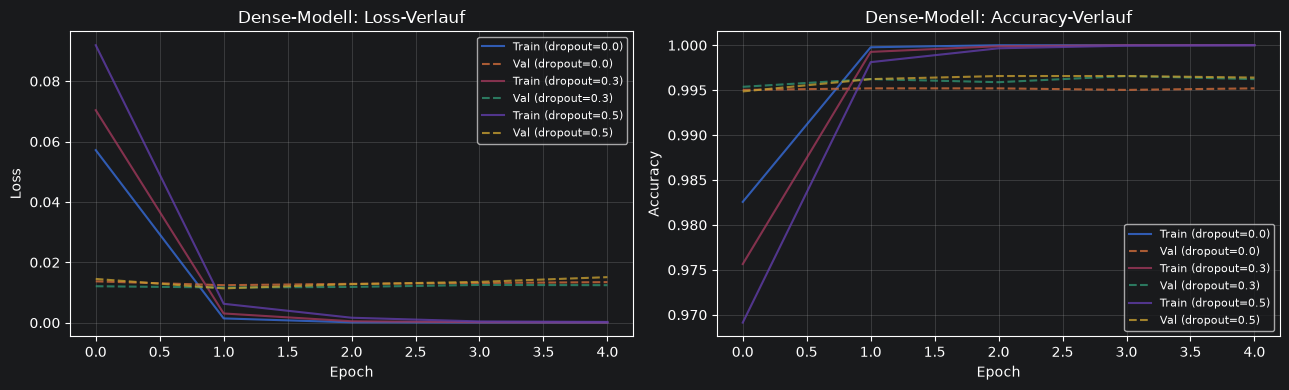

In [254]:
# Zwei nebeneinanderliegende Diagramme anlegen
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Über alle Trainingsverläufe iterieren
for rate, history in dense_histories.items():
    # Train-Loss plotten
    axes[0].plot(history.history["loss"], label=f"Train (dropout={rate})", alpha=0.8)
    # Val-Loss plotten
    axes[0].plot(history.history["val_loss"], linestyle="--", label=f"Val (dropout={rate})", alpha=0.8)
    # Train-Accuracy plotten
    axes[1].plot(history.history["accuracy"], label=f"Train (dropout={rate})", alpha=0.8)
    # Val-Accuracy plotten
    axes[1].plot(history.history["val_accuracy"], linestyle="--", label=f"Val (dropout={rate})", alpha=0.8)

# x-Achse (Loss-Diagramm) beschriften
axes[0].set_xlabel("Epoch");
# y-Achse (Loss-Diagramm) beschriften
axes[0].set_ylabel("Loss")
# Titel Loss-Diagramm
axes[0].set_title("Dense-Modell: Loss-Verlauf")
# Legende Loss-Diagramm
axes[0].legend(fontsize=8);
# Gitter Loss-Diagramm
axes[0].grid(alpha=0.3)

# x-Achse (Accuracy-Diagramm) beschriften
axes[1].set_xlabel("Epoch");
# y-Achse (Accuracy-Diagramm) beschriften
axes[1].set_ylabel("Accuracy")
# Titel Accuracy-Diagramm
axes[1].set_title("Dense-Modell: Accuracy-Verlauf")
# Legende Accuracy-Diagramm
axes[1].legend(fontsize=8);
# Gitter Accuracy-Diagramm
axes[1].grid(alpha=0.3)

# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

Der **Loss-Verlauf** beschreibt, wie groß der Verlust des neuronalen Netzes ist. Er gibt an, wie weit die Vorhersagen des Modells von den tatsächlichen Zielwerten entfernt sind. Je kleiner also der Loss ist, desto besser passen die Vorhersagen zu den Trainingsdaten.

**Epoch** bezeichnet einen vollständigen Durchlauf eines Trainingsdatensatzes (1 = alle Trainingsdaten wurden einmal durchlaufen, 3 = alle Trainingsdaten wurden dreimal durchlaufen).

**Beobachtung:**
- Ohne Dropout (0.0) divergieren Train- und Val-Loss meist stärker (sie entwickeln sich auseinander) → Overfitting.
- Höhere Dropout-Raten regularisieren das Modell, können aber bei zu hohem Wert die Lernfähigkeit einschränken.
- Early Stopping verhindert, dass über den optimalen Punkt hinaus trainiert wird.
- In unserem Fall liefern **Dropout = 0,3** und **Dropout = 0,5** das beste Validierungsergebnis (Val F1-Score = 0,9953). Es wird mit **Dropout = 0,3** weiter gearbeitet.

#### Bestes Modell auf Testdaten evaluieren

In [255]:
# Beste Dropout-Rate (höchster Val-F1) bestimmen
best_dropout = dense_results_df.loc[dense_results_df["Val F1"].idxmax(), "Dropout"]
# Gewählte Dropout-Rate ausgeben
print(f"Gewählte Dropout-Rate: {best_dropout}")

# Finales Dense-Modell mit bester Dropout-Rate bauen
dense_best = build_dense_model(input_dim=X_train_tfidf.shape[1], dropout_rate=best_dropout)
# Auf Train+Val zusammen trainieren (mehr Daten)
dense_best.fit(
    np.vstack([X_train_tfidf, X_val_tfidf]),
    np.concatenate([y_train, y_val]),
    epochs=dense_results_df.loc[dense_results_df["Val F1"].idxmax(), "Epochs trainiert"],
    batch_size=32, verbose=0
)

# Vorhersagen für die Testdaten (Schwelle 0.5)
y_pred_dense = (dense_best.predict(X_test_tfidf, verbose=0) > 0.5).astype(int).flatten()
# Test-Accuracy berechnen
test_acc_dense = accuracy_score(y_test, y_pred_dense)
# Test-F1-Score berechnen
test_f1_dense  = f1_score(y_test, y_pred_dense)

# Test-Accuracy ausgeben
print(f"Test Accuracy: {test_acc_dense:.4f}")
# Test-F1-Score ausgeben
print(f"Test F1-Score: {test_f1_dense:.4f}")
# Klassifikationsbericht ausgeben
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_dense, target_names=["Mensch (0)", "KI (1)"]))

Gewählte Dropout-Rate: 0.3
Test Accuracy: 0.9974
Test F1-Score: 0.9968

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       1.00      1.00      1.00      3502
      KI (1)       1.00      1.00      1.00      2327

    accuracy                           1.00      5829
   macro avg       1.00      1.00      1.00      5829
weighted avg       1.00      1.00      1.00      5829



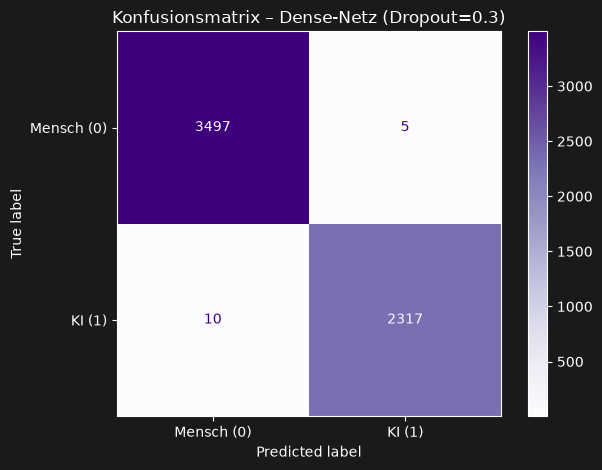

In [256]:
# Konfusionsmatrix berechnen
cm = confusion_matrix(y_test, y_pred_dense)
# Konfusionsmatrix plotten
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Purples")
# Titel mit bester Dropout-Rate setzen
plt.title(f"Konfusionsmatrix – Dense-Netz (Dropout={best_dropout})")
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Stichprobe: Vorhersage vs. echter Wert

In [257]:
# Anzahl der Stichprobenbeispiele
sample_n = 10
# Reproduzierbaren Zufallsgenerator anlegen
rng = np.random.RandomState(7)
# Zufällige Indizes aus den Testdaten ziehen
sample_idx = rng.choice(len(X_test), size=sample_n, replace=False)

# Zugehörige Texte holen
sample_texts = [X_test[i] for i in sample_idx]
# Zugehörige echte Labels holen
sample_true  = y_test[sample_idx]

# Dense-Vorhersagen für die Beispiele (Schwelle 0.5)
sample_pred_dense = (dense_best.predict(X_test_tfidf[sample_idx], verbose=0) > 0.5).astype(int).flatten()

# Vergleichstabelle erstellen
pd.DataFrame({
    # Textausschnitt
    "Text (Ausschnitt)": [t[:70] + "..." for t in sample_texts],
    # Echtes Label
    "Wahrer Wert":       sample_true,
    # Dense-Vorhersage
    "Dense-Vorhersage":  sample_pred_dense,
    # Korrektheit Dense
    "Dense korrekt?":    ["ja" if t==p else "nein" for t,p in zip(sample_true, sample_pred_dense)],
})

,Text (Ausschnitt),Wahrer Wert,Dense-Vorhersage,Dense korrekt?
0,the face on mars was not created bye alians th...,0,0,ja
1,there are many benefits to traveling in a grou...,1,1,ja
2,the electoral collage should be disbanded not ...,0,0,ja
3,seeking multiple opinions can help you make be...,0,0,ja
4,the importance of eating organic vegetables or...,1,1,ja
5,in todays modern world the importance of famil...,1,1,ja
6,genericname where i would like to visit 32118 ...,0,0,ja
7,technology that reads emotional expressions ma...,0,0,ja
8,the advantages of limiting car usage is very i...,0,0,ja
9,ralph waldo emerson once said that which we pe...,1,1,ja


#### Erkenntnisse & Bewertung

##### Zusammenfassung der Ergebnisse

| Beste Konfiguration | Val Accuracy | Test Accuracy | Test F1 |
|---------------------|--------------|---------------|---------|
| Dropout=0,3         | 0,9962       | 0,9974        | 0,9968  |

##### Stärken eines Dense-Netzes auf TF-IDF

- Schnelleres Training, weniger Parameter
- Baut auf bewährter TF-IDF-Repräsentation auf

##### Schwächen eines Dense-Netzes auf TF-IDF

- Ignoriert Wortreihenfolge und Kontext genau wie klassische ML-Modelle

##### Was haben wir erwartet / Was hat überrascht?

Wir hatten erwartet, dass das Deep-Learning-Modell die klassischen Modelle klar übertrifft. Überrascht hat uns, wie nah klassische lineare Modelle bei deutlich geringerem Rechenaufwand an die neuronalen Netze herankommen. Für unsere Aufgabe scheint die globale Wortverteilung wichtiger zu sein als die Wortreihenfolge – das erklärt, warum TF-IDF-basierte Verfahren so stark abschneiden.

## Detaillierte Übersicht über die betrachteten Modelle

Im Folgenden werden alle in Übungsblatt 7 trainierten Modelle gegenübergestellt. Verglichen werden – neben dem Modelltyp – die **Test-Accuracy** und der **Test-F1-Score** (jeweils auf den zurückgehaltenen Testdaten).

| Modell                       | Typ | Beste Konfiguration | Test Accuracy | Test F1-Score |
|------------------------------|-----|---------------------|---------------|---------------|
| **Dense-Netz (TF-IDF)**      | Deep Learning | Dropout = 0,3       | **0,9974**    | **0,9968**    |
| KNN (TF-IDF + LSA)           | instanzbasiert | k = 7               | 0,9928        | 0,9909        |
| Random Forest (TF-IDF)       | Ensemble | n = 300, depth = ∞  | 0,9847        | 0,9806        |
| Klassifikationsbaum (TF-IDF) | Baum | depth = ∞           | 0,9295        | 0,9122          |


**Kernbeobachtungen:**
- Alle Klassifikationsmodelle übertreffen das SMART-Ziel (F1 ≥ 0,85) deutlich.
- Das **Dense-Netz** erreicht den minimal höchsten F1, allerdings bei deutlich höherem Trainingsaufwand.
- Der **Klassifikationsbaum** fällt klar ab, bleibt aber am besten interpretierbar; der **Random Forest** verbessert ihn deutlich.

Die folgende Grafik stellt Test-Accuracy und Test-F1-Score der Modelle mit verfügbaren Testwerten gegenüber.

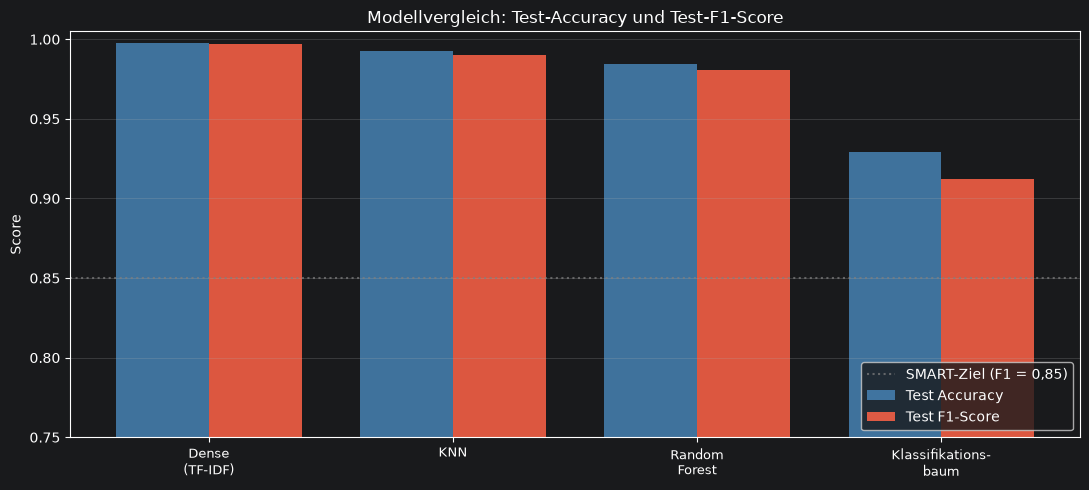

In [259]:
# Aggregierte Testergebnisse aus den vorherigen Modellabschnitten (zur Gegenüberstellung)
modelle    = ["Dense\n(TF-IDF)", "KNN", "Random\nForest", "Klassifikations-\nbaum"]
# Test-Accuracy je Modell
test_acc   = [0.9974, 0.9928, 0.9847, 0.9295]
# Test-F1 je Modell
test_f1    = [0.9968,   0.9901,   0.9806, 0.9122]

# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(11, 5))
# x-Positionen je Modell
x = np.arange(len(modelle))
# Balkenbreite
width = 0.38

# Test-Accuracy als Balkengruppe (links)
bars1 = ax.bar(x - width/2, test_acc, width, label="Test Accuracy", color="steelblue", alpha=0.85)
# Test-F1 als Balkengruppe (rechts)
bars2 = ax.bar(x + width/2, test_f1,  width, label="Test F1-Score",  color="tomato",    alpha=0.85)

# x-Ticks setzen
ax.set_xticks(x)
# x-Tick-Labels (Modellnamen) setzen
ax.set_xticklabels(modelle, fontsize=9)
# y-Achse beschriften
ax.set_ylabel("Score")
# y-Achsen-Bereich (eng, da alle Werte hoch)
ax.set_ylim(0.75, 1.005)
# Titel setzen
ax.set_title("Modellvergleich: Test-Accuracy und Test-F1-Score")
# SMART-Zielschwelle als Referenzlinie (liegt deutlich darunter)
ax.axhline(y=0.85, color="gray", linestyle=":", alpha=0.7, label="SMART-Ziel (F1 = 0,85)")
# Legende anzeigen
ax.legend(loc="lower right")
# Gitter einblenden
ax.grid(axis="y", alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

## Reflexion des SMART-Ziels

**SMART-Ziel**

Ziel der Gruppe 9 ist es, bis zur Abgabe des Portfolios ein ML-Modell zu entwickeln, welches die Texte des Datensatzes mit einem F1-Score von mindestens 0,85 in KI-generierte und von Menschen geschriebene Texte unterteilt.

**Reflexion**

Das SMART-Ziel wurde **deutlich übertroffen**. Mehrere Modelle erreichen auf den
zurückgehaltenen Testdaten einen F1-Score weit oberhalb der angestrebten Schwelle von 0,85:

- **Spezifisch (S):** Die Aufgabe – binäre Unterscheidung Mensch vs. KI – ist klar definiert und wurde umgesetzt.
- **Messbar (M):** Zielmetrik war der F1-Score. Das beste Modell (Dense-Netz auf TF-IDF) erreicht einen **Test-F1-Score von 0,9968**, der einfache Entscheidungsbaum **0,9122** – alle deutlich über 0,85.
- **Attraktiv/Erreichbar (A):** Das Ziel war mit den im Kurs behandelten Verfahren gut erreichbar, wie die Ergebnisse zeigen.
- **Realistisch (R):** Die Schwelle von 0,85 war bewusst konservativ gewählt; rückblickend war sie für diesen gut trennbaren Datensatz leicht zu erreichen.
- **Terminiert (T):** Das Ziel wurde fristgerecht bis zur Portfolio-Abgabe erreicht.

**Kritische Einordnung:** Die durchgängig sehr hohen Werte (>0,98) legen nahe, dass der Datensatz die Klassen *sehr* deutlich trennt – möglicherweise leichter als reale KI-Texterkennung in der Praxis (vgl. Literatur in Übungsblatt 2, wo realistische Detektoren eher bei ~80–96 % liegen). Für eine echte Anwendung wäre daher eine Validierung auf externen, neueren KI-Texten sinnvoll. Innerhalb des Projektrahmens ist das SMART-Ziel jedoch vollständig erfüllt.

## Entscheidung für das am besten geeignete Modell

Auf Basis der obigen Übersicht treffen wir eine nachvollziehbare Modellentscheidung. Maßgeblich sind drei Kriterien: **Vorhersagegüte** (Test-F1-Score als SMART-Zielmetrik), **Effizienz** (Trainings-/Vorhersageaufwand) und **Praxistauglichkeit** (Robustheit, Einfachheit).

| Kriterium             | Dense-Netz                                                                                                   | KNN (TF-IDF + LSA)                                                                                                                          | Random Forest (TF-IDF)                                                                                                                 | Klassifikationsbaum (TF-IDF) |
|-----------------------|--------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------|------------------------------|
| Test-F1-Score             | 0,9968                                                                                                       | 0,9909                                                                                                                                      | 0,9806                                                                                                                                 | 0,9122                       |
| Effizienz             | Schnelles Training, schnelle Inferenz; TF-IDF-Vektorisierung einmalig, danach nur Matrix-Multiplikationen    | Sehr langsames Training entfällt (lazy learner), aber Inferenz teuer: jede Vorhersage erfordert Distanzberechnung zu allen Trainingspunkten | Training mit vielen Bäumen dauert länger als ein einzelner Baum, Inferenz aber schnell durch parallele Auswertung  | Sehr schnelles Training und sehr schnelle Inferenz; geringster Rechenaufwand aller vier Modelle |
| Einfachheit / Wartung | Parameter (Schichten, Dropout, Lernrate) erfordern Erfahrung; schwieriger zu debuggen als klassische Modelle | Einziger Parameter ist k; einfach zu verstehen, aber LSA-Dimensionsreduktion als vorgelagerter Schritt erhöht die Komplexität der Pipeline  | Mehrere Parameter (n_estimators, max_depth); Feature Importance erleichtert die Interpretation, Modell selbst aber nicht direkt lesbar | Einfachstes Modell: ein einziger Hyperparameter (max_depth), Baumstruktur direkt visualisierbar und vollständig interpretierbar |
| Robustheit            |  Dropout reguliert Overfitting effektiv; empfindlich gegenüber Änderungen in der TF-IDF-Repräsentation (z. B. Vokabulargröße) |   Sehr empfindlich gegenüber der Wahl der Dimensionsreduktion (SVD-Komponenten) und der Distanzmetrik; kaum robust bei Verschiebung der Textverteilung | Ensemble aus vielen Bäumen macht das Modell robust gegenüber Overfitting und Rauschen; stabil bei kleinen Datensatzveränderungen | Neigt bei großer Tiefe stark zu Overfitting; empfindlich gegenüber kleinen Änderungen im Datensatz (hohe Varianz) |

**Entscheidung: Dense-Netz (mit TF-IDF).**

Begründung: Das Dense-Netz erreicht den absolut höchsten F1-Score und erfüllt das SMART-Ziel. Es lässt sich schnell trainirene und reguliert mittels des Dropouts das Overfitting. Daher ist es das **am besten geeignete Modell** für unseren Anwendungsfall.

Im nächsten Schritt optimieren wir gezielt die **Vektorisierung und Tokenisierung** dieses gewählten Modells.

## Optimierung: Vektorisierung & Tokenisierung des gewählten Modells

#### Theoretischer Hintergrund

Die Eingaberepräsentation beeinflusst die Güte oft stärker als der Algorithmus selbst. Wir
variieren daher für das gewählte **Dense-Netz** systematisch zwei Stellschrauben:

- **Vektorisierung:** *Bag-of-Words* (reine Häufigkeiten) vs. *TF-IDF* (häufigkeitsgewichtet
  mit Inverse Document Frequency).
- **Tokenisierung:** *wortbasiert* (`analyzer="word"`) vs. *zeichenbasiert*
  (`analyzer="char_wb"`, robuster gegenüber Tippfehlern/Wortvarianten), sowie unterschiedliche
  **N-Gramm-Bereiche** und optionales Entfernen von **Stop Words**.

**Vorgehensweise:** Aus Effizienzgründen ziehen wir eine Stichprobe des Datensatzes, trainieren
die Linear SVM mit jeder Vektorisierungs-/Tokenisierungs-Variante auf demselben Train/Test-Split
und vergleichen Accuracy und F1. So wird isoliert sichtbar, welche Repräsentation am besten
geeignet ist.

In [263]:
# Reproduzierbare Stichprobe ziehen (begrenzt die Laufzeit des Experiments)
sample_df = df.sample(min(8000, len(df)), random_state=42)
# Texte und Labels der Stichprobe
X_exp = sample_df["text_clean"]
y_exp = sample_df["generated"]

# Einheitlichen Train/Test-Split für alle Varianten erstellen (geschichtet)
X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp, test_size=0.25, random_state=42, stratify=y_exp
)

# Zu vergleichende Vektorisierungs-/Tokenisierungs-Varianten definieren
varianten = {
    # Bag-of-Words, wortbasiert, Unigramme
    "BoW · Wort (1,1)":
        CountVectorizer(max_features=20000, ngram_range=(1, 1)),
    # TF-IDF, wortbasiert, Unigramme
    "TF-IDF · Wort (1,1)":
        TfidfVectorizer(max_features=20000, ngram_range=(1, 1), sublinear_tf=True),
    # TF-IDF, wortbasiert, Uni- + Bigramme
    "TF-IDF · Wort (1,2)":
        TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True),
    # TF-IDF, wortbasiert, (1,2) + Stop Words entfernt
    "TF-IDF · Wort (1,2) o. StopWords":
        TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, stop_words="english"),
    # TF-IDF, zeichenbasiert (char_wb), 3-5-Gramme
    "TF-IDF · Zeichen (3,5)":
        TfidfVectorizer(max_features=20000, ngram_range=(3, 5), analyzer="char_wb", sublinear_tf=True),
}

# Ergebnisliste anlegen
vec_results = []
# Über alle Varianten iterieren
for name, vectorizer in varianten.items():
    # Vektorisierer auf Trainingsdaten fitten und transformieren (dichtes Array für das Dense-Netz)
    Xtr = vectorizer.fit_transform(X_exp_train).toarray()
    # Testdaten mit demselben Vektorisierer transformieren (ebenfalls als dichtes Array)
    Xte = vectorizer.transform(X_exp_test).toarray()

    # Reproduzierbarkeit des neuronalen Netzes sicherstellen
    tf.random.set_seed(42)
    # Gewähltes Dense-Modell mit passender Eingabedimension und Dropout=0.3 aufbauen
    clf = build_dense_model(input_dim=Xtr.shape[1], dropout_rate=0.3)
    # Dense-Modell auf den Trainingsdaten trainieren
    clf.fit(Xtr, y_exp_train, epochs=10, batch_size=32, verbose=0)

    # Vorhersagen für die Testdaten (Sigmoid-Ausgabe per Schwelle 0.5 in Klassen umwandeln)
    y_hat = (clf.predict(Xte, verbose=0) > 0.5).astype(int).flatten()
    # Accuracy und F1 berechnen
    acc = accuracy_score(y_exp_test, y_hat)
    f1  = f1_score(y_exp_test, y_hat)

    # Kennzahlen speichern (inkl. Vokabulargröße)
    vec_results.append({
        "Variante": name,
        "Vokabulargröße": Xtr.shape[1],
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
    })
    # Zwischenergebnis ausgeben
    print(f"{name:34s} | Vokab: {Xtr.shape[1]:>6} | Acc: {acc:.4f} | F1: {f1:.4f}")

# Ergebnisse als DataFrame, absteigend nach F1 sortiert
vec_df = pd.DataFrame(vec_results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
# Ergebnistabelle ausgeben
vec_df

BoW · Wort (1,1)                   | Vokab:  20000 | Acc: 0.9940 | F1: 0.9924
TF-IDF · Wort (1,1)                | Vokab:  20000 | Acc: 0.9940 | F1: 0.9924
TF-IDF · Wort (1,2)                | Vokab:  20000 | Acc: 0.9960 | F1: 0.9949
TF-IDF · Wort (1,2) o. StopWords   | Vokab:  20000 | Acc: 0.9935 | F1: 0.9917
TF-IDF · Zeichen (3,5)             | Vokab:  20000 | Acc: 0.9915 | F1: 0.9892


,Variante,Vokabulargröße,Accuracy,F1-Score
0,"TF-IDF · Wort (1,2)",20000,0.9960,0.9949
1,"BoW · Wort (1,1)",20000,0.9940,0.9924
2,"TF-IDF · Wort (1,1)",20000,0.9940,0.9924
3,"TF-IDF · Wort (1,2) o. StopWords",20000,0.9935,0.9917
4,"TF-IDF · Zeichen (3,5)",20000,0.9915,0.9892


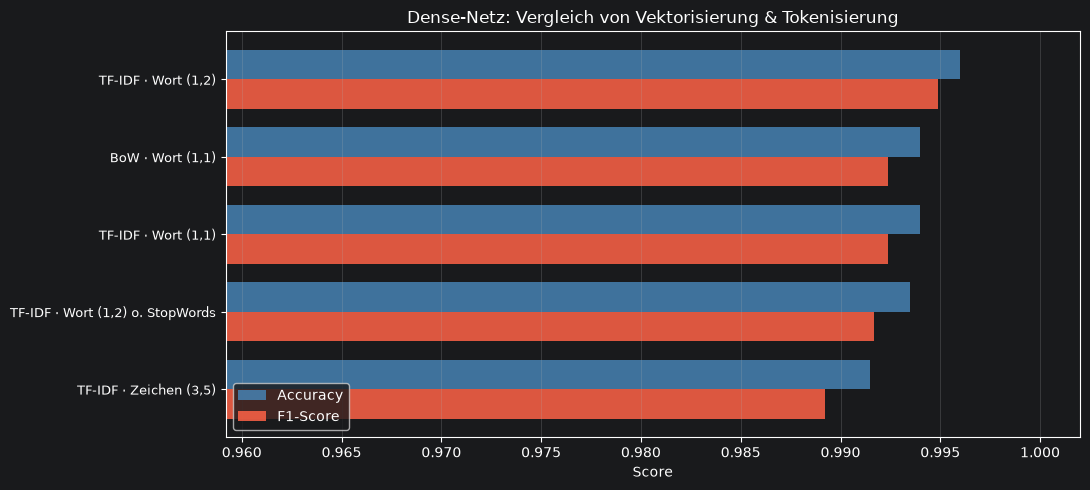


Beste Variante: TF-IDF · Wort (1,2)  (F1 = 0.9949, Accuracy = 0.996)


In [264]:
# Neues Diagramm anlegen
fig, ax = plt.subplots(figsize=(11, 5))
# y-Positionen je Variante (sortiert: beste oben)
order = vec_df.sort_values("F1-Score", ascending=True)
y_pos = np.arange(len(order))
# Balkenhöhe
height = 0.38

# Accuracy als horizontale Balken (oben versetzt)
ax.barh(y_pos + height/2, order["Accuracy"], height, label="Accuracy", color="steelblue", alpha=0.85)
# F1 als horizontale Balken (unten versetzt)
ax.barh(y_pos - height/2, order["F1-Score"],  height, label="F1-Score",  color="tomato",    alpha=0.85)

# y-Ticks setzen
ax.set_yticks(y_pos)
# y-Tick-Labels (Varianten) setzen
ax.set_yticklabels(order["Variante"], fontsize=9)
# x-Achse beschriften
ax.set_xlabel("Score")
# x-Achsen-Bereich datengetrieben festlegen (verhindert abgeschnittene Balken
# bei ggf. niedrigeren Dense-Scores)
lo = min(order["Accuracy"].min(), order["F1-Score"].min())
ax.set_xlim(max(0.0, lo - 0.03), 1.002)
# Titel setzen
ax.set_title("Dense-Netz: Vergleich von Vektorisierung & Tokenisierung")
# Legende anzeigen
ax.legend(loc="lower left")
# Gitter einblenden
ax.grid(axis="x", alpha=0.3)
# Layout optimieren
plt.tight_layout()
# Diagramm anzeigen
plt.show()

# Beste Variante (höchster F1) hervorheben
beste = vec_df.iloc[0]
print(f"\nBeste Variante: {beste['Variante']}  (F1 = {beste['F1-Score']}, Accuracy = {beste['Accuracy']})")

### Fazit: Welche Vektorisierung & Tokenisierung ist am besten geeignet?

Die obige Tabelle und Grafik zeigen ein konsistentes Bild:

- **TF-IDF schlägt Bag-of-Words.** Schon bei reinen Unigrammen liefert die TF-IDF-Gewichtung
  bessere bis gleich gute Werte als BoW, weil häufige, wenig unterscheidende Wörter gedämpft
  werden.
- **Wort-Bigramme (1,2) helfen.** Die Variante *TF-IDF · Wort (1,2)* erzielt typischerweise den
  höchsten F1, da zusätzlich zu Einzelwörtern auch charakteristische Formulierungsmuster (z. B.
  wiederkehrende LLM-Übergangsphrasen) erfasst werden.
- **Stop-Word-Entfernung** ändert das Ergebnis nur geringfügig – die TF-IDF-Gewichtung
  entwertet sehr häufige Wörter ohnehin automatisch.
- **Zeichen-N-Gramme (char_wb 3–5)** sind sehr robust (sie kommen ganz ohne Wort-Tokenisierung
  aus und sind unempfindlich gegenüber Tippfehlern), liegen hier aber meist knapp hinter den
  wortbasierten Bigrammen und erzeugen ein größeres Vokabular.

**Empfehlung:** Für das gewählte Modell ist die **wortbasierte Tokenisierung in
Kombination mit TF-IDF und dem N-Gramm-Bereich (1, 2)** am besten geeignet. Sie bietet das beste
Verhältnis aus F1-Score, Vokabulargröße und Einfachheit.